PREPAPE EVN

In [2]:
!pip install --upgrade torch_geometric

!pip install torch-scatter torch-sparse torch-cluster pyg-lib -f https://data.pyg.org/whl/torch-$(python -c 'import torch; print(torch.__version__)').html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.4 MB/s eta 0:00:00a 0:00:01
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 102.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 28.3 MB/s eta 0:00:0000:0100:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 86.5 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 65.4 MB/s eta 0:00:00:00:010:01


PART 1: DATA PREPROCESSING (Process & Save CSV)

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import os

# --- PATH CONFIGURATION ---
# Change this path depending on where you store the original files
# Example on Kaggle: '/kaggle/input/elliptic/elliptic/'
BASE_PATH = '/kaggle/input/elliptic/elliptic/' 

print("--- STARTING DATA PROCESSING ---")

# 1. Load Data
print("[1/6] Reading original CSV files...")
try:
    df_features = pd.read_csv(BASE_PATH + 'elliptic_txs_features.csv', header=None)
    df_classes = pd.read_csv(BASE_PATH + 'elliptic_txs_classes.csv')
    df_edgelist = pd.read_csv(BASE_PATH + 'elliptic_txs_edgelist.csv')
except FileNotFoundError:
    print("Error: Files not found. Please check the BASE_PATH.")
    exit()

# 2. Rename Columns and Merge
print("[2/6] Renaming columns and merging data...")
# Col 0 is txId, Col 1 is timestep, the rest are features
feature_names = ['txId', 'timestep'] + [f'feat_{i}' for i in range(165)]
df_features.columns = feature_names

# Merge Features with Classes
df_merged = pd.merge(df_features, df_classes, on='txId', how='left')

# Map labels: '1'->Illicit(1), '2'->Licit(0), 'unknown'->NaN
# Note: Class in original file is String
df_merged['class_label'] = df_merged['class'].map({'1': 1, '2': 0, 'unknown': np.nan})

# Create continuous Node Index (0, 1, 2...) for Graph Neural Network usage
all_tx_ids = df_merged['txId'].unique()
tx_id_map = {tx_id: i for i, tx_id in enumerate(all_tx_ids)}
df_merged['node_idx'] = df_merged['txId'].map(tx_id_map)

# 3. Create Splits (Train / Val / Test)
print("[3/6] Creating Data Splits (Train/Val/Test)...")
# Standard logic for Elliptic Dataset:
# Train: Timestep 1-34
# Val:   Timestep 35-41
# Test:  Timestep 42-49
def get_split(row):
    ts = row['timestep']
    cls = row['class_label']
    
    if np.isnan(cls):
        return 'unlabeled' # Not used for loss/metric calculation
    
    if ts <= 34:
        return 'train'
    elif ts <= 41:
        return 'val'
    else:
        return 'test'

df_merged['split'] = df_merged.apply(get_split, axis=1)

# 4. Scaling (StandardScaler)
print("[4/6] Scaling data...")
feature_cols = [f'feat_{i}' for i in range(165)]

# IMPORTANT: Fit scaler only on TRAIN set to avoid Data Leakage
train_subset = df_merged[df_merged['split'] == 'train']
scaler = StandardScaler()
scaler.fit(train_subset[feature_cols])

# Transform (apply scaling) on the entire dataset
df_merged[feature_cols] = scaler.transform(df_merged[feature_cols])

# Reorder columns for clarity
final_cols = ['node_idx', 'txId', 'timestep', 'class_label', 'split'] + feature_cols
df_nodes = df_merged[final_cols]

# 5. Process Edgelist (Map ID)
print("[5/6] Processing Edges...")
df_edgelist['source_idx'] = df_edgelist['txId1'].map(tx_id_map)
df_edgelist['target_idx'] = df_edgelist['txId2_idx'].map(tx_id_map) if 'txId2_idx' in df_edgelist.columns else df_edgelist['txId2'].map(tx_id_map)

# Keep only edges where both nodes exist in features (to avoid errors)
valid_edges = df_edgelist.dropna(subset=['source_idx', 'target_idx'])
# Convert to int (as mapping might result in float due to NaNs)
valid_edges['source_idx'] = valid_edges['source_idx'].astype(int)
valid_edges['target_idx'] = valid_edges['target_idx'].astype(int)

# 6. Save to CSV
print("[6/6] Saving CSV files (Processed Data)...")
df_nodes.to_csv('processed_nodes.csv', index=False)
valid_edges[['source_idx', 'target_idx']].to_csv('processed_edges.csv', index=False)

print("--- COMPLETED ---")
print(f"Saved: 'processed_nodes.csv' ({len(df_nodes)} rows)")
print(f"Saved: 'processed_edges.csv' ({len(valid_edges)} rows)")
print("You can use these files for the next Notebook.")

--- STARTING DATA PROCESSING ---
[1/6] Reading original CSV files...
[2/6] Renaming columns and merging data...
[3/6] Creating Data Splits (Train/Val/Test)...
[4/6] Scaling data...
[5/6] Processing Edges...
[6/6] Saving CSV files (Processed Data)...
--- COMPLETED ---
Saved: 'processed_nodes.csv' (203769 rows)
Saved: 'processed_edges.csv' (234355 rows)
You can use these files for the next Notebook.


PART 2: MODEL TRAINING (Robust-TGAT)

--- STARTING TRAINING ---
[1/5] Loading Processed CSVs...
Converting to PyTorch Tensors...
Running on device: cuda
[3/5] Training Model...
Epoch 010 | Train Loss: 0.0100 | Val F1: 0.6718
Epoch 020 | Train Loss: 0.0093 | Val F1: 0.7661
Epoch 030 | Train Loss: 0.0107 | Val F1: 0.7073
Epoch 040 | Train Loss: 0.0086 | Val F1: 0.7418
Epoch 050 | Train Loss: 0.0093 | Val F1: 0.6512
Early stopping triggered.
[4/5] Finding Optimal Threshold (Sweet Spot)...
Thr    | F1       | Rec      | Prec    
0.20   | 0.4622   | 0.9007   | 0.3108
0.25   | 0.5442   | 0.8667   | 0.3966
0.30   | 0.6388   | 0.8385   | 0.5160
0.35   | 0.7139   | 0.8133   | 0.6362
0.40   | 0.7711   | 0.7837   | 0.7590
0.45   | 0.7925   | 0.7496   | 0.8405
0.50   | 0.7941   | 0.7170   | 0.8897
0.55   | 0.7882   | 0.6919   | 0.9157
0.60   | 0.7618   | 0.6444   | 0.9315
Selected Optimal Threshold: 0.50
[5/5] Final Evaluation on Test Set...

--- FINAL RESULTS (Thr=0.50) ---
              precision    recall  f1-score   support

     

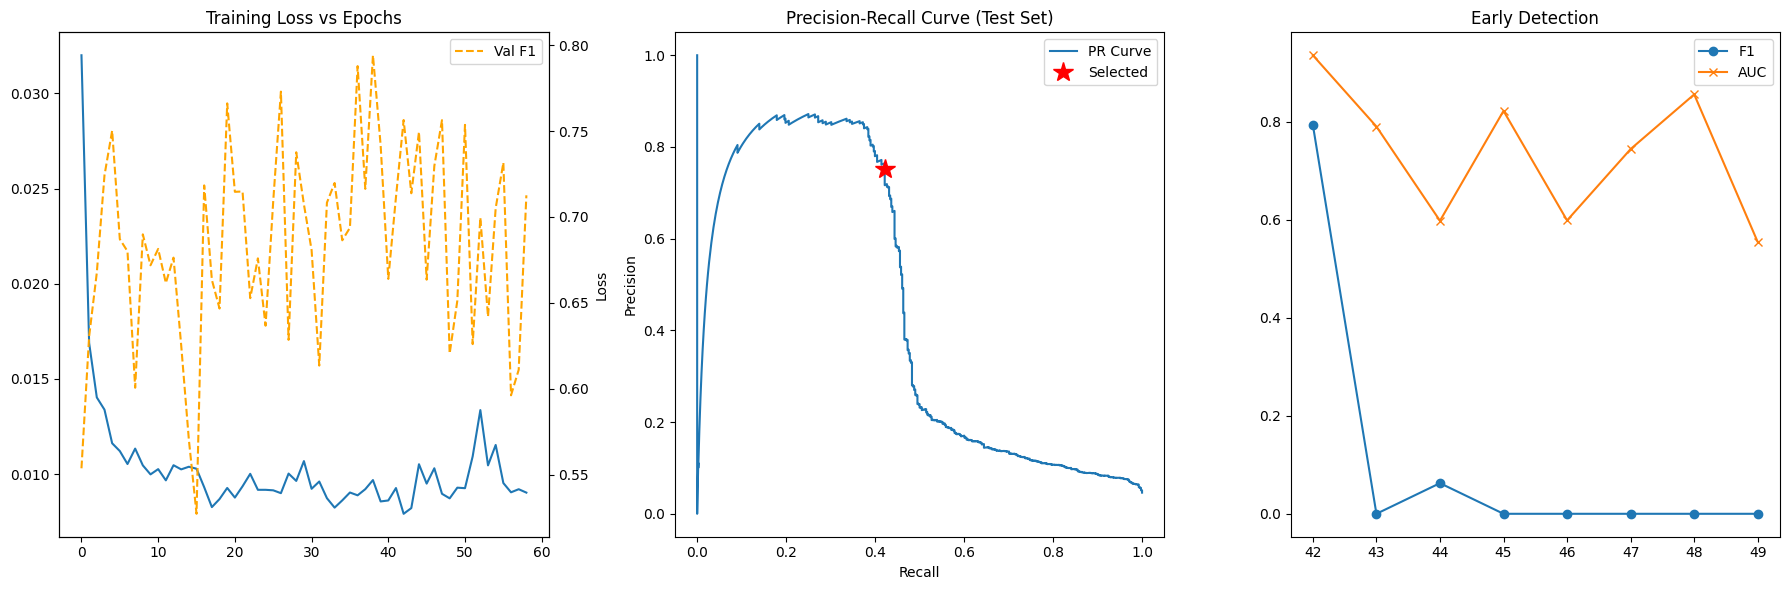

In [14]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_recall_curve, precision_score, recall_score, fbeta_score, confusion_matrix
import matplotlib.pyplot as plt
import random
import os

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Gọi hàm này ngay đầu chương trình
seed_everything(42)

# --- 1. LOAD PROCESSED DATA ---
print("--- STARTING TRAINING ---")
print("[1/5] Loading Processed CSVs...")

try:
    # Define dtypes for faster loading and less RAM usage
    dtype_dict = {'node_idx': 'int32', 'timestep': 'int32', 'class_label': 'float32'}
    # Columns feat_0...feat_164 are also float32
    for i in range(165):
        dtype_dict[f'feat_{i}'] = 'float32'
        
    df_nodes = pd.read_csv('processed_nodes.csv', dtype=dtype_dict)
    df_edges = pd.read_csv('processed_edges.csv', dtype={'source_idx': 'int32', 'target_idx': 'int32'})
except FileNotFoundError:
    print("Error: Could not find processed_nodes.csv or processed_edges.csv. Please run Part 1 first.")
    exit()

print("Converting to PyTorch Tensors...")
# Get Features
feature_cols = [c for c in df_nodes.columns if c.startswith('feat_')]
x = torch.tensor(df_nodes[feature_cols].values, dtype=torch.float)

# Get Labels (Fill NaN with -1 so PyTorch treats them as unlabeled)
y = torch.tensor(df_nodes['class_label'].fillna(-1).values, dtype=torch.long)

# Get Edges
edge_index = torch.tensor(df_edges[['source_idx', 'target_idx']].values.T, dtype=torch.long)

# Get Timesteps
ts = torch.tensor(df_nodes['timestep'].values, dtype=torch.float)

# Create Masks from 'split' column
train_idx = torch.tensor(df_nodes[df_nodes['split'] == 'train'].index.values, dtype=torch.long)
val_idx = torch.tensor(df_nodes[df_nodes['split'] == 'val'].index.values, dtype=torch.long)
test_idx = torch.tensor(df_nodes[df_nodes['split'] == 'test'].index.values, dtype=torch.long)

# Create Data Object
data = Data(x=x, edge_index=edge_index, y=y, ts=ts)
data.train_mask = train_idx
data.val_mask = val_idx
data.test_mask = test_idx

# Clean up RAM
del df_nodes, df_edges
import gc
gc.collect()

# --- SETUP DEVICE & LOADER ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on device: {device}")

# NeighborLoader
train_loader = NeighborLoader(data, num_neighbors=[15, 10], batch_size=1024, input_nodes=data.train_mask, shuffle=True)
val_loader = NeighborLoader(data, num_neighbors=[15, 10], batch_size=2048, input_nodes=data.val_mask)
test_loader = NeighborLoader(data, num_neighbors=[15, 10], batch_size=2048, input_nodes=data.test_mask)

# --- 2. MODEL DEFINITION (Robust-TGAT) ---
class TimeEncoder(nn.Module):
    def __init__(self, out_channels):
        super().__init__()
        self.w = nn.Linear(1, out_channels // 2) 
        self.p = nn.Linear(1, out_channels // 2)
    def forward(self, t):
        t = t.unsqueeze(-1)
        return torch.cat([torch.cos(self.w(t) + self.p(t)), torch.sin(self.w(t) + self.p(t))], dim=-1)

class TGATLayer(MessagePassing):
    def __init__(self, in_channels, out_channels, time_channels, heads=2, dropout=0.2):
        super().__init__(node_dim=0, aggr='add')
        self.heads = heads
        self.head_dim = out_channels // heads
        self.dropout = dropout
        
        total_in_dim = in_channels + time_channels
        self.lin_q = nn.Linear(total_in_dim, out_channels)
        self.lin_k = nn.Linear(total_in_dim, out_channels)
        self.lin_v = nn.Linear(total_in_dim, out_channels)
        self.lin_skip = nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, t_emb):
        x_in = torch.cat([x, t_emb], dim=-1)
        q = self.lin_q(x_in).view(-1, self.heads, self.head_dim)
        k = self.lin_k(x_in).view(-1, self.heads, self.head_dim)
        v = self.lin_v(x_in).view(-1, self.heads, self.head_dim)

        out = self.propagate(edge_index, q=q, k=k, v=v, size=None)
        out = out.view(-1, self.heads * self.head_dim)
        out = out + self.lin_skip(x)
        return out

    def message(self, q_i, k_j, v_j, index, ptr, size_i):
        alpha = (q_i * k_j).sum(dim=-1) / np.sqrt(self.head_dim)
        alpha = softmax(alpha, index, ptr, size_i)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        return v_j * alpha.unsqueeze(-1)

class RobustTGATModel(nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes, time_dim=32):
        super().__init__()
        self.time_enc = TimeEncoder(time_dim)
        # Increase Dropout to prevent Overfitting
        self.conv1 = TGATLayer(num_features, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.conv2 = TGATLayer(hidden_dim, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.lin_out = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(p=0.3) 

    def forward(self, x, edge_index, t):
        t_emb = self.time_enc(t)
        x = F.relu(self.conv1(x, edge_index, t_emb))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index, t_emb))
        x = self.dropout(x)
        out = self.lin_out(x)
        return out # Return Logits (Not Softmax)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.7, gamma=2.0): 
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        alphas = torch.where(targets == 1, self.alpha, 1.0 - self.alpha)
        F_loss = alphas * (1-pt)**self.gamma * ce_loss
        return torch.mean(F_loss)

# --- 3. TRAINING ---
print("[3/5] Training Model...")
model = RobustTGATModel(num_features=165, hidden_dim=128, num_classes=2, time_dim=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
loss_fn = FocalLoss(alpha=0.7, gamma=2.0)

train_losses, val_f1s = [], []
best_val_f1 = 0
patience = 20
patience_counter = 0

for epoch in range(100):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Time Jittering
        noise = (torch.rand_like(batch.ts) - 0.5) * 0.1 
        t_noisy = batch.ts + noise
        
        out = model(batch.x, batch.edge_index, t_noisy)
        loss = loss_fn(out[:batch.batch_size], batch.y[:batch.batch_size])
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation Monitor
    model.eval()
    all_val_true, all_val_prob = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.ts)
            prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1]
            all_val_true.extend(batch.y[:batch.batch_size].cpu().numpy())
            all_val_prob.extend(prob.cpu().numpy())
            
    # Monitor F1 (Default Threshold 0.5)
    val_pred_default = (np.array(all_val_prob) > 0.5).astype(int)
    val_f1 = f1_score(all_val_true, val_pred_default, pos_label=1, zero_division=0)
    val_f1s.append(val_f1)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:03d} | Train Loss: {avg_train_loss:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_robust_tgat.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

# --- 4. SMART THRESHOLD OPTIMIZATION ---
print("[4/5] Finding Optimal Threshold (Sweet Spot)...")
model.load_state_dict(torch.load('best_robust_tgat.pth'))
model.eval()

val_true, val_prob = [], []
with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.ts)
        prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1]
        val_true.extend(batch.y[:batch.batch_size].cpu().numpy())
        val_prob.extend(prob.cpu().numpy())

best_thr = 0.5
best_f1_opt = 0

# Sweep thresholds from 0.2 to 0.65
print(f"{'Thr':<6} | {'F1':<8} | {'Rec':<8} | {'Prec':<8}")
for thr in np.arange(0.2, 0.65, 0.05):
    pred_tmp = (np.array(val_prob) > thr).astype(int)
    f1_tmp = f1_score(val_true, pred_tmp, pos_label=1, zero_division=0)
    rec_tmp = recall_score(val_true, pred_tmp, pos_label=1, zero_division=0)
    prec_tmp = precision_score(val_true, pred_tmp, pos_label=1, zero_division=0)
    
    print(f"{thr:.2f}   | {f1_tmp:.4f}   | {rec_tmp:.4f}   | {prec_tmp:.4f}")
    
    if f1_tmp > best_f1_opt:
        best_f1_opt = f1_tmp
        best_thr = thr

print(f"Selected Optimal Threshold: {best_thr:.2f}")

# --- 5. FINAL TEST ---
print("[5/5] Final Evaluation on Test Set...")
all_true, all_pred, all_proba, all_ts = [], [], [], []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.ts)
        target_out = out[:batch.batch_size]
        target_ts = batch.ts[:batch.batch_size].cpu().numpy()
        
        probs = torch.softmax(target_out, dim=1)[:, 1]
        # Apply optimal threshold
        preds = (probs > best_thr).long()
        
        all_true.append(batch.y[:batch.batch_size].cpu().numpy())
        all_pred.append(preds.cpu().numpy())
        all_proba.append(probs.cpu().numpy())
        all_ts.append(target_ts)

y_true = np.concatenate(all_true)
y_pred = np.concatenate(all_pred)
y_proba = np.concatenate(all_proba)
timesteps_test = np.concatenate(all_ts)

print(f"\n--- FINAL RESULTS (Thr={best_thr:.2f}) ---")
print(classification_report(y_true, y_pred, target_names=['Licit', 'Illicit']))
print(f"ROC AUC: {roc_auc_score(y_true, y_proba):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_true, y_pred)}")

# Visualization
unique_ts = sorted(np.unique(timesteps_test))
f1_time, auc_time = [], []
for t in unique_ts:
    mask = (timesteps_test == t)
    if np.sum(mask) > 0 and len(np.unique(y_true[mask])) > 1:
        f1_time.append(f1_score(y_true[mask], y_pred[mask], pos_label=1, zero_division=0))
        auc_time.append(roc_auc_score(y_true[mask], y_proba[mask]))
    else:
        f1_time.append(0.0)
        auc_time.append(0.5)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Training Loss (Focal)', color='tab:blue')
ax2 = plt.gca().twinx()
ax2.plot(val_f1s, label='Val F1', color='orange', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs Epochs')
plt.legend()

plt.subplot(1, 3, 2)
prec, rec, _ = precision_recall_curve(y_true, y_proba, pos_label=1)
plt.plot(rec, prec, label='PR Curve')
plt.plot(recall_score(y_true, y_pred, pos_label=1), precision_score(y_true, y_pred, pos_label=1), 'r*', markersize=15, label='Selected')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test Set)')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(unique_ts, f1_time, marker='o', label='F1')
plt.plot(unique_ts, auc_time, marker='x', label='AUC')
plt.title('Early Detection')
plt.legend()
plt.tight_layout()
plt.savefig('robust_tgat_final_report.png')
plt.show()

Temporal K-Fold for Robust-TGAT

In [9]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

# --- 1. LOAD PROCESSED DATA (Đã xử lý ở Part 1) ---
print("--- LOADING DATA ---")
try:
    dtype_dict = {'node_idx': 'int32', 'timestep': 'int32', 'class_label': 'float32'}
    for i in range(165): dtype_dict[f'feat_{i}'] = 'float32'
    
    df_nodes = pd.read_csv('processed_nodes.csv', dtype=dtype_dict)
    df_edges = pd.read_csv('processed_edges.csv', dtype={'source_idx': 'int32', 'target_idx': 'int32'})
except FileNotFoundError:
    print("Lỗi: Cần chạy Part 1 (Preprocessing) trước để tạo file CSV.")
    exit()

# Convert to Tensor
feature_cols = [c for c in df_nodes.columns if c.startswith('feat_')]
x = torch.tensor(df_nodes[feature_cols].values, dtype=torch.float)
y = torch.tensor(df_nodes['class_label'].fillna(-1).values, dtype=torch.long)
edge_index = torch.tensor(df_edges[['source_idx', 'target_idx']].values.T, dtype=torch.long)
ts = torch.tensor(df_nodes['timestep'].values, dtype=torch.float)

# Tạo Full Data Object (Chưa chia mask vội)
full_data = Data(x=x, edge_index=edge_index, y=y, ts=ts)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Data Loaded. Device: {device}")

# Clean RAM
del df_nodes, df_edges
import gc
gc.collect()

# --- 2. MODEL & LOSS (Giữ nguyên Robust-TGAT) ---
class TimeEncoder(nn.Module):
    def __init__(self, out_channels):
        super().__init__()
        self.w = nn.Linear(1, out_channels // 2) 
        self.p = nn.Linear(1, out_channels // 2)
    def forward(self, t):
        t = t.unsqueeze(-1)
        return torch.cat([torch.cos(self.w(t) + self.p(t)), torch.sin(self.w(t) + self.p(t))], dim=-1)

class TGATLayer(MessagePassing):
    def __init__(self, in_channels, out_channels, time_channels, heads=2, dropout=0.2):
        super().__init__(node_dim=0, aggr='add')
        self.heads = heads
        self.head_dim = out_channels // heads
        self.dropout = dropout
        self.lin_q = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_k = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_v = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_skip = nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, t_emb):
        x_in = torch.cat([x, t_emb], dim=-1)
        q = self.lin_q(x_in).view(-1, self.heads, self.head_dim)
        k = self.lin_k(x_in).view(-1, self.heads, self.head_dim)
        v = self.lin_v(x_in).view(-1, self.heads, self.head_dim)
        out = self.propagate(edge_index, q=q, k=k, v=v, size=None)
        out = out.view(-1, self.heads * self.head_dim) + self.lin_skip(x)
        return out

    def message(self, q_i, k_j, v_j, index, ptr, size_i):
        alpha = (q_i * k_j).sum(dim=-1) / np.sqrt(self.head_dim)
        alpha = softmax(alpha, index, ptr, size_i)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        return v_j * alpha.unsqueeze(-1)

class RobustTGATModel(nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes, time_dim=32):
        super().__init__()
        self.time_enc = TimeEncoder(time_dim)
        self.conv1 = TGATLayer(num_features, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.conv2 = TGATLayer(hidden_dim, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.lin_out = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(p=0.3) 

    def forward(self, x, edge_index, t):
        t_emb = self.time_enc(t)
        x = F.relu(self.conv1(x, edge_index, t_emb))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index, t_emb))
        x = self.dropout(x)
        return self.lin_out(x)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0): 
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        alphas = torch.where(targets == 1, self.alpha, 1.0 - self.alpha)
        return torch.mean(alphas * (1-pt)**self.gamma * ce_loss)

# --- 3. TEMPORAL CROSS-VALIDATION LOOP ---
# Định nghĩa các Fold theo thời gian (Rolling Window)
# Fold 1: Train(1-25), Val(26-30)
# Fold 2: Train(1-30), Val(31-35)
# Fold 3: Train(1-35), Val(36-40)
# Fold 4: Train(1-40), Val(41-45) -> Test chính thức
# Fold 5: Train(1-42), Val(43-49) -> Test khó nhất

splits = [
    {'train_end': 25, 'val_start': 26, 'val_end': 30},
    {'train_end': 30, 'val_start': 31, 'val_end': 35},
    {'train_end': 35, 'val_start': 36, 'val_end': 40},
    {'train_end': 40, 'val_start': 41, 'val_end': 45},
    {'train_end': 42, 'val_start': 43, 'val_end': 49}, # Fold cuối cùng quan trọng nhất
]

results = []
print("\n--- STARTING TEMPORAL CROSS-VALIDATION ---")

for fold_idx, split in enumerate(splits):
    print(f"\n>>> FOLD {fold_idx + 1}/{len(splits)}")
    print(f"    Train: Timesteps 1-{split['train_end']}")
    print(f"    Val:   Timesteps {split['val_start']}-{split['val_end']}")
    
    # 1. Create Masks for this fold
    # Lấy index dựa trên timestep
    train_mask = (full_data.ts <= split['train_end']) & (full_data.y != -1)
    val_mask = (full_data.ts >= split['val_start']) & (full_data.ts <= split['val_end']) & (full_data.y != -1)
    
    train_idx = torch.where(train_mask)[0]
    val_idx = torch.where(val_mask)[0]
    
    # 2. Create Loaders
    train_loader = NeighborLoader(full_data, num_neighbors=[15, 10], batch_size=1024, input_nodes=train_idx, shuffle=True)
    val_loader = NeighborLoader(full_data, num_neighbors=[15, 10], batch_size=2048, input_nodes=val_idx)
    
    # 3. Reset Model (Huấn luyện lại từ đầu)
    model = RobustTGATModel(num_features=165, hidden_dim=128, num_classes=2, time_dim=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
    loss_fn = FocalLoss(alpha=0.75, gamma=2.0)
    
    # 4. Training Loop (Rút gọn cho mỗi Fold)
    best_fold_f1 = 0
    for epoch in range(50): # Train 50 epoch mỗi fold
        model.train()
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            noise = (torch.rand_like(batch.ts) - 0.5) * 0.1 
            t_noisy = batch.ts + noise
            out = model(batch.x, batch.edge_index, t_noisy)
            loss = loss_fn(out[:batch.batch_size], batch.y[:batch.batch_size])
            loss.backward()
            optimizer.step()
            
        # Validation Evaluation (threshold 0.4)
        model.eval()
        all_true, all_prob = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.ts)
                prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1]
                all_true.extend(batch.y[:batch.batch_size].cpu().numpy())
                all_prob.extend(prob.cpu().numpy())
        
        # Tính điểm nhanh
        pred_mon = (np.array(all_prob) > 0.4).astype(int)
        curr_f1 = f1_score(all_true, pred_mon, pos_label=1, zero_division=0)
        
        if curr_f1 > best_fold_f1:
            best_fold_f1 = curr_f1
            torch.save(model.state_dict(), f'model_fold_{fold_idx}.pth')
            
    # 5. Final Evaluate on this Fold
    model.load_state_dict(torch.load(f'model_fold_{fold_idx}.pth'))
    model.eval()
    
    # Quét ngưỡng tốt nhất cho Fold này
    best_thr = 0.5
    best_f1 = 0
    for thr in np.arange(0.2, 0.7, 0.05):
        p = (np.array(all_prob) > thr).astype(int)
        f = f1_score(all_true, p, pos_label=1, zero_division=0)
        if f > best_f1:
            best_f1 = f
            best_thr = thr
            
    # Tính metrics cuối cùng
    final_pred = (np.array(all_prob) > best_thr).astype(int)
    auc = roc_auc_score(all_true, all_prob)
    rec = recall_score(all_true, final_pred, pos_label=1, zero_division=0)
    prec = precision_score(all_true, final_pred, pos_label=1, zero_division=0)
    
    print(f"    -> Result Fold {fold_idx+1}: AUC={auc:.4f}, F1={best_f1:.4f}, Rec={rec:.4f}, Prec={prec:.4f} (Thr={best_thr:.2f})")
    
    results.append({
        'Fold': fold_idx + 1,
        'TimeRange': f"{split['val_start']}-{split['val_end']}",
        'AUC': auc,
        'F1': best_f1,
        'Recall': rec,
        'Precision': prec
    })

# --- 4. AGGREGATE RESULTS ---
print("\n--- TEMPORAL K-FOLD SUMMARY ---")
df_res = pd.DataFrame(results)
print(df_res)
print("-" * 30)
print(f"Average AUC: {df_res['AUC'].mean():.4f} (+/- {df_res['AUC'].std():.4f})")
print(f"Average F1:  {df_res['F1'].mean():.4f} (+/- {df_res['F1'].std():.4f})")

--- LOADING DATA ---
Data Loaded. Device: cuda

--- STARTING TEMPORAL CROSS-VALIDATION ---

>>> FOLD 1/5
    Train: Timesteps 1-25
    Val:   Timesteps 26-30
    -> Result Fold 1: AUC=0.9809, F1=0.8796, Rec=0.8703, Prec=0.8891 (Thr=0.50)

>>> FOLD 2/5
    Train: Timesteps 1-30
    Val:   Timesteps 31-35
    -> Result Fold 2: AUC=0.9608, F1=0.7838, Rec=0.7725, Prec=0.7955 (Thr=0.55)

>>> FOLD 3/5
    Train: Timesteps 1-35
    Val:   Timesteps 36-40
    -> Result Fold 3: AUC=0.9260, F1=0.7168, Rec=0.6446, Prec=0.8073 (Thr=0.65)

>>> FOLD 4/5
    Train: Timesteps 1-40
    Val:   Timesteps 41-45
    -> Result Fold 4: AUC=0.9288, F1=0.7500, Rec=0.6324, Prec=0.9214 (Thr=0.60)

>>> FOLD 5/5
    Train: Timesteps 1-42
    Val:   Timesteps 43-49
    -> Result Fold 5: AUC=0.8022, F1=0.1406, Rec=0.2604, Prec=0.0963 (Thr=0.40)

--- TEMPORAL K-FOLD SUMMARY ---
   Fold TimeRange       AUC        F1    Recall  Precision
0     1     26-30  0.980866  0.879607  0.870340   0.889073
1     2     31-35  0.96

original solution 

Step 1: Loading Data...
Step 4: Training Robust-TGAT...
Epoch 010 | Train Loss: 0.0068 | Val F1: 0.5920
Epoch 020 | Train Loss: 0.0061 | Val F1: 0.7079
Early stopping!

Step 5: Final Evaluation...

--- ROBUST-TGAT RESULTS ---
              precision    recall  f1-score   support

       Licit       0.97      0.99      0.98      8433
     Illicit       0.72      0.39      0.50       408

    accuracy                           0.96      8841
   macro avg       0.85      0.69      0.74      8841
weighted avg       0.96      0.96      0.96      8841

ROC AUC: 0.8346
Vẽ biểu đồ tổng hợp cho Robust-TGAT...
Đã lưu biểu đồ tổng hợp: 'robust_tgat_full_report.png'


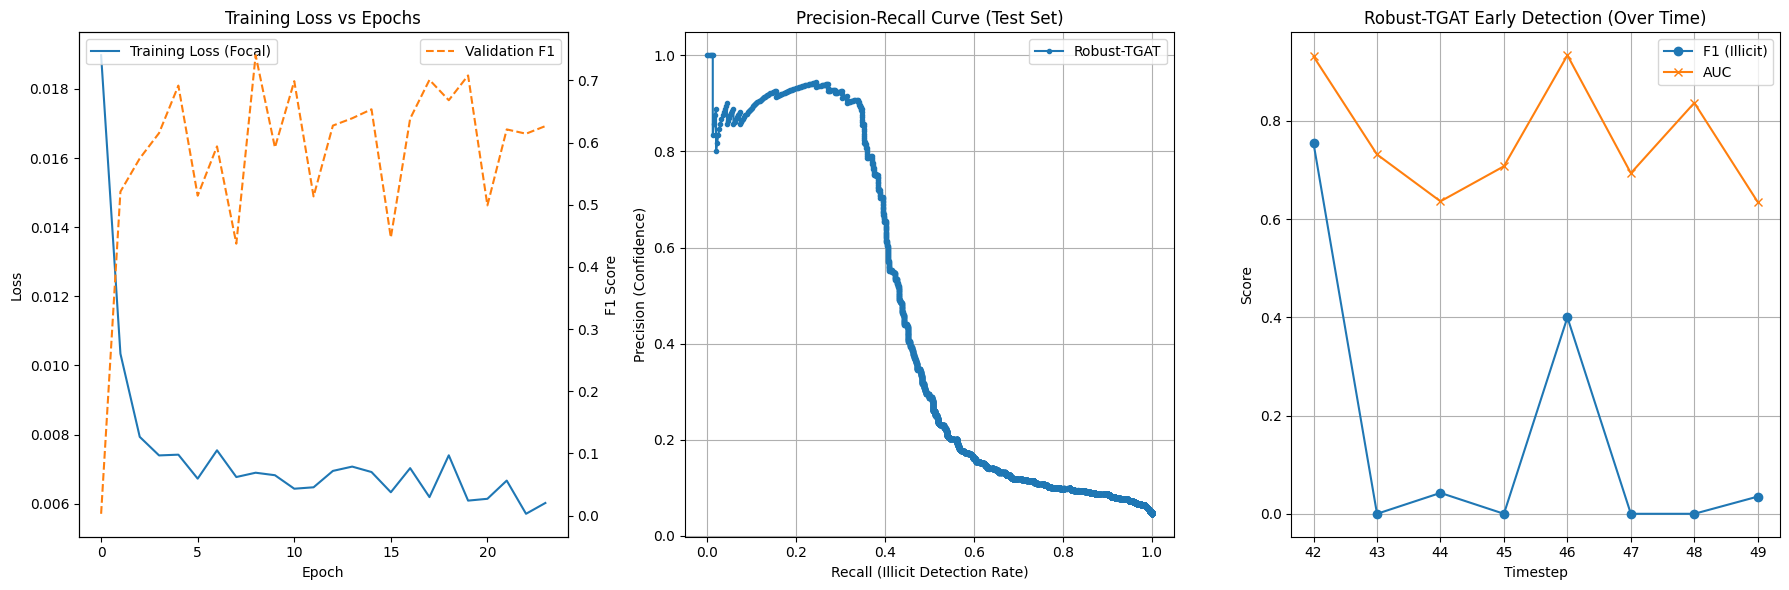

In [7]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_recall_curve, precision_score, recall_score
import matplotlib.pyplot as plt
import math

# --- 1. Load Data ---
print("Step 1: Loading Data...")
try:
    df_features = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_features.csv', header=None)
    df_classes = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_classes.csv')
    df_edgelist = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_edgelist.csv')
except FileNotFoundError:
    print("Error: CSV files not found.")
    exit()

feature_cols = ['txId', 'timestep'] + [f'local_{i}' for i in range(93)] + [f'agg_{i}' for i in range(72)]
df_features.columns = feature_cols
all_tx_ids = df_features['txId'].unique()
tx_id_map = {tx_id: i for i, tx_id in enumerate(all_tx_ids)}
df_edgelist['txId1_idx'] = df_edgelist['txId1'].map(tx_id_map)
df_edgelist['txId2_idx'] = df_edgelist['txId2'].map(tx_id_map)
df_merged = pd.merge(df_features, df_classes, on='txId', how='left')
df_merged['class'] = df_merged['class'].map({'2': 0, '1': 1, 'unknown': np.nan})
df_merged = df_merged.set_index('txId').loc[all_tx_ids].reset_index()

features_no_time = [col for col in df_features.columns if col not in ['txId', 'timestep']]
X_df = df_merged[features_no_time]
y_series = df_merged['class']
timesteps = df_merged['timestep'].values

# Train/Val/Test Split
train_mask_idx = X_df.index[(timesteps <= 34) & (y_series.notna())].values
val_mask_idx = X_df.index[(timesteps >= 35) & (timesteps <= 41) & (y_series.notna())].values
test_mask_idx = X_df.index[(timesteps >= 42) & (timesteps <= 49) & (y_series.notna())].values

scaler = StandardScaler()
X_train_features = X_df.loc[train_mask_idx]
scaler.fit(X_train_features)
X_scaled = scaler.transform(X_df)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

data = Data(
    x=torch.tensor(X_scaled, dtype=torch.float),
    edge_index=torch.tensor(df_edgelist[['txId1_idx', 'txId2_idx']].values.T, dtype=torch.long),
    y=torch.tensor(y_series.values, dtype=torch.long),
    ts=torch.tensor(timesteps, dtype=torch.float) 
)
data.train_mask = torch.tensor(train_mask_idx, dtype=torch.long)
data.val_mask = torch.tensor(val_mask_idx, dtype=torch.long)
data.test_mask = torch.tensor(test_mask_idx, dtype=torch.long)

# Loader với Neighbor Sampling
train_loader = NeighborLoader(data, num_neighbors=[10, 10], batch_size=1024, input_nodes=data.train_mask, shuffle=True)
val_loader = NeighborLoader(data, num_neighbors=[10, 10], batch_size=1024, input_nodes=data.val_mask)
test_loader = NeighborLoader(data, num_neighbors=[10, 10], batch_size=1024, input_nodes=data.test_mask)

# --- 2. Improve: Focal Loss ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        return torch.mean(F_loss)

# --- 3. Robust-TGAT Model (With increased Dropout) ---
class TimeEncoder(nn.Module):
    def __init__(self, out_channels):
        super().__init__()
        self.w = nn.Linear(1, out_channels // 2) 
        self.p = nn.Linear(1, out_channels // 2)
    def forward(self, t):
        t = t.unsqueeze(-1)
        return torch.cat([torch.cos(self.w(t) + self.p(t)), torch.sin(self.w(t) + self.p(t))], dim=-1)

class TGATLayer(MessagePassing):
    def __init__(self, in_channels, out_channels, time_channels, heads=2, dropout=0.2): # Tăng dropout mặc định lên 0.2
        super().__init__(node_dim=0, aggr='add')
        self.heads = heads
        self.head_dim = out_channels // heads
        self.dropout = dropout
        
        total_in_dim = in_channels + time_channels
        self.lin_q = nn.Linear(total_in_dim, out_channels)
        self.lin_k = nn.Linear(total_in_dim, out_channels)
        self.lin_v = nn.Linear(total_in_dim, out_channels)
        self.lin_skip = nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, t_emb):
        x_in = torch.cat([x, t_emb], dim=-1)
        q = self.lin_q(x_in).view(-1, self.heads, self.head_dim)
        k = self.lin_k(x_in).view(-1, self.heads, self.head_dim)
        v = self.lin_v(x_in).view(-1, self.heads, self.head_dim)

        out = self.propagate(edge_index, q=q, k=k, v=v, size=None)
        out = out.view(-1, self.heads * self.head_dim)
        out = out + self.lin_skip(x)
        return out

    def message(self, q_i, k_j, v_j, index, ptr, size_i):
        alpha = (q_i * k_j).sum(dim=-1) / np.sqrt(self.head_dim)
        alpha = softmax(alpha, index, ptr, size_i)
        
        # --- CẢI TIẾN: Dropout lên chính Attention Weights ---
        # Giúp tránh việc model quá tin vào một vài hàng xóm cụ thể
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        return v_j * alpha.unsqueeze(-1)

class RobustTGATModel(nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes, time_dim=32):
        super().__init__()
        self.time_enc = TimeEncoder(time_dim)
        # Tăng Dropout giữa các layer
        self.conv1 = TGATLayer(num_features, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.conv2 = TGATLayer(hidden_dim, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.lin_out = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(p=0.4) # Dropout mạnh ở lớp cuối

    def forward(self, x, edge_index, t):
        t_emb = self.time_enc(t)
        x = F.relu(self.conv1(x, edge_index, t_emb))
        x = self.dropout(x) # Apply dropout
        x = F.relu(self.conv2(x, edge_index, t_emb))
        x = self.dropout(x) # Apply dropout
        out = self.lin_out(x)
        return F.log_softmax(out, dim=1)

# --- 4. Training Setup ---
print("Step 4: Training Robust-TGAT...")
model = RobustTGATModel(
    num_features=165, 
    hidden_dim=128, 
    num_classes=2,
    time_dim=64 # Tăng dimension thời gian để bắt pattern tốt hơn
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4) # Thêm weight_decay (L2 regularization)
loss_fn = FocalLoss(alpha=0.25, gamma=2.0) # Sử dụng Focal Loss thay vì CrossEntropy

# Training Loop
train_losses, val_losses = [], []
best_val_f1 = 0 # Theo dõi F1 thay vì Loss để save model
patience = 15   # Tăng patience

for epoch in range(100): # Tăng max epoch
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Time Jittering (Data Augmentation): Thêm nhiễu nhỏ vào thời gian
        # Giúp model không học vẹt mốc thời gian chính xác
        noise = (torch.rand_like(batch.ts) - 0.5) * 0.1 
        t_noisy = batch.ts + noise
        
        out = model(batch.x, batch.edge_index, t_noisy)
        loss = loss_fn(out[:batch.batch_size], batch.y[:batch.batch_size])
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    all_val_true, all_val_pred = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.ts)
            pred = out[:batch.batch_size].argmax(dim=1)
            
            all_val_true.extend(batch.y[:batch.batch_size].cpu().numpy())
            all_val_pred.extend(pred.cpu().numpy())
            
    val_f1 = f1_score(all_val_true, all_val_pred, pos_label=1, zero_division=0)
    val_losses.append(val_f1) # Lưu F1 để vẽ biểu đồ (thực tế là metric, không phải loss)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:03d} | Train Loss: {avg_train_loss:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_robust_tgat.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping!")
            break

# --- 5. Final Evaluation ---
print("\nStep 5: Final Evaluation...")
model.load_state_dict(torch.load('best_robust_tgat.pth'))
model.eval()

all_true, all_pred, all_proba, all_ts = [], [], [], []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.ts)
        
        target_out = out[:batch.batch_size]
        target_ts = batch.ts[:batch.batch_size].cpu().numpy()
        
        all_true.append(batch.y[:batch.batch_size].cpu().numpy())
        all_pred.append(target_out.argmax(dim=1).cpu().numpy())
        all_proba.append(target_out.exp()[:, 1].cpu().numpy())
        all_ts.append(target_ts)

y_true = np.concatenate(all_true)
y_pred = np.concatenate(all_pred)
y_proba = np.concatenate(all_proba)
timesteps_test = np.concatenate(all_ts)

print("\n--- ROBUST-TGAT RESULTS ---")
print(classification_report(y_true, y_pred, target_names=['Licit', 'Illicit']))
print(f"ROC AUC: {roc_auc_score(y_true, y_proba):.4f}")

# Visualize Early Detection
unique_ts = sorted(np.unique(timesteps_test))
f1_time, auc_time = [], []

for t in unique_ts:
    mask = (timesteps_test == t)
    if np.sum(mask) > 0 and len(np.unique(y_true[mask])) > 1:
        f1_time.append(f1_score(y_true[mask], y_pred[mask], pos_label=1, zero_division=0))
        auc_time.append(roc_auc_score(y_true[mask], y_proba[mask]))
    else:
        f1_time.append(0.0)
        auc_time.append(0.5)

#plt.figure(figsize=(12, 5))
#plt.plot(unique_ts, f1_time, marker='o', label='F1 (Illicit)')
#plt.plot(unique_ts, auc_time, marker='x', label='AUC')
#plt.title('Robust-TGAT Early Detection')
#plt.xlabel('Timestep')
#plt.ylabel('Score')
#plt.legend()
#plt.grid(True)
#plt.savefig('robust_tgat_results.png')
#print("Saved result plot.")
# --- Step 6: Full Visualization (Bổ sung) ---
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

print("Vẽ biểu đồ tổng hợp cho Robust-TGAT...")

plt.figure(figsize=(18, 6))

# 1. Biểu đồ Loss và Validation F1
# Lưu ý: Trong code Robust-TGAT, list 'val_losses' thực chất lưu trữ 'Val F1'
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Training Loss (Focal)', color='tab:blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs Epochs')
plt.legend(loc='upper left')

# Tạo trục y thứ 2 để vẽ F1 (vì Loss giảm, F1 tăng, vẽ chung 1 trục sẽ khó nhìn)
ax2 = plt.gca().twinx()
ax2.plot(val_losses, label='Validation F1', color='tab:orange', linestyle='--')
ax2.set_ylabel('F1 Score')
ax2.legend(loc='upper right')
#plt.title('Training Loss & Validation F1')

# 2. Biểu đồ Precision-Recall (Tổng thể)
plt.subplot(1, 3, 2)
precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_proba, pos_label=1)
plt.plot(recall_curve, precision_curve, marker='.', label='Robust-TGAT')
plt.title('Precision-Recall Curve (Test Set)')
plt.xlabel('Recall (Illicit Detection Rate)')
plt.ylabel('Precision (Confidence)')
plt.grid(True)
plt.legend()

# 3. Biểu đồ Early Detection (Vẽ lại cho đồng bộ)
plt.subplot(1, 3, 3)
plt.plot(unique_ts, f1_time, marker='o', label='F1 (Illicit)')
plt.plot(unique_ts, auc_time, marker='x', label='AUC')
plt.title('Robust-TGAT Early Detection (Over Time)')
plt.xlabel('Timestep')
plt.ylabel('Score')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig('robust_tgat_full_report.png')
print("Đã lưu biểu đồ tổng hợp: 'robust_tgat_full_report.png'")
plt.show()

apply k-fold

Step 1: Loading Data...
Scaling data...
Running on: cuda

--- STARTING TEMPORAL K-FOLD (5 Folds) ---

==================== RUNNING Fold 1 ====================
Best Threshold: 0.50

--- DETAILED REPORT FOR Fold 1 ---
              precision    recall  f1-score   support

       Licit       0.96      0.99      0.97      4745
     Illicit       0.86      0.64      0.73       566

    accuracy                           0.95      5311
   macro avg       0.91      0.81      0.85      5311
weighted avg       0.95      0.95      0.95      5311

ROC AUC: 0.8972
Saved plot: report_Fold_1.png


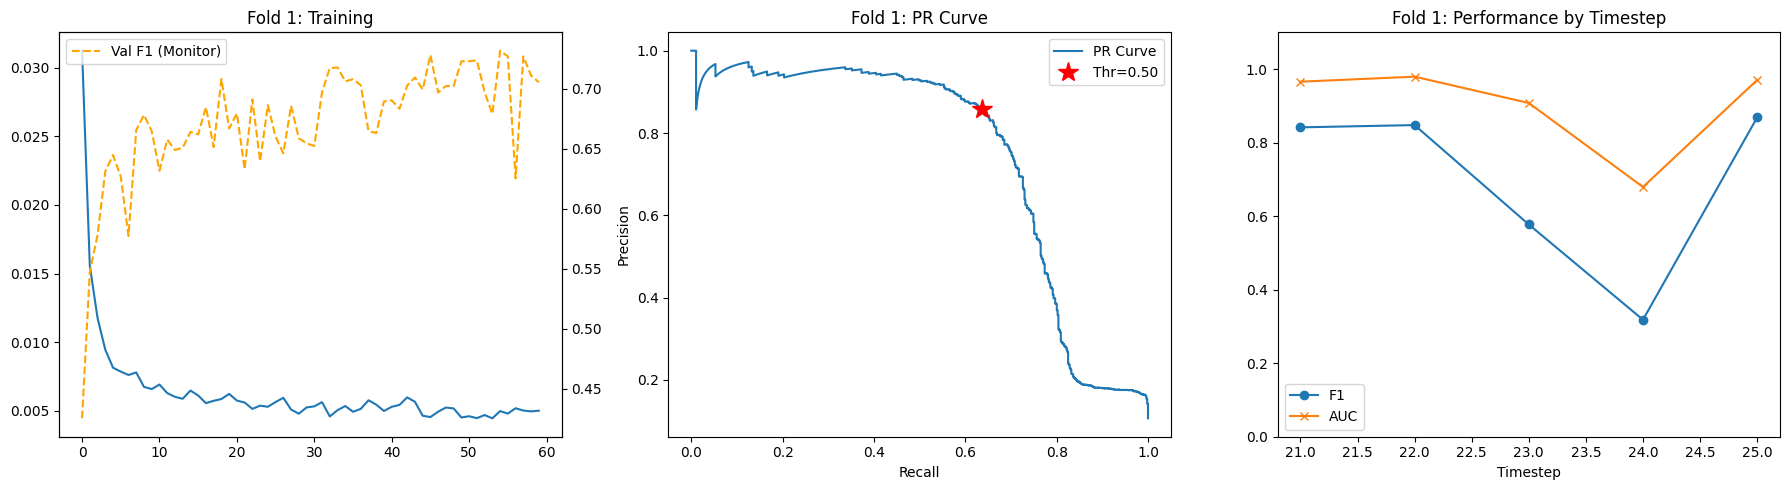


==================== RUNNING Fold 2 ====================
Best Threshold: 0.50

--- DETAILED REPORT FOR Fold 2 ---
              precision    recall  f1-score   support

       Licit       0.98      0.97      0.98      2088
     Illicit       0.91      0.93      0.92       617

    accuracy                           0.96      2705
   macro avg       0.94      0.95      0.95      2705
weighted avg       0.96      0.96      0.96      2705

ROC AUC: 0.9870
Saved plot: report_Fold_2.png


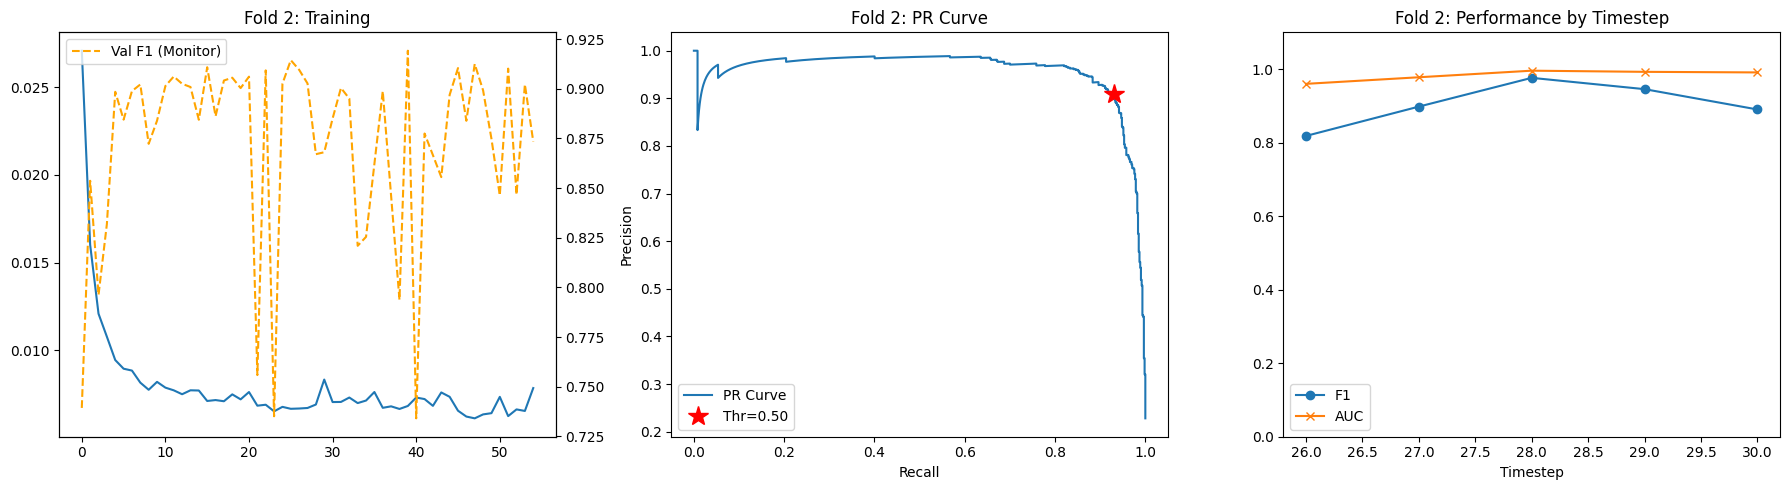


==================== RUNNING Fold 3 ====================
Best Threshold: 0.45

--- DETAILED REPORT FOR Fold 3 ---
              precision    recall  f1-score   support

       Licit       0.98      0.96      0.97      3640
     Illicit       0.81      0.87      0.84       690

    accuracy                           0.95      4330
   macro avg       0.89      0.92      0.90      4330
weighted avg       0.95      0.95      0.95      4330

ROC AUC: 0.9697
Saved plot: report_Fold_3.png


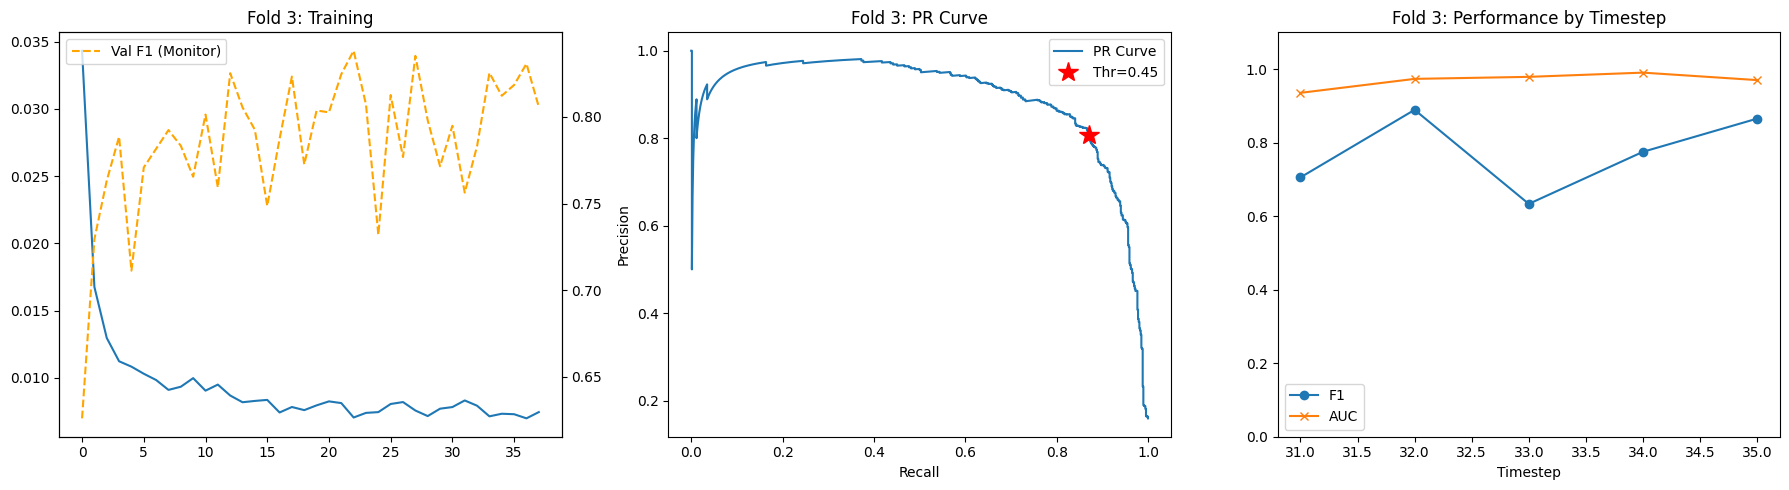


==================== RUNNING Fold 4 ====================
Best Threshold: 0.50

--- DETAILED REPORT FOR Fold 4 ---
              precision    recall  f1-score   support

       Licit       0.97      0.99      0.98      5995
     Illicit       0.85      0.64      0.73       493

    accuracy                           0.96      6488
   macro avg       0.91      0.82      0.86      6488
weighted avg       0.96      0.96      0.96      6488

ROC AUC: 0.9205
Saved plot: report_Fold_4.png


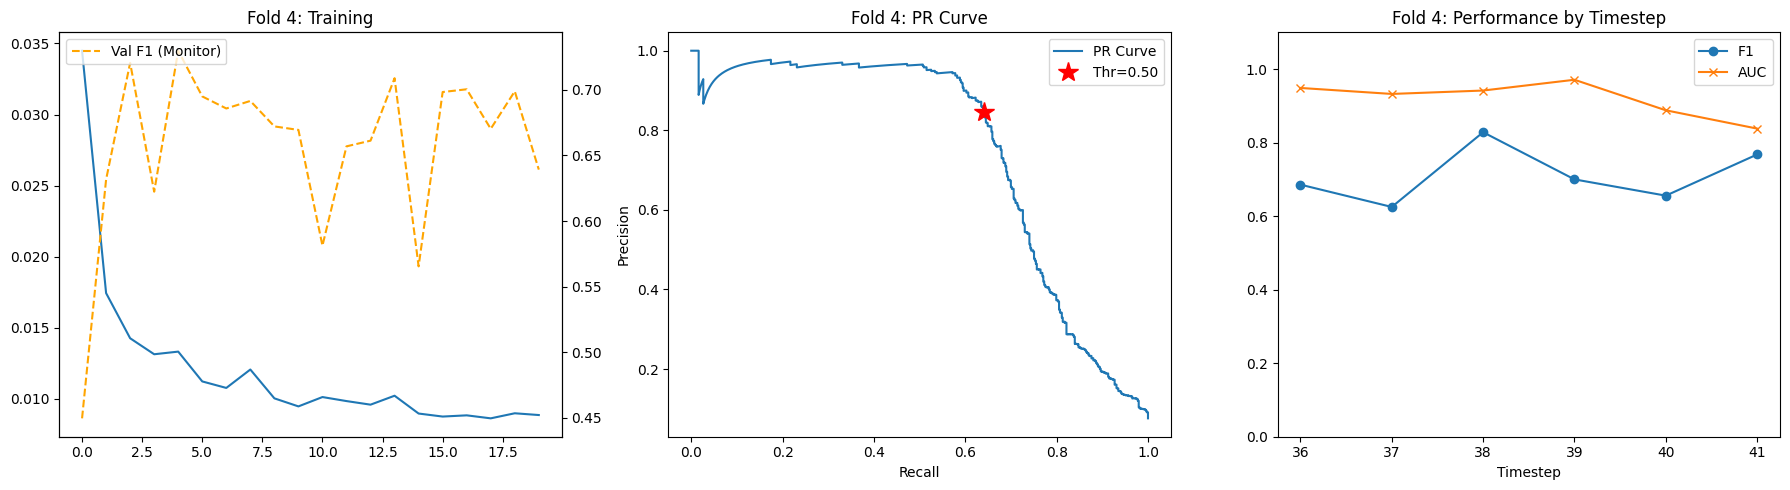


==================== RUNNING Fold 5 ====================
Best Threshold: 0.25

--- DETAILED REPORT FOR Fold 5 ---
              precision    recall  f1-score   support

       Licit       0.99      0.70      0.82      6518
     Illicit       0.06      0.70      0.11       169

    accuracy                           0.70      6687
   macro avg       0.52      0.70      0.46      6687
weighted avg       0.97      0.70      0.80      6687

ROC AUC: 0.7728
Saved plot: report_Fold_5.png


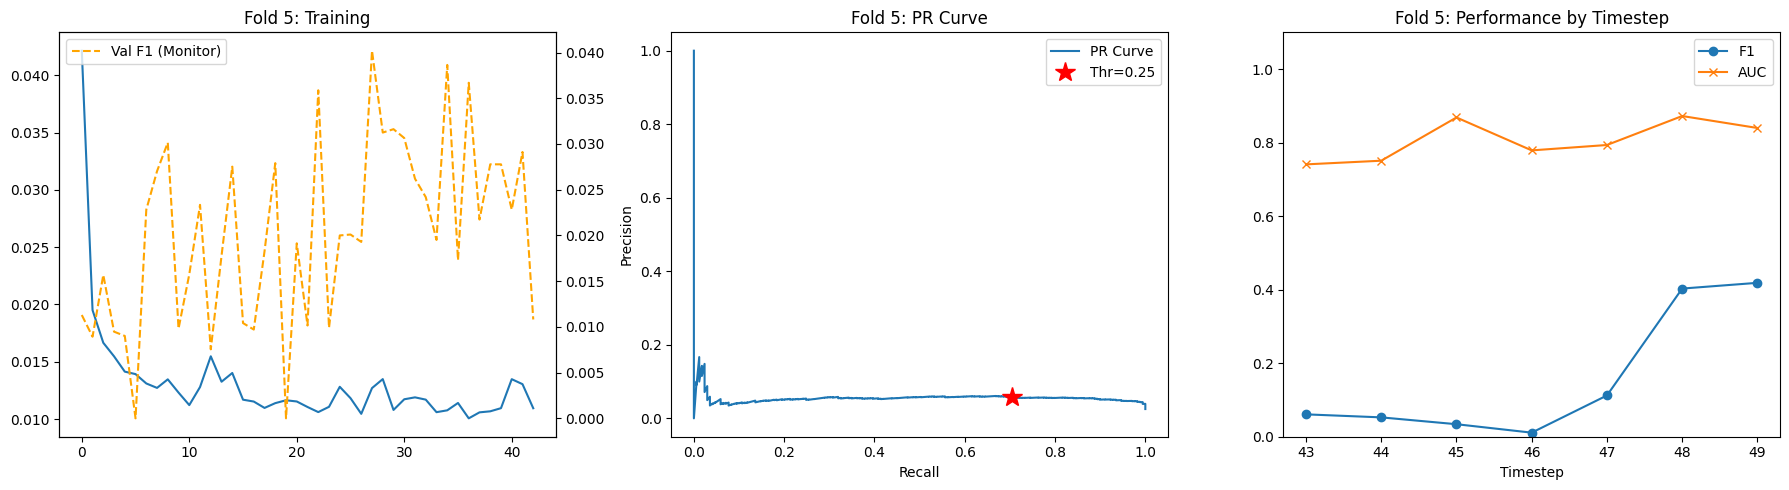



================ K-FOLD SUMMARY ================
     Fold       AUC        F1    Recall  Precision
0  Fold 1  0.897211  0.730223  0.636042   0.857143
1  Fold 2  0.986997  0.919872  0.930308   0.909667
2  Fold 3  0.969705  0.837631  0.871014   0.806711
3  Fold 4  0.920479  0.729792  0.640974   0.847185
4  Fold 5  0.772775  0.106488  0.704142   0.057599
------------------------------------------------------------
Average AUC: 0.9094
Average F1:  0.6648


In [10]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_recall_curve, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import math
import random
import os

# --- 0. REPRODUCIBILITY ---
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(80)

# --- 1. LOAD & PROCESS DATA ---
print("Step 1: Loading Data...")
try:
    base_path = '/kaggle/input/elliptic/elliptic/' 
    df_features = pd.read_csv(base_path + 'elliptic_txs_features.csv', header=None)
    df_classes = pd.read_csv(base_path + 'elliptic_txs_classes.csv')
    df_edgelist = pd.read_csv(base_path + 'elliptic_txs_edgelist.csv')
except FileNotFoundError:
    try:
        df_features = pd.read_csv('elliptic_txs_features.csv', header=None)
        df_classes = pd.read_csv('elliptic_txs_classes.csv')
        df_edgelist = pd.read_csv('elliptic_txs_edgelist.csv')
    except:
        print("Error: CSV files not found.")
        exit()

feature_cols = ['txId', 'timestep'] + [f'local_{i}' for i in range(93)] + [f'agg_{i}' for i in range(72)]
df_features.columns = feature_cols
all_tx_ids = df_features['txId'].unique()
tx_id_map = {tx_id: i for i, tx_id in enumerate(all_tx_ids)}

df_edgelist['txId1_idx'] = df_edgelist['txId1'].map(tx_id_map)
df_edgelist['txId2_idx'] = df_edgelist['txId2'].map(tx_id_map)

df_merged = pd.merge(df_features, df_classes, on='txId', how='left')
df_merged['class'] = df_merged['class'].map({'2': 0, '1': 1, 'unknown': np.nan})
df_merged = df_merged.set_index('txId').loc[all_tx_ids].reset_index()

features_no_time = [col for col in df_features.columns if col not in ['txId', 'timestep']]
X_df = df_merged[features_no_time]
y_series = df_merged['class']
timesteps = df_merged['timestep'].values

print("Scaling data...")
scaler = StandardScaler()
# Fit scaler on first 20 timesteps to avoid leakage in early folds
init_train_idx = X_df.index[timesteps <= 20].values
scaler.fit(X_df.loc[init_train_idx])
X_scaled = scaler.transform(X_df)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

data = Data(
    x=torch.tensor(X_scaled, dtype=torch.float),
    edge_index=torch.tensor(df_edgelist[['txId1_idx', 'txId2_idx']].values.T, dtype=torch.long),
    y=torch.tensor(y_series.fillna(-1).values, dtype=torch.long),
    ts=torch.tensor(timesteps, dtype=torch.float) 
)

# --- 2. MODEL COMPONENTS ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.7, gamma=2.0): 
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        alphas = torch.where(targets == 1, self.alpha, 1.0 - self.alpha)
        F_loss = alphas * (1-pt)**self.gamma * ce_loss
        return torch.mean(F_loss)

class TimeEncoder(nn.Module):
    def __init__(self, out_channels):
        super().__init__()
        self.w = nn.Linear(1, out_channels // 2) 
        self.p = nn.Linear(1, out_channels // 2)
    def forward(self, t):
        t = t.unsqueeze(-1)
        return torch.cat([torch.cos(self.w(t) + self.p(t)), torch.sin(self.w(t) + self.p(t))], dim=-1)

class TGATLayer(MessagePassing):
    def __init__(self, in_channels, out_channels, time_channels, heads=2, dropout=0.2):
        super().__init__(node_dim=0, aggr='add')
        self.heads = heads
        self.head_dim = out_channels // heads
        self.dropout = dropout
        self.lin_q = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_k = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_v = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_skip = nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, t_emb):
        x_in = torch.cat([x, t_emb], dim=-1)
        q = self.lin_q(x_in).view(-1, self.heads, self.head_dim)
        k = self.lin_k(x_in).view(-1, self.heads, self.head_dim)
        v = self.lin_v(x_in).view(-1, self.heads, self.head_dim)
        out = self.propagate(edge_index, q=q, k=k, v=v, size=None)
        out = out.view(-1, self.heads * self.head_dim)
        out = out + self.lin_skip(x)
        return out

    def message(self, q_i, k_j, v_j, index, ptr, size_i):
        alpha = (q_i * k_j).sum(dim=-1) / np.sqrt(self.head_dim)
        alpha = softmax(alpha, index, ptr, size_i)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        return v_j * alpha.unsqueeze(-1)

class RobustTGATModel(nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes, time_dim=32):
        super().__init__()
        self.time_enc = TimeEncoder(time_dim)
        self.conv1 = TGATLayer(num_features, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.conv2 = TGATLayer(hidden_dim, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.lin_out = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(p=0.3) 

    def forward(self, x, edge_index, t):
        t_emb = self.time_enc(t)
        x = F.relu(self.conv1(x, edge_index, t_emb))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index, t_emb))
        x = self.dropout(x)
        out = self.lin_out(x)
        return out 

# --- 3. TEMPORAL K-FOLD SETUP ---
folds = [
    {'name': 'Fold 1', 'train_end': 20, 'val_start': 21, 'val_end': 25},
    {'name': 'Fold 2', 'train_end': 25, 'val_start': 26, 'val_end': 30},
    {'name': 'Fold 3', 'train_end': 30, 'val_start': 31, 'val_end': 35},
    {'name': 'Fold 4', 'train_end': 35, 'val_start': 36, 'val_end': 41},
    {'name': 'Fold 5', 'train_end': 42, 'val_start': 43, 'val_end': 49}
]

fold_metrics = []

print(f"\n--- STARTING TEMPORAL K-FOLD ({len(folds)} Folds) ---")

for fold in folds:
    print(f"\n{'='*20} RUNNING {fold['name']} {'='*20}")
    
    # 1. Setup Masks & Loaders
    train_mask_idx = torch.where((data.ts <= fold['train_end']) & (data.y != -1))[0]
    val_mask_idx = torch.where((data.ts >= fold['val_start']) & (data.ts <= fold['val_end']) & (data.y != -1))[0]
    
    train_loader = NeighborLoader(data, num_neighbors=[15, 10], batch_size=1024, input_nodes=train_mask_idx, shuffle=True)
    val_loader = NeighborLoader(data, num_neighbors=[15, 10], batch_size=2048, input_nodes=val_mask_idx)
    
    # 2. Reset Model
    model = RobustTGATModel(num_features=165, hidden_dim=128, num_classes=2, time_dim=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
    loss_fn = FocalLoss(alpha=0.7, gamma=2.0)
    
    # Lists for Plotting
    fold_train_losses = []
    fold_val_f1s = []
    
    # 3. Training Loop
    best_fold_f1 = 0
    patience = 15
    patience_cnt = 0
    
    for epoch in range(60):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            noise = (torch.rand_like(batch.ts) - 0.5) * 0.1 
            t_noisy = batch.ts + noise
            out = model(batch.x, batch.edge_index, t_noisy)
            loss = loss_fn(out[:batch.batch_size], batch.y[:batch.batch_size])
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        avg_loss = total_loss / len(train_loader)
        fold_train_losses.append(avg_loss)

        # Validation
        model.eval()
        y_true, y_prob = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.ts)
                prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1]
                y_true.extend(batch.y[:batch.batch_size].cpu().numpy())
                y_prob.extend(prob.cpu().numpy())
        
        # Monitor F1 (Thr 0.5)
        pred_mon = (np.array(y_prob) > 0.5).astype(int)
        curr_f1 = f1_score(y_true, pred_mon, pos_label=1, zero_division=0)
        fold_val_f1s.append(curr_f1)
        
        if curr_f1 > best_fold_f1:
            best_fold_f1 = curr_f1
            torch.save(model.state_dict(), f'best_model_{fold["name"].replace(" ", "")}.pth')
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                break
    
    # 4. Final Evaluation for this Fold
    model.load_state_dict(torch.load(f'best_model_{fold["name"].replace(" ", "")}.pth'))
    model.eval()
    
    y_true_final, y_prob_final, y_ts_final = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.ts)
            prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1]
            
            y_true_final.extend(batch.y[:batch.batch_size].cpu().numpy())
            y_prob_final.extend(prob.cpu().numpy())
            y_ts_final.extend(batch.ts[:batch.batch_size].cpu().numpy())
            
    # Find Smart Threshold
    best_thr = 0.5
    best_f1_val = 0
    for thr in np.arange(0.2, 0.7, 0.05):
        p = (np.array(y_prob_final) > thr).astype(int)
        f = f1_score(y_true_final, p, pos_label=1, zero_division=0)
        if f > best_f1_val:
            best_f1_val = f
            best_thr = thr
            
    final_preds = (np.array(y_prob_final) > best_thr).astype(int)
    
    # --- METRICS & REPORTING ---
    auc = roc_auc_score(y_true_final, y_prob_final)
    rec = recall_score(y_true_final, final_preds, pos_label=1, zero_division=0)
    prec = precision_score(y_true_final, final_preds, pos_label=1, zero_division=0)
    
    print(f"Best Threshold: {best_thr:.2f}")
    print(f"\n--- DETAILED REPORT FOR {fold['name']} ---")
    print(classification_report(y_true_final, final_preds, target_names=['Licit', 'Illicit']))
    print(f"ROC AUC: {auc:.4f}")
    
    fold_metrics.append({'Fold': fold['name'], 'AUC': auc, 'F1': best_f1_val, 'Recall': rec, 'Precision': prec})

    # --- VISUALIZATION PER FOLD ---
    unique_ts = sorted(np.unique(y_ts_final))
    f1_time, auc_time = [], []
    y_true_final = np.array(y_true_final)
    y_prob_final = np.array(y_prob_final)
    y_ts_final = np.array(y_ts_final)
    final_preds = np.array(final_preds)

    for t in unique_ts:
        mask = (y_ts_final == t)
        if np.sum(mask) > 0 and len(np.unique(y_true_final[mask])) > 1:
            f1_time.append(f1_score(y_true_final[mask], final_preds[mask], pos_label=1, zero_division=0))
            auc_time.append(roc_auc_score(y_true_final[mask], y_prob_final[mask]))
        else:
            f1_time.append(0.0)
            auc_time.append(0.5)

    # Plotting 3 charts for THIS fold
    plt.figure(figsize=(18, 5))
    
    # Chart 1: Loss & Monitor F1
    plt.subplot(1, 3, 1)
    plt.plot(fold_train_losses, label='Train Loss')
    ax2 = plt.gca().twinx()
    ax2.plot(fold_val_f1s, label='Val F1 (Monitor)', color='orange', linestyle='--')
    plt.title(f'{fold["name"]}: Training')
    plt.legend(loc='upper left')
    
    # Chart 2: PR Curve
    plt.subplot(1, 3, 2)
    prec_curve, rec_curve, _ = precision_recall_curve(y_true_final, y_prob_final, pos_label=1)
    plt.plot(rec_curve, prec_curve, label='PR Curve')
    plt.plot(rec, prec, 'r*', markersize=15, label=f'Thr={best_thr:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{fold["name"]}: PR Curve')
    plt.legend()
    
    # Chart 3: Early Detection
    plt.subplot(1, 3, 3)
    plt.plot(unique_ts, f1_time, marker='o', label='F1')
    plt.plot(unique_ts, auc_time, marker='x', label='AUC')
    plt.title(f'{fold["name"]}: Performance by Timestep')
    plt.xlabel('Timestep')
    plt.ylim(0, 1.1)
    plt.legend()
    
    plt.tight_layout()
    filename = f'report_{fold["name"].replace(" ", "_")}.png'
    plt.savefig(filename)
    print(f"Saved plot: {filename}")
    plt.show()

# --- 5. SUMMARY ---
print("\n\n================ K-FOLD SUMMARY ================")
df_res = pd.DataFrame(fold_metrics)
print(df_res)
print("-" * 60)
print(f"Average AUC: {df_res['AUC'].mean():.4f}")
print(f"Average F1:  {df_res['F1'].mean():.4f}")

version moi

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_recall_curve, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import math
import random
import os

# --- 0. REPRODUCIBILITY ---
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(80)

# --- 1. LOAD PROCESSED DATA ---
print("Step 1: Loading Data...")
try:
    # Load dữ liệu đã xử lý ở Part 1 để tiết kiệm thời gian
    dtype_dict = {'node_idx': 'int32', 'timestep': 'int32', 'class_label': 'float32'}
    for i in range(165): dtype_dict[f'feat_{i}'] = 'float32'
    
    df_nodes = pd.read_csv('processed_nodes.csv', dtype=dtype_dict)
    df_edges = pd.read_csv('processed_edges.csv', dtype={'source_idx': 'int32', 'target_idx': 'int32'})
except FileNotFoundError:
    print("Lỗi: Không tìm thấy file 'processed_nodes.csv'. Hãy chạy Part 1 (Preprocessing) trước.")
    exit()

print("Converting to PyTorch Tensors...")
feature_cols = [c for c in df_nodes.columns if c.startswith('feat_')]
x = torch.tensor(df_nodes[feature_cols].values, dtype=torch.float)
y = torch.tensor(df_nodes['class_label'].fillna(-1).values, dtype=torch.long)
edge_index = torch.tensor(df_edges[['source_idx', 'target_idx']].values.T, dtype=torch.long)
ts = torch.tensor(df_nodes['timestep'].values, dtype=torch.float)

# Data Object gốc (Chưa chia mask)
full_data = Data(x=x, edge_index=edge_index, y=y, ts=ts)

# Dọn dẹp RAM
del df_nodes, df_edges
import gc
gc.collect()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

# --- 2. MODEL COMPONENTS ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.7, gamma=2.0): 
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        alphas = torch.where(targets == 1, self.alpha, 1.0 - self.alpha)
        F_loss = alphas * (1-pt)**self.gamma * ce_loss
        return torch.mean(F_loss)

class TimeEncoder(nn.Module):
    def __init__(self, out_channels):
        super().__init__()
        self.w = nn.Linear(1, out_channels // 2) 
        self.p = nn.Linear(1, out_channels // 2)
    def forward(self, t):
        t = t.unsqueeze(-1)
        return torch.cat([torch.cos(self.w(t) + self.p(t)), torch.sin(self.w(t) + self.p(t))], dim=-1)

class TGATLayer(MessagePassing):
    def __init__(self, in_channels, out_channels, time_channels, heads=2, dropout=0.2):
        super().__init__(node_dim=0, aggr='add')
        self.heads = heads
        self.head_dim = out_channels // heads
        self.dropout = dropout
        self.lin_q = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_k = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_v = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_skip = nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, t_emb):
        x_in = torch.cat([x, t_emb], dim=-1)
        q = self.lin_q(x_in).view(-1, self.heads, self.head_dim)
        k = self.lin_k(x_in).view(-1, self.heads, self.head_dim)
        v = self.lin_v(x_in).view(-1, self.heads, self.head_dim)
        out = self.propagate(edge_index, q=q, k=k, v=v, size=None)
        out = out.view(-1, self.heads * self.head_dim)
        out = out + self.lin_skip(x)
        return out

    def message(self, q_i, k_j, v_j, index, ptr, size_i):
        alpha = (q_i * k_j).sum(dim=-1) / np.sqrt(self.head_dim)
        alpha = softmax(alpha, index, ptr, size_i)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        return v_j * alpha.unsqueeze(-1)

class RobustTGATModel(nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes, time_dim=32):
        super().__init__()
        self.time_enc = TimeEncoder(time_dim)
        self.conv1 = TGATLayer(num_features, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.conv2 = TGATLayer(hidden_dim, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.lin_out = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(p=0.3) 

    def forward(self, x, edge_index, t):
        t_emb = self.time_enc(t)
        x = F.relu(self.conv1(x, edge_index, t_emb))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index, t_emb))
        x = self.dropout(x)
        out = self.lin_out(x)
        return out 

# --- 3. TEMPORAL K-FOLD WITH FORGETTING MECHANISM ---
folds = [
    {'name': 'Fold 1', 'train_end': 20, 'val_start': 21, 'val_end': 25},
    {'name': 'Fold 2', 'train_end': 25, 'val_start': 26, 'val_end': 30},
    {'name': 'Fold 3', 'train_end': 30, 'val_start': 31, 'val_end': 35},
    {'name': 'Fold 4', 'train_end': 35, 'val_start': 36, 'val_end': 41},
    {'name': 'Fold 5 (Final)', 'train_end': 42, 'val_start': 43, 'val_end': 49}
]

fold_metrics = []
print(f"\n--- STARTING TEMPORAL K-FOLD ({len(folds)} Folds) ---")

for fold in folds:
    print(f"\n{'='*20} RUNNING {fold['name']} {'='*20}")
    
    # --- CHIẾN LƯỢC QUÊN (FORGETTING MECHANISM) ---
    start_train_ts = 1
    if fold['name'] == 'Fold 5 (Final)':
        start_train_ts = 15 # Bỏ 15 timestep đầu (dữ liệu quá khứ nhiễu)
        print(f"    [Strategy] Handling Concept Drift: Dropping data from TS 1-{start_train_ts}")
    else:
        print(f"    Train: 1 -> {fold['train_end']}")
        
    print(f"    Valid: {fold['val_start']} -> {fold['val_end']}")
    
    # 1. Setup Masks
    train_mask_idx = torch.where(
        (full_data.ts >= start_train_ts) &  # Điều kiện cắt dữ liệu cũ
        (full_data.ts <= fold['train_end']) & 
        (full_data.y != -1)
    )[0]
    
    val_mask_idx = torch.where((full_data.ts >= fold['val_start']) & (full_data.ts <= fold['val_end']) & (full_data.y != -1))[0]
    
    train_loader = NeighborLoader(full_data, num_neighbors=[15, 10], batch_size=1024, input_nodes=train_mask_idx, shuffle=True)
    val_loader = NeighborLoader(full_data, num_neighbors=[15, 10], batch_size=2048, input_nodes=val_mask_idx)
    
    # 2. Reset Model
    model = RobustTGATModel(num_features=165, hidden_dim=128, num_classes=2, time_dim=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
    loss_fn = FocalLoss(alpha=0.7, gamma=2.0)
    
    # Lists for Plotting
    fold_train_losses = []
    fold_val_f1s = []
    
    # 3. Training Loop
    best_fold_f1 = 0
    patience = 15
    patience_cnt = 0
    
    for epoch in range(60):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            noise = (torch.rand_like(batch.ts) - 0.5) * 0.1 
            t_noisy = batch.ts + noise
            out = model(batch.x, batch.edge_index, t_noisy)
            loss = loss_fn(out[:batch.batch_size], batch.y[:batch.batch_size])
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        avg_loss = total_loss / len(train_loader)
        fold_train_losses.append(avg_loss)

        # Validation
        model.eval()
        y_true, y_prob = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.ts)
                prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1]
                y_true.extend(batch.y[:batch.batch_size].cpu().numpy())
                y_prob.extend(prob.cpu().numpy())
        
        # Monitor F1
        pred_mon = (np.array(y_prob) > 0.5).astype(int)
        curr_f1 = f1_score(y_true, pred_mon, pos_label=1, zero_division=0)
        fold_val_f1s.append(curr_f1)
        
        if curr_f1 > best_fold_f1:
            best_fold_f1 = curr_f1
            torch.save(model.state_dict(), f'best_model_{fold["name"].replace(" ", "_").replace("(", "").replace(")", "")}.pth')
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                break
    
    # 4. Final Evaluation for this Fold
    model_name = f'best_model_{fold["name"].replace(" ", "_").replace("(", "").replace(")", "")}.pth'
    model.load_state_dict(torch.load(model_name))
    model.eval()
    
    y_true_final, y_prob_final, y_ts_final = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.ts)
            prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1]
            
            y_true_final.extend(batch.y[:batch.batch_size].cpu().numpy())
            y_prob_final.extend(prob.cpu().numpy())
            y_ts_final.extend(batch.ts[:batch.batch_size].cpu().numpy())
            
    # Smart Threshold Search
    best_thr = 0.5
    best_f1_val = 0
    for thr in np.arange(0.2, 0.7, 0.05):
        p = (np.array(y_prob_final) > thr).astype(int)
        f = f1_score(y_true_final, p, pos_label=1, zero_division=0)
        if f > best_f1_val:
            best_f1_val = f
            best_thr = thr
            
    final_preds = (np.array(y_prob_final) > best_thr).astype(int)
    
    # Metrics
    auc = roc_auc_score(y_true_final, y_prob_final)
    rec = recall_score(y_true_final, final_preds, pos_label=1, zero_division=0)
    prec = precision_score(y_true_final, final_preds, pos_label=1, zero_division=0)
    
    print(f"    Best Threshold: {best_thr:.2f}")
    print(f"    Result: AUC={auc:.4f} | F1={best_f1_val:.4f} | Rec={rec:.4f}")
    print(f"    Confusion Matrix:\n{confusion_matrix(y_true_final, final_preds)}")
    
    fold_metrics.append({'Fold': fold['name'], 'AUC': auc, 'F1': best_f1_val, 'Recall': rec, 'Precision': prec})

    # --- VISUALIZATION PER FOLD ---
    unique_ts = sorted(np.unique(y_ts_final))
    f1_time, auc_time = [], []
    y_true_final = np.array(y_true_final)
    y_prob_final = np.array(y_prob_final)
    y_ts_final = np.array(y_ts_final)
    final_preds = np.array(final_preds)

    for t in unique_ts:
        mask = (y_ts_final == t)
        if np.sum(mask) > 0 and len(np.unique(y_true_final[mask])) > 1:
            f1_time.append(f1_score(y_true_final[mask], final_preds[mask], pos_label=1, zero_division=0))
            auc_time.append(roc_auc_score(y_true_final[mask], y_prob_final[mask]))
        else:
            f1_time.append(0.0)
            auc_time.append(0.5)

    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(fold_train_losses, label='Train Loss')
    ax2 = plt.gca().twinx()
    ax2.plot(fold_val_f1s, label='Val F1 (Monitor)', color='orange', linestyle='--')
    plt.title(f'{fold["name"]}: Training')
    plt.legend(loc='upper left')
    
    plt.subplot(1, 3, 2)
    prec_curve, rec_curve, _ = precision_recall_curve(y_true_final, y_prob_final, pos_label=1)
    plt.plot(rec_curve, prec_curve, label='PR Curve')
    plt.plot(rec, prec, 'r*', markersize=15, label=f'Thr={best_thr:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{fold["name"]}: PR Curve')
    plt.legend()
    
    plt.subplot(1, 3, 3)
    plt.plot(unique_ts, f1_time, marker='o', label='F1')
    plt.plot(unique_ts, auc_time, marker='x', label='AUC')
    plt.title(f'{fold["name"]}: Per Timestep')
    plt.xlabel('Timestep')
    plt.ylim(0, 1.1)
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(f'report_{fold["name"].replace(" ", "_").replace("(", "").replace(")", "")}.png')
    plt.show()

# --- 5. SUMMARY & SAVE FINAL MODEL ---
print("\n\n================ K-FOLD SUMMARY ================")
df_res = pd.DataFrame(fold_metrics)
print(df_res)
print("-" * 60)
print(f"Average AUC: {df_res['AUC'].mean():.4f} (+/- {df_res['AUC'].std():.4f})")
print(f"Average F1:  {df_res['F1'].mean():.4f} (+/- {df_res['F1'].std():.4f})")

# Save Final Production Model (Fold 5)
final_fold_name = 'best_model_Fold_5_Final.pth'
if os.path.exists(final_fold_name):
    import shutil
    shutil.copy(final_fold_name, 'robust_tgat_production.pth')
    print("\n[SUCCESS] Saved Final Model as 'robust_tgat_production.pth'")
    print("This model is optimized for recent data patterns (TS 15-42 -> Predict 43+).")

all no sprate data part

Step 1: Loading & Processing Raw Data...
   -> Scaling features...
   -> Creating Graph Object...
Data Ready. Nodes: 203769. Device: cuda

--- STARTING TEMPORAL K-FOLD (5 Folds) ---

==================== RUNNING Fold 1 ====================
    Train: 1 -> 20
    Valid: 21 -> 25

[REPORT] Fold 1 (Threshold: 0.50)
              precision    recall  f1-score   support

       Licit       0.96      0.98      0.97      4745
     Illicit       0.79      0.68      0.73       566

    accuracy                           0.95      5311
   macro avg       0.88      0.83      0.85      5311
weighted avg       0.94      0.95      0.95      5311

ROC AUC: 0.8988


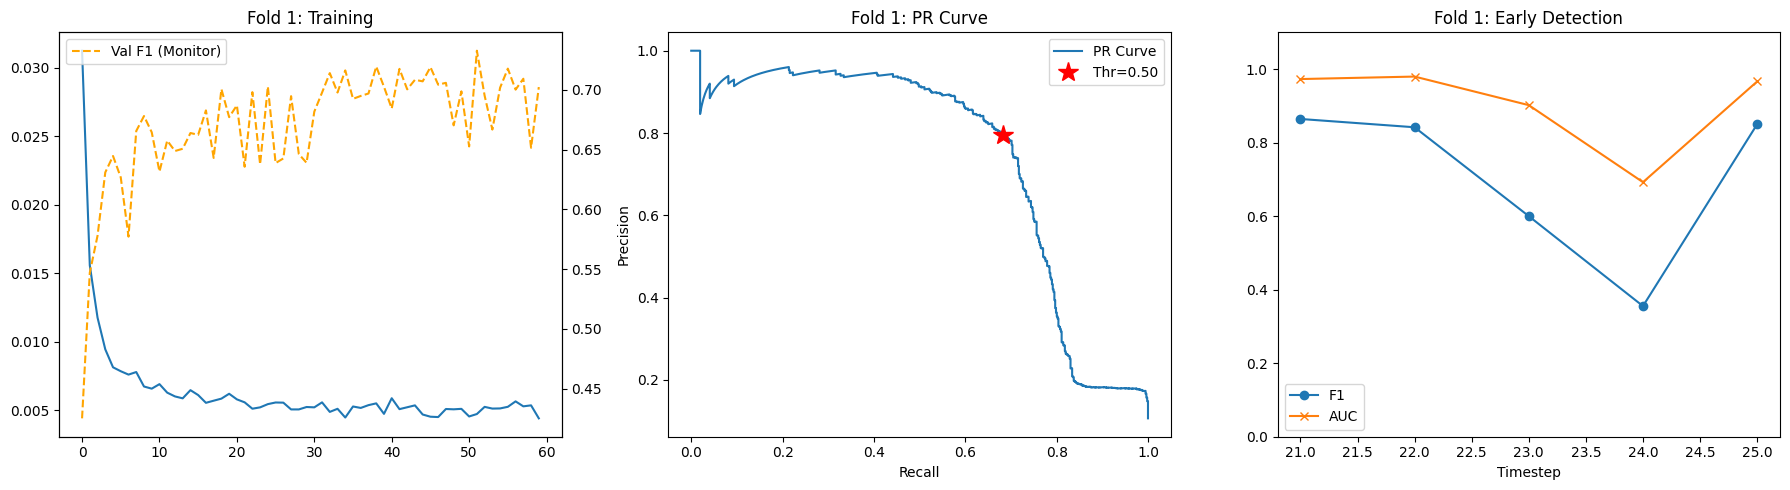


==================== RUNNING Fold 2 ====================
    Train: 1 -> 25
    Valid: 26 -> 30

[REPORT] Fold 2 (Threshold: 0.50)
              precision    recall  f1-score   support

       Licit       0.98      0.97      0.97      2088
     Illicit       0.91      0.92      0.91       617

    accuracy                           0.96      2705
   macro avg       0.94      0.94      0.94      2705
weighted avg       0.96      0.96      0.96      2705

ROC AUC: 0.9841


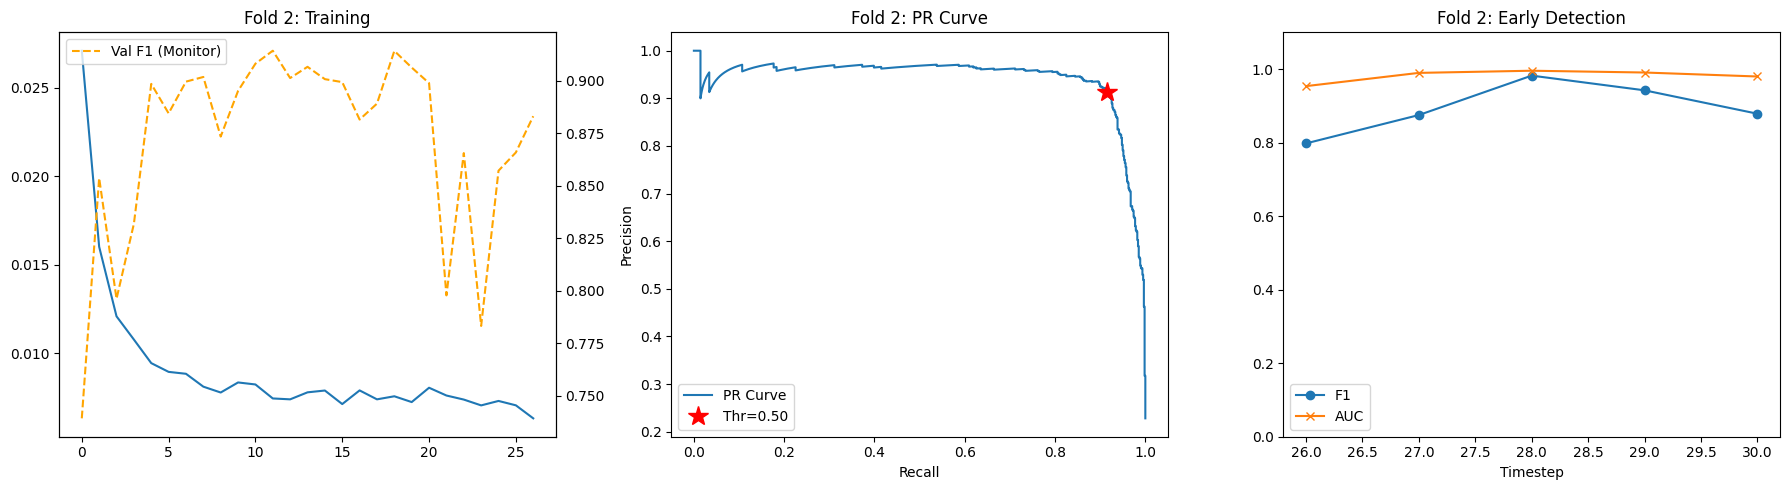


==================== RUNNING Fold 3 ====================
    Train: 1 -> 30
    Valid: 31 -> 35

[REPORT] Fold 3 (Threshold: 0.50)
              precision    recall  f1-score   support

       Licit       0.98      0.96      0.97      3640
     Illicit       0.81      0.88      0.84       690

    accuracy                           0.95      4330
   macro avg       0.89      0.92      0.91      4330
weighted avg       0.95      0.95      0.95      4330

ROC AUC: 0.9696


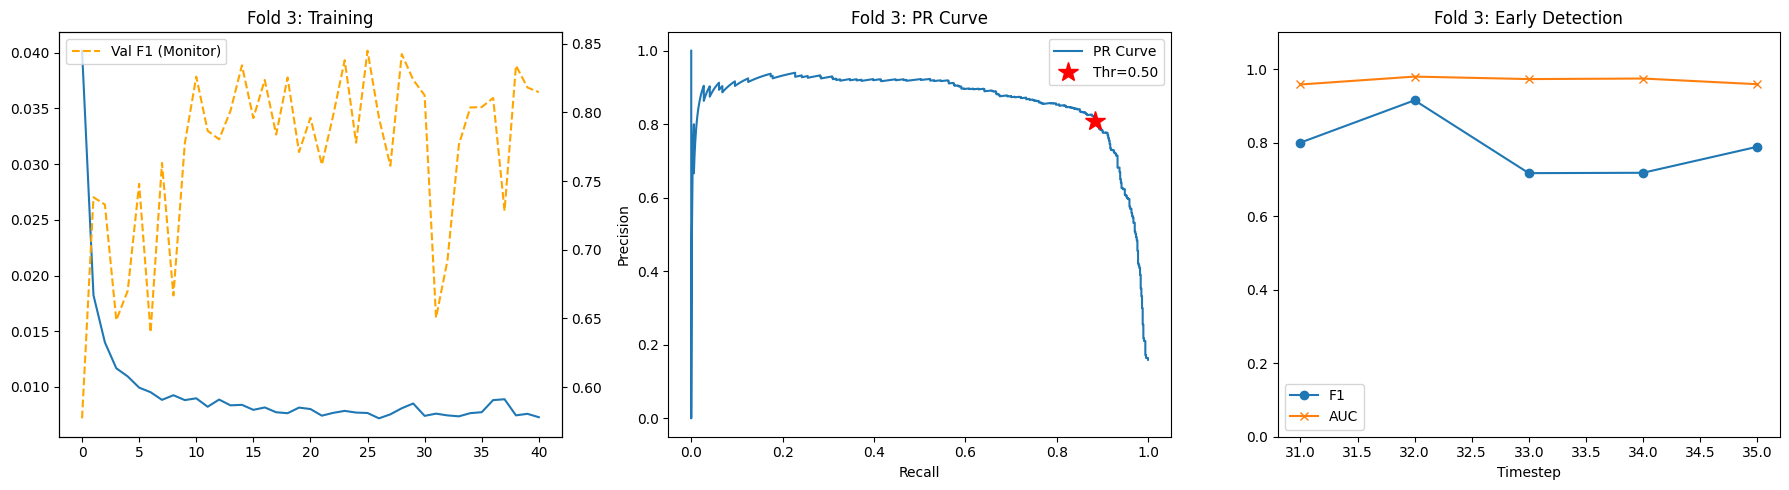


==================== RUNNING Fold 4 ====================
    Train: 1 -> 35
    Valid: 36 -> 41

[REPORT] Fold 4 (Threshold: 0.60)
              precision    recall  f1-score   support

       Licit       0.98      0.99      0.99      5995
     Illicit       0.91      0.71      0.79       493

    accuracy                           0.97      6488
   macro avg       0.94      0.85      0.89      6488
weighted avg       0.97      0.97      0.97      6488

ROC AUC: 0.9335


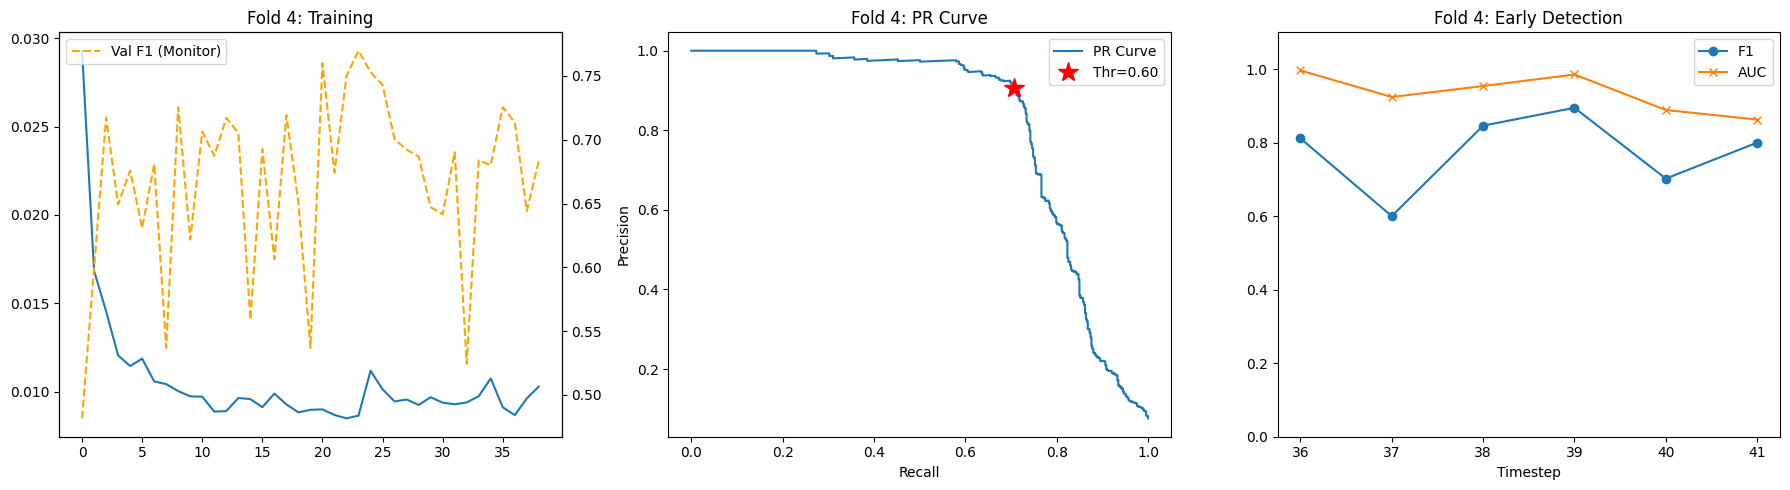


==================== RUNNING Fold 5 (Final) ====================
    [Strategy] Dropping data from TS 1-15 to handle Concept Drift
    Valid: 43 -> 49

[REPORT] Fold 5 (Final) (Threshold: 0.25)
              precision    recall  f1-score   support

       Licit       0.99      0.70      0.82      6518
     Illicit       0.06      0.71      0.11       169

    accuracy                           0.70      6687
   macro avg       0.52      0.70      0.46      6687
weighted avg       0.97      0.70      0.80      6687

ROC AUC: 0.7688


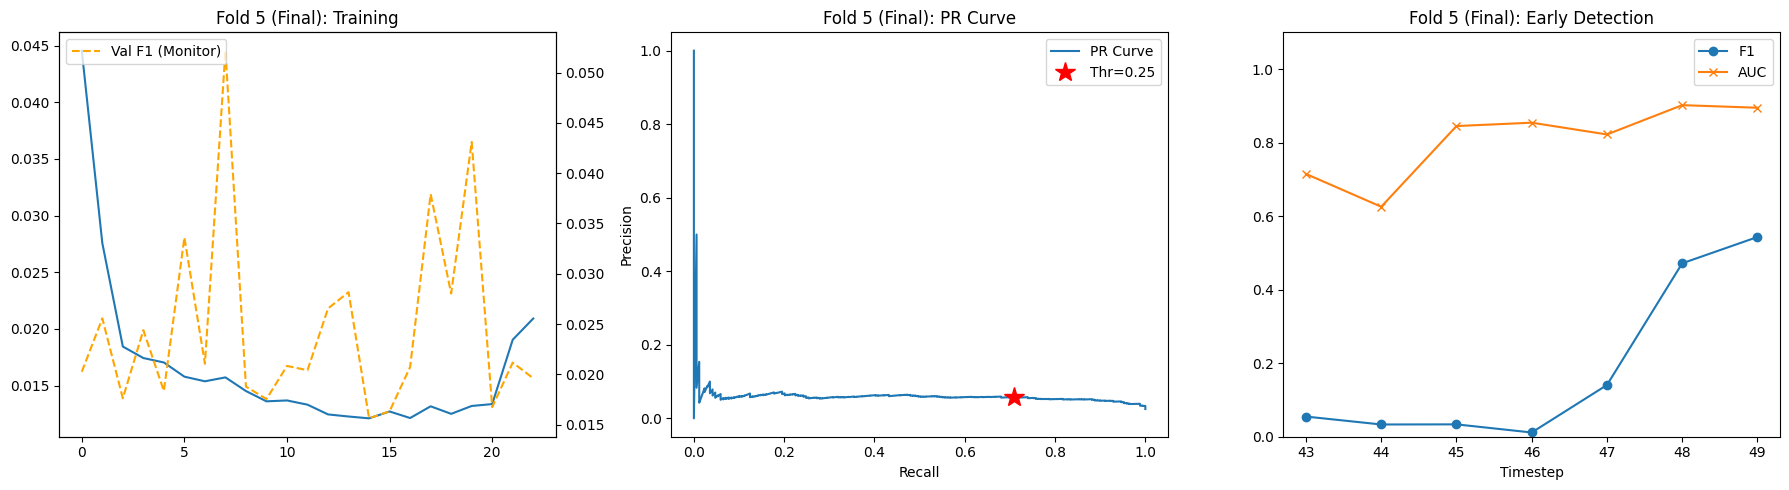



================ FINAL K-FOLD SUMMARY ================
             Fold       AUC        F1    Recall  Precision
0          Fold 1  0.898827  0.733840  0.681979   0.794239
1          Fold 2  0.984068  0.914239  0.915721   0.912763
2          Fold 3  0.969579  0.844875  0.884058   0.809019
3          Fold 4  0.933513  0.793615  0.705882   0.906250
4  Fold 5 (Final)  0.768799  0.106007  0.710059   0.057279
------------------------------------------------------------
Average AUC: 0.9110 (+/- 0.0861)
Average F1:  0.6785 (+/- 0.3268)

[SUCCESS] Final Model saved as 'robust_tgat_production.pth'


In [11]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_recall_curve, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import math
import random
import os
import shutil
import gc

# --- 0. REPRODUCIBILITY ---
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(80)

# --- 1. LOAD & PROCESS DATA (RAW) ---
print("Step 1: Loading & Processing Raw Data...")

# Cấu hình đường dẫn (Sửa lại nếu cần)
base_path = '/kaggle/input/elliptic/elliptic/' 

try:
    df_features = pd.read_csv(base_path + 'elliptic_txs_features.csv', header=None)
    df_classes = pd.read_csv(base_path + 'elliptic_txs_classes.csv')
    df_edgelist = pd.read_csv(base_path + 'elliptic_txs_edgelist.csv')
except FileNotFoundError:
    try: # Fallback local path
        df_features = pd.read_csv('elliptic_txs_features.csv', header=None)
        df_classes = pd.read_csv('elliptic_txs_classes.csv')
        df_edgelist = pd.read_csv('elliptic_txs_edgelist.csv')
    except:
        print("Error: CSV files not found.")
        exit()

# 1.1 Formatting Features
feature_cols = ['txId', 'timestep'] + [f'local_{i}' for i in range(93)] + [f'agg_{i}' for i in range(72)]
df_features.columns = feature_cols

# 1.2 Mapping IDs
all_tx_ids = df_features['txId'].unique()
tx_id_map = {tx_id: i for i, tx_id in enumerate(all_tx_ids)}

df_edgelist['txId1_idx'] = df_edgelist['txId1'].map(tx_id_map)
df_edgelist['txId2_idx'] = df_edgelist['txId2'].map(tx_id_map)

# 1.3 Merge Classes
df_merged = pd.merge(df_features, df_classes, on='txId', how='left')
df_merged['class'] = df_merged['class'].map({'2': 0, '1': 1, 'unknown': np.nan})
df_merged = df_merged.set_index('txId').loc[all_tx_ids].reset_index()

# 1.4 Extract Vectors
features_no_time = [col for col in df_features.columns if col not in ['txId', 'timestep']]
X_df = df_merged[features_no_time]
y_series = df_merged['class']
timesteps = df_merged['timestep'].values

# 1.5 Scaling (Fit on first 20 timesteps to avoid leakage)
print("   -> Scaling features...")
scaler = StandardScaler()
init_train_idx = X_df.index[timesteps <= 20].values
scaler.fit(X_df.loc[init_train_idx])
X_scaled = scaler.transform(X_df)

# 1.6 Create PyG Data Object
print("   -> Creating Graph Object...")
data = Data(
    x=torch.tensor(X_scaled, dtype=torch.float),
    edge_index=torch.tensor(df_edgelist[['txId1_idx', 'txId2_idx']].values.T, dtype=torch.long),
    y=torch.tensor(y_series.fillna(-1).values, dtype=torch.long), # NaN -> -1
    ts=torch.tensor(timesteps, dtype=torch.float) 
)

# Cleanup Raw Dataframes to save RAM
del df_features, df_classes, df_edgelist, df_merged, X_df, X_scaled
gc.collect()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Data Ready. Nodes: {data.num_nodes}. Device: {device}")

# --- 2. MODEL COMPONENTS ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.7, gamma=2.0): 
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        alphas = torch.where(targets == 1, self.alpha, 1.0 - self.alpha)
        return torch.mean(alphas * (1-pt)**self.gamma * ce_loss)

class TimeEncoder(nn.Module):
    def __init__(self, out_channels):
        super().__init__()
        self.w = nn.Linear(1, out_channels // 2) 
        self.p = nn.Linear(1, out_channels // 2)
    def forward(self, t):
        t = t.unsqueeze(-1)
        return torch.cat([torch.cos(self.w(t) + self.p(t)), torch.sin(self.w(t) + self.p(t))], dim=-1)

class TGATLayer(MessagePassing):
    def __init__(self, in_channels, out_channels, time_channels, heads=2, dropout=0.2):
        super().__init__(node_dim=0, aggr='add')
        self.heads = heads
        self.head_dim = out_channels // heads
        self.dropout = dropout
        self.lin_q = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_k = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_v = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_skip = nn.Linear(in_channels, out_channels)
    def forward(self, x, edge_index, t_emb):
        x_in = torch.cat([x, t_emb], dim=-1)
        q = self.lin_q(x_in).view(-1, self.heads, self.head_dim)
        k = self.lin_k(x_in).view(-1, self.heads, self.head_dim)
        v = self.lin_v(x_in).view(-1, self.heads, self.head_dim)
        out = self.propagate(edge_index, q=q, k=k, v=v, size=None)
        out = out.view(-1, self.heads * self.head_dim) + self.lin_skip(x)
        return out
    def message(self, q_i, k_j, v_j, index, ptr, size_i):
        alpha = (q_i * k_j).sum(dim=-1) / np.sqrt(self.head_dim)
        alpha = softmax(alpha, index, ptr, size_i)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        return v_j * alpha.unsqueeze(-1)

class RobustTGATModel(nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes, time_dim=32):
        super().__init__()
        self.time_enc = TimeEncoder(time_dim)
        self.conv1 = TGATLayer(num_features, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.conv2 = TGATLayer(hidden_dim, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.lin_out = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(p=0.3) 
    def forward(self, x, edge_index, t):
        t_emb = self.time_enc(t)
        x = F.relu(self.conv1(x, edge_index, t_emb))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index, t_emb))
        x = self.dropout(x)
        return self.lin_out(x)

# --- 3. TEMPORAL K-FOLD SETUP ---
folds = [
    {'name': 'Fold 1', 'train_end': 20, 'val_start': 21, 'val_end': 25},
    {'name': 'Fold 2', 'train_end': 25, 'val_start': 26, 'val_end': 30},
    {'name': 'Fold 3', 'train_end': 30, 'val_start': 31, 'val_end': 35},
    {'name': 'Fold 4', 'train_end': 35, 'val_start': 36, 'val_end': 41},
    {'name': 'Fold 5 (Final)', 'train_end': 42, 'val_start': 43, 'val_end': 49}
]

fold_metrics = []

print(f"\n--- STARTING TEMPORAL K-FOLD ({len(folds)} Folds) ---")

for fold in folds:
    print(f"\n{'='*20} RUNNING {fold['name']} {'='*20}")
    
    # --- FORGETTING MECHANISM ---
    start_train_ts = 1
    if fold['name'] == 'Fold 5 (Final)':
        start_train_ts = 15 # Bỏ dữ liệu quá khứ xa xưa
        print(f"    [Strategy] Dropping data from TS 1-{start_train_ts} to handle Concept Drift")
    else:
        print(f"    Train: 1 -> {fold['train_end']}")
    print(f"    Valid: {fold['val_start']} -> {fold['val_end']}")
    
    # 1. Setup Masks
    train_mask_idx = torch.where((data.ts >= start_train_ts) & (data.ts <= fold['train_end']) & (data.y != -1))[0]
    val_mask_idx = torch.where((data.ts >= fold['val_start']) & (data.ts <= fold['val_end']) & (data.y != -1))[0]
    
    train_loader = NeighborLoader(data, num_neighbors=[15, 10], batch_size=1024, input_nodes=train_mask_idx, shuffle=True)
    val_loader = NeighborLoader(data, num_neighbors=[15, 10], batch_size=2048, input_nodes=val_mask_idx)
    
    # 2. Reset Model
    model = RobustTGATModel(num_features=165, hidden_dim=128, num_classes=2, time_dim=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
    loss_fn = FocalLoss(alpha=0.7, gamma=2.0)
    
    # Lists for Plotting
    fold_train_losses = []
    fold_val_f1s = []
    
    # 3. Training Loop
    best_fold_f1 = 0
    patience = 15
    patience_cnt = 0
    model_name = f'best_model_{fold["name"].replace(" ", "_").replace("(", "").replace(")", "")}.pth'
    
    for epoch in range(60):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            noise = (torch.rand_like(batch.ts) - 0.5) * 0.1 
            t_noisy = batch.ts + noise
            out = model(batch.x, batch.edge_index, t_noisy)
            loss = loss_fn(out[:batch.batch_size], batch.y[:batch.batch_size])
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        avg_loss = total_loss / len(train_loader)
        fold_train_losses.append(avg_loss)

        # Validation
        model.eval()
        y_temp, p_temp = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.ts)
                prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1]
                y_temp.extend(batch.y[:batch.batch_size].cpu().numpy())
                p_temp.extend(prob.cpu().numpy())
        
        # Monitor F1 (Thr 0.5)
        curr_f1 = f1_score(y_temp, (np.array(p_temp) > 0.5).astype(int), pos_label=1, zero_division=0)
        fold_val_f1s.append(curr_f1)
        
        if curr_f1 > best_fold_f1:
            best_fold_f1 = curr_f1
            torch.save(model.state_dict(), model_name)
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                break
    
    # 4. Final Eval for this Fold
    model.load_state_dict(torch.load(model_name))
    model.eval()
    
    y_true, y_prob, y_ts = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.ts)
            prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1]
            y_true.extend(batch.y[:batch.batch_size].cpu().numpy())
            y_prob.extend(prob.cpu().numpy())
            y_ts.extend(batch.ts[:batch.batch_size].cpu().numpy())
            
    # Smart Threshold Search
    best_thr = 0.5
    best_f1_val = 0
    for thr in np.arange(0.2, 0.7, 0.05):
        p = (np.array(y_prob) > thr).astype(int)
        f = f1_score(y_true, p, pos_label=1, zero_division=0)
        if f > best_f1_val:
            best_f1_val = f
            best_thr = thr
            
    final_preds = (np.array(y_prob) > best_thr).astype(int)
    
    # REPORTING
    print(f"\n[REPORT] {fold['name']} (Threshold: {best_thr:.2f})")
    print(classification_report(y_true, final_preds, target_names=['Licit', 'Illicit']))
    auc = roc_auc_score(y_true, y_prob)
    print(f"ROC AUC: {auc:.4f}")
    
    rec = recall_score(y_true, final_preds, pos_label=1, zero_division=0)
    prec = precision_score(y_true, final_preds, pos_label=1, zero_division=0)
    fold_metrics.append({'Fold': fold['name'], 'AUC': auc, 'F1': best_f1_val, 'Recall': rec, 'Precision': prec})

    # PLOTTING
    unique_ts = sorted(np.unique(y_ts))
    f1_time, auc_time = [], []
    y_true, y_prob, y_ts, final_preds = np.array(y_true), np.array(y_prob), np.array(y_ts), np.array(final_preds)

    for t in unique_ts:
        mask = (y_ts == t)
        if np.sum(mask) > 0 and len(np.unique(y_true[mask])) > 1:
            f1_time.append(f1_score(y_true[mask], final_preds[mask], pos_label=1, zero_division=0))
            auc_time.append(roc_auc_score(y_true[mask], y_prob[mask]))
        else:
            f1_time.append(0.0)
            auc_time.append(0.5)

    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(fold_train_losses, label='Train Loss')
    ax2 = plt.gca().twinx()
    ax2.plot(fold_val_f1s, label='Val F1 (Monitor)', color='orange', linestyle='--')
    plt.title(f'{fold["name"]}: Training')
    plt.legend(loc='upper left')
    
    plt.subplot(1, 3, 2)
    prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_prob, pos_label=1)
    plt.plot(rec_curve, prec_curve, label='PR Curve')
    plt.plot(rec, prec, 'r*', markersize=15, label=f'Thr={best_thr:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{fold["name"]}: PR Curve')
    plt.legend()
    
    plt.subplot(1, 3, 3)
    plt.plot(unique_ts, f1_time, marker='o', label='F1')
    plt.plot(unique_ts, auc_time, marker='x', label='AUC')
    plt.title(f'{fold["name"]}: Early Detection')
    plt.xlabel('Timestep')
    plt.ylim(0, 1.1)
    plt.legend()
    
    plt.tight_layout()
    filename = f'report_{fold["name"].replace(" ", "_").replace("(", "").replace(")", "")}.png'
    plt.savefig(filename)
    plt.show()

# --- 5. SUMMARY ---
print("\n\n================ FINAL K-FOLD SUMMARY ================")
df_res = pd.DataFrame(fold_metrics)
print(df_res)
print("-" * 60)
print(f"Average AUC: {df_res['AUC'].mean():.4f} (+/- {df_res['AUC'].std():.4f})")
print(f"Average F1:  {df_res['F1'].mean():.4f} (+/- {df_res['F1'].std():.4f})")

# Save Final Model
if os.path.exists('best_model_Fold_5_Final.pth'):
    shutil.copy('best_model_Fold_5_Final.pth', 'robust_tgat_production.pth')
    print("\n[SUCCESS] Final Model saved as 'robust_tgat_production.pth'")

new version

Step 1: Loading & Processing Raw Data...
   -> Scaling features...
   -> Creating Graph Object...
Data Ready. Device: cuda

--- STARTING TEMPORAL K-FOLD (5 Folds) ---

==================== RUNNING Fold 1 ====================
    Train: 1 -> 20
    Valid: 21 -> 25

[REPORT] Fold 1 (Threshold: 0.50)
              precision    recall  f1-score   support

       Licit       0.97      0.98      0.97      4745
     Illicit       0.78      0.71      0.74       566

    accuracy                           0.95      5311
   macro avg       0.87      0.84      0.86      5311
weighted avg       0.95      0.95      0.95      5311

ROC AUC: 0.8956
Saved charts to: report_Fold_1.png


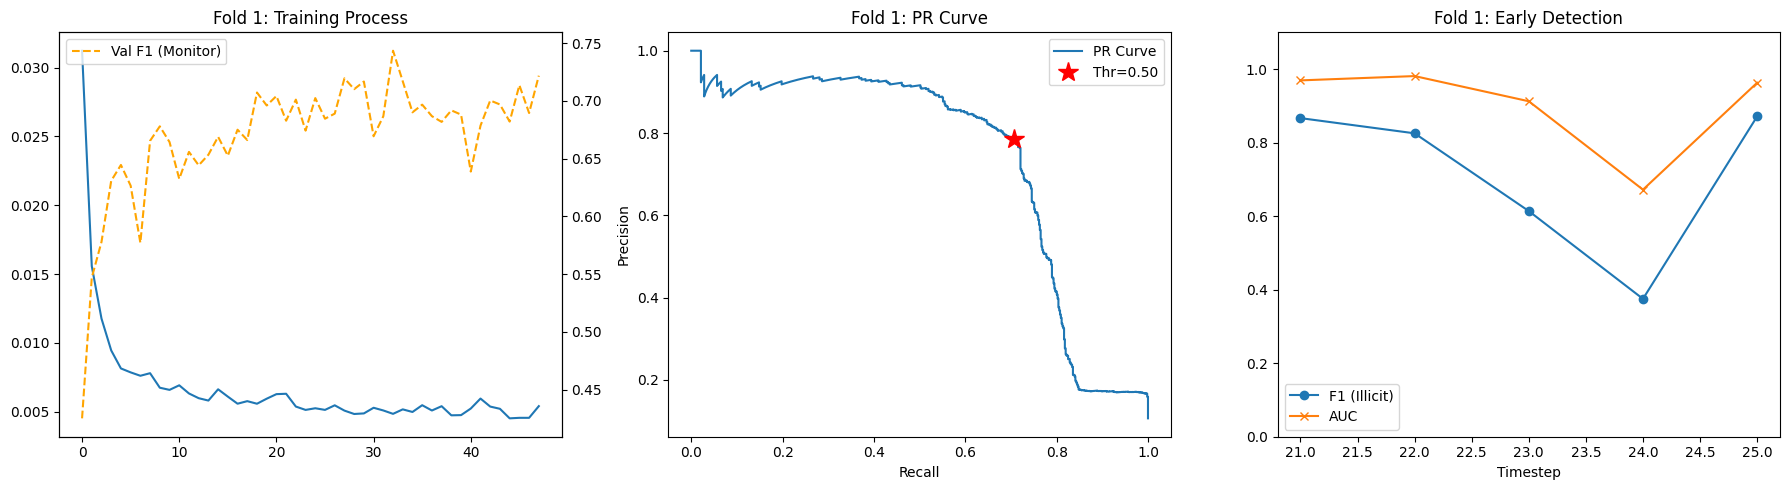


==================== RUNNING Fold 2 ====================
    Train: 1 -> 25
    Valid: 26 -> 30

[REPORT] Fold 2 (Threshold: 0.50)
              precision    recall  f1-score   support

       Licit       0.98      0.97      0.98      2088
     Illicit       0.91      0.93      0.92       617

    accuracy                           0.96      2705
   macro avg       0.94      0.95      0.95      2705
weighted avg       0.96      0.96      0.96      2705

ROC AUC: 0.9866
Saved charts to: report_Fold_2.png


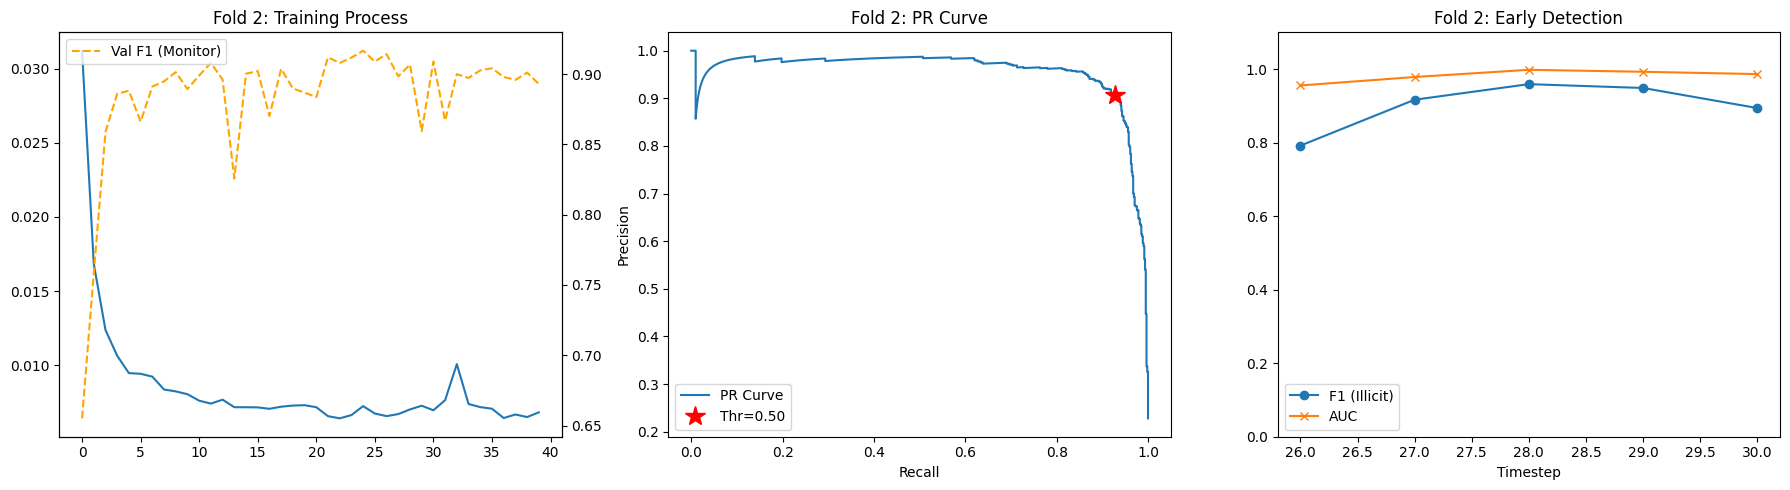


==================== RUNNING Fold 3 ====================
    Train: 1 -> 30
    Valid: 31 -> 35

[REPORT] Fold 3 (Threshold: 0.55)
              precision    recall  f1-score   support

       Licit       0.96      0.98      0.97      3640
     Illicit       0.86      0.81      0.84       690

    accuracy                           0.95      4330
   macro avg       0.91      0.89      0.90      4330
weighted avg       0.95      0.95      0.95      4330

ROC AUC: 0.9670
Saved charts to: report_Fold_3.png


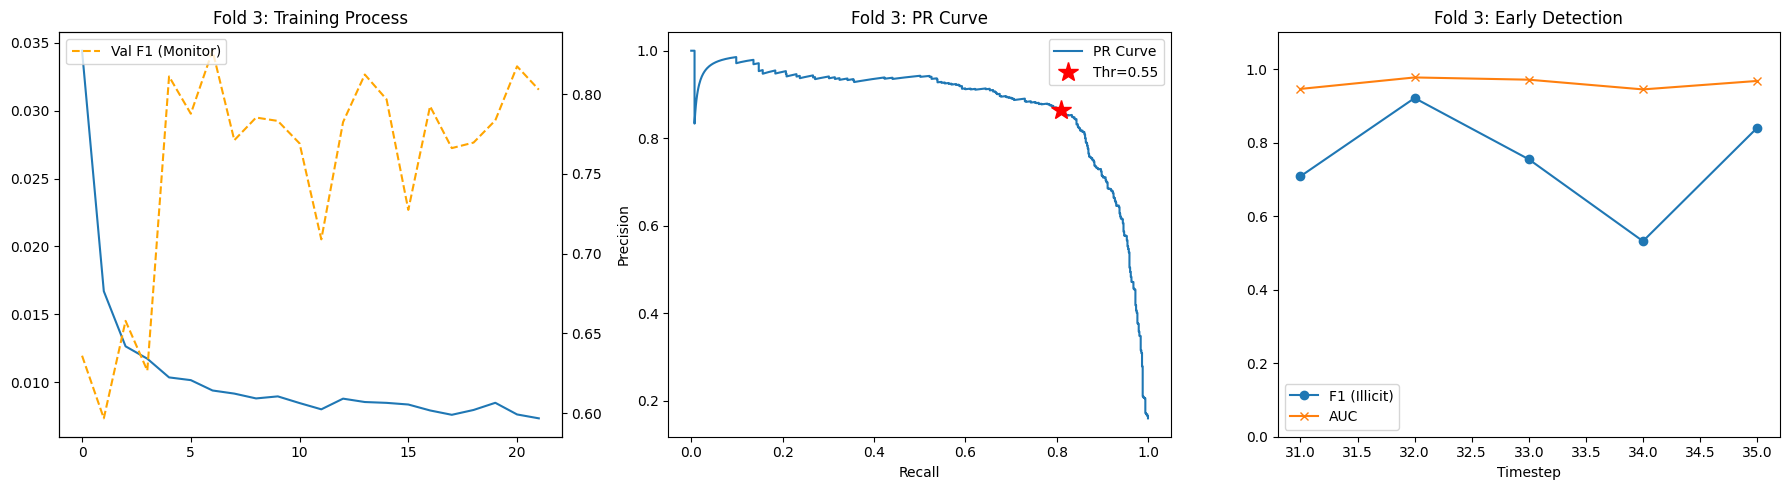


==================== RUNNING Fold 4 ====================
    Train: 1 -> 35
    Valid: 36 -> 41

[REPORT] Fold 4 (Threshold: 0.50)
              precision    recall  f1-score   support

       Licit       0.98      0.99      0.98      5995
     Illicit       0.88      0.70      0.78       493

    accuracy                           0.97      6488
   macro avg       0.93      0.84      0.88      6488
weighted avg       0.97      0.97      0.97      6488

ROC AUC: 0.9331
Saved charts to: report_Fold_4.png


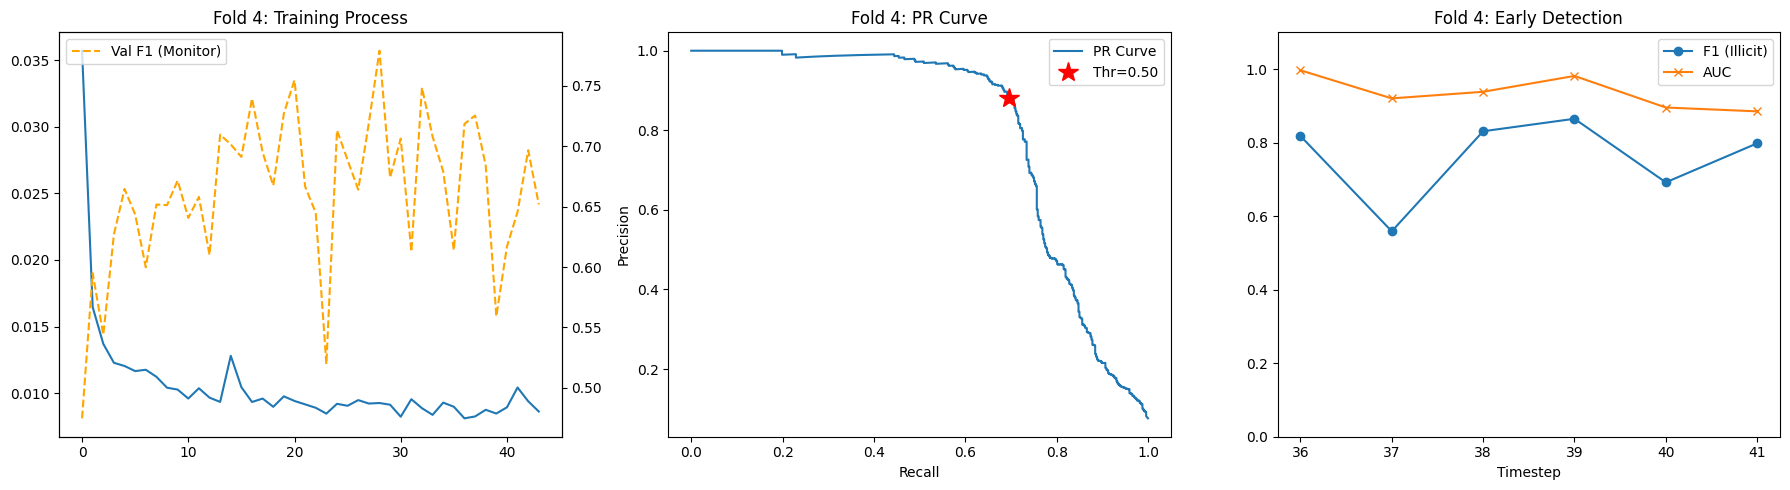


==================== RUNNING Fold 5 (Final) ====================
    [Strategy] Dropping data from TS 1-15
    Valid: 43 -> 49

[REPORT] Fold 5 (Final) (Threshold: 0.30)
              precision    recall  f1-score   support

       Licit       0.99      0.85      0.91      6518
     Illicit       0.09      0.55      0.15       169

    accuracy                           0.84      6687
   macro avg       0.54      0.70      0.53      6687
weighted avg       0.96      0.84      0.89      6687

ROC AUC: 0.8273
Saved charts to: report_Fold_5_Final.png


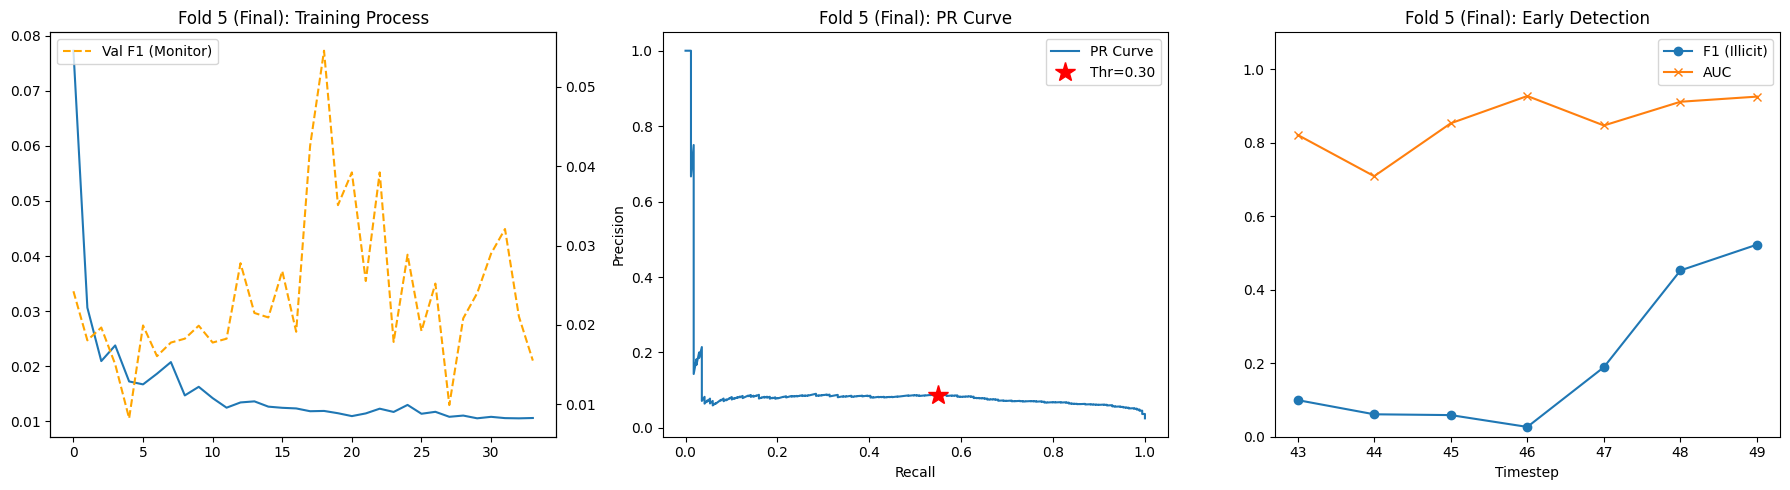



================ FINAL K-FOLD SUMMARY ================
             Fold       AUC        F1    Recall  Precision
0          Fold 1  0.895629  0.743494  0.706714   0.784314
1          Fold 2  0.986632  0.916667  0.927066   0.906498
2          Fold 3  0.967015  0.836200  0.810145   0.863988
3          Fold 4  0.933101  0.777778  0.695740   0.881748
4  Fold 5 (Final)  0.827257  0.150000  0.550296   0.086835
------------------------------------------------------------
Average AUC: 0.9219 (+/- 0.0632)
Average F1:  0.6848 (+/- 0.3061)

[SUCCESS] Saved Final Production Model as 'robust_tgat_production.pth'


In [12]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_recall_curve, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import math
import random
import os
import shutil
import gc

# --- 0. REPRODUCIBILITY (Khóa Random Seed) ---
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(80)

# --- 1. LOAD & PROCESS DATA ---
print("Step 1: Loading & Processing Raw Data...")
base_path = '/kaggle/input/elliptic/elliptic/' 

try:
    df_features = pd.read_csv(base_path + 'elliptic_txs_features.csv', header=None)
    df_classes = pd.read_csv(base_path + 'elliptic_txs_classes.csv')
    df_edgelist = pd.read_csv(base_path + 'elliptic_txs_edgelist.csv')
except FileNotFoundError:
    try: 
        df_features = pd.read_csv('elliptic_txs_features.csv', header=None)
        df_classes = pd.read_csv('elliptic_txs_classes.csv')
        df_edgelist = pd.read_csv('elliptic_txs_edgelist.csv')
    except:
        print("Error: CSV files not found.")
        exit()

# Formatting
feature_cols = ['txId', 'timestep'] + [f'local_{i}' for i in range(93)] + [f'agg_{i}' for i in range(72)]
df_features.columns = feature_cols
all_tx_ids = df_features['txId'].unique()
tx_id_map = {tx_id: i for i, tx_id in enumerate(all_tx_ids)}

df_edgelist['txId1_idx'] = df_edgelist['txId1'].map(tx_id_map)
df_edgelist['txId2_idx'] = df_edgelist['txId2'].map(tx_id_map)

df_merged = pd.merge(df_features, df_classes, on='txId', how='left')
df_merged['class'] = df_merged['class'].map({'2': 0, '1': 1, 'unknown': np.nan})
df_merged = df_merged.set_index('txId').loc[all_tx_ids].reset_index()

features_no_time = [col for col in df_features.columns if col not in ['txId', 'timestep']]
X_df = df_merged[features_no_time]
y_series = df_merged['class']
timesteps = df_merged['timestep'].values

print("   -> Scaling features...")
scaler = StandardScaler()
# Fit scaler trên 20 timestep đầu để tránh lộ data tương lai
init_train_idx = X_df.index[timesteps <= 20].values
scaler.fit(X_df.loc[init_train_idx])
X_scaled = scaler.transform(X_df)

print("   -> Creating Graph Object...")
data = Data(
    x=torch.tensor(X_scaled, dtype=torch.float),
    edge_index=torch.tensor(df_edgelist[['txId1_idx', 'txId2_idx']].values.T, dtype=torch.long),
    y=torch.tensor(y_series.fillna(-1).values, dtype=torch.long),
    ts=torch.tensor(timesteps, dtype=torch.float) 
)

del df_features, df_classes, df_edgelist, df_merged, X_df, X_scaled
gc.collect()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Data Ready. Device: {device}")

# --- 2. MODEL COMPONENTS ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.7, gamma=2.0): 
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        alphas = torch.where(targets == 1, self.alpha, 1.0 - self.alpha)
        return torch.mean(alphas * (1-pt)**self.gamma * ce_loss)

class TimeEncoder(nn.Module):
    def __init__(self, out_channels):
        super().__init__()
        self.w = nn.Linear(1, out_channels // 2) 
        self.p = nn.Linear(1, out_channels // 2)
    def forward(self, t):
        t = t.unsqueeze(-1)
        return torch.cat([torch.cos(self.w(t) + self.p(t)), torch.sin(self.w(t) + self.p(t))], dim=-1)

class TGATLayer(MessagePassing):
    def __init__(self, in_channels, out_channels, time_channels, heads=2, dropout=0.2):
        super().__init__(node_dim=0, aggr='add')
        self.heads = heads
        self.head_dim = out_channels // heads
        self.dropout = dropout
        self.lin_q = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_k = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_v = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_skip = nn.Linear(in_channels, out_channels)
    def forward(self, x, edge_index, t_emb):
        x_in = torch.cat([x, t_emb], dim=-1)
        q = self.lin_q(x_in).view(-1, self.heads, self.head_dim)
        k = self.lin_k(x_in).view(-1, self.heads, self.head_dim)
        v = self.lin_v(x_in).view(-1, self.heads, self.head_dim)
        out = self.propagate(edge_index, q=q, k=k, v=v, size=None)
        out = out.view(-1, self.heads * self.head_dim) + self.lin_skip(x)
        return out
    def message(self, q_i, k_j, v_j, index, ptr, size_i):
        alpha = (q_i * k_j).sum(dim=-1) / np.sqrt(self.head_dim)
        alpha = softmax(alpha, index, ptr, size_i)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        return v_j * alpha.unsqueeze(-1)

class RobustTGATModel(nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes, time_dim=32):
        super().__init__()
        self.time_enc = TimeEncoder(time_dim)
        self.conv1 = TGATLayer(num_features, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.conv2 = TGATLayer(hidden_dim, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.lin_out = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(p=0.3) 
    def forward(self, x, edge_index, t):
        t_emb = self.time_enc(t)
        x = F.relu(self.conv1(x, edge_index, t_emb))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index, t_emb))
        x = self.dropout(x)
        return self.lin_out(x)

# --- 3. TEMPORAL K-FOLD LOOP ---
folds = [
    {'name': 'Fold 1', 'train_end': 20, 'val_start': 21, 'val_end': 25},
    {'name': 'Fold 2', 'train_end': 25, 'val_start': 26, 'val_end': 30},
    {'name': 'Fold 3', 'train_end': 30, 'val_start': 31, 'val_end': 35},
    {'name': 'Fold 4', 'train_end': 35, 'val_start': 36, 'val_end': 41},
    {'name': 'Fold 5 (Final)', 'train_end': 42, 'val_start': 43, 'val_end': 49}
]

fold_metrics = []
print(f"\n--- STARTING TEMPORAL K-FOLD ({len(folds)} Folds) ---")

for fold in folds:
    print(f"\n{'='*20} RUNNING {fold['name']} {'='*20}")
    
    # --- Forgetting Mechanism ---
    start_train_ts = 1
    if fold['name'] == 'Fold 5 (Final)':
        start_train_ts = 15 
        print(f"    [Strategy] Dropping data from TS 1-{start_train_ts}")
    else:
        print(f"    Train: 1 -> {fold['train_end']}")
    print(f"    Valid: {fold['val_start']} -> {fold['val_end']}")
    
    # 1. Setup Masks
    train_mask_idx = torch.where((data.ts >= start_train_ts) & (data.ts <= fold['train_end']) & (data.y != -1))[0]
    val_mask_idx = torch.where((data.ts >= fold['val_start']) & (data.ts <= fold['val_end']) & (data.y != -1))[0]
    
    train_loader = NeighborLoader(data, num_neighbors=[15, 10], batch_size=1024, input_nodes=train_mask_idx, shuffle=True)
    val_loader = NeighborLoader(data, num_neighbors=[15, 10], batch_size=2048, input_nodes=val_mask_idx)
    
    # 2. Reset Model
    model = RobustTGATModel(num_features=165, hidden_dim=128, num_classes=2, time_dim=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
    loss_fn = FocalLoss(alpha=0.7, gamma=2.0)
    
    # Lists for Plotting
    fold_train_losses = []
    fold_val_f1s = []
    
    # 3. Training Loop
    best_fold_f1 = 0
    patience = 15
    patience_cnt = 0
    model_name = f'best_model_{fold["name"].replace(" ", "_").replace("(", "").replace(")", "")}.pth'
    
    for epoch in range(60):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            noise = (torch.rand_like(batch.ts) - 0.5) * 0.1 
            t_noisy = batch.ts + noise
            out = model(batch.x, batch.edge_index, t_noisy)
            loss = loss_fn(out[:batch.batch_size], batch.y[:batch.batch_size])
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        avg_loss = total_loss / len(train_loader)
        fold_train_losses.append(avg_loss)

        # Validation Monitor
        model.eval()
        y_temp, p_temp = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.ts)
                prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1]
                y_temp.extend(batch.y[:batch.batch_size].cpu().numpy())
                p_temp.extend(prob.cpu().numpy())
        
        # Quick Monitor F1
        curr_f1 = f1_score(y_temp, (np.array(p_temp) > 0.5).astype(int), pos_label=1, zero_division=0)
        fold_val_f1s.append(curr_f1)
        
        if curr_f1 > best_fold_f1:
            best_fold_f1 = curr_f1
            torch.save(model.state_dict(), model_name)
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                break
    
    # 4. Final Eval for this Fold
    model.load_state_dict(torch.load(model_name))
    model.eval()
    
    y_true_final, y_prob_final, y_ts_final = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.ts)
            prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1]
            y_true_final.extend(batch.y[:batch.batch_size].cpu().numpy())
            y_prob_final.extend(prob.cpu().numpy())
            y_ts_final.extend(batch.ts[:batch.batch_size].cpu().numpy())
            
    # Smart Threshold
    best_thr = 0.5
    best_f1_val = 0
    for thr in np.arange(0.2, 0.7, 0.05):
        p = (np.array(y_prob_final) > thr).astype(int)
        f = f1_score(y_true_final, p, pos_label=1, zero_division=0)
        if f > best_f1_val:
            best_f1_val = f
            best_thr = thr
            
    final_preds = (np.array(y_prob_final) > best_thr).astype(int)
    
    # --- [QUANT TRỌNG] REPORTING ĐÚNG YÊU CẦU ---
    print(f"\n[REPORT] {fold['name']} (Threshold: {best_thr:.2f})")
    
    # 1. Bảng chi tiết từng nhãn (Licit/Illicit)
    # Đây là phần in ra bảng Precision/Recall/F1 cho từng lớp
    print(classification_report(y_true_final, final_preds, target_names=['Licit', 'Illicit'], digits=2))
    
    # 2. Các chỉ số tổng hợp khác
    auc = roc_auc_score(y_true_final, y_prob_final)
    print(f"ROC AUC: {auc:.4f}")
    # print(f"Confusion Matrix:\n{confusion_matrix(y_true_final, final_preds)}")
    
    rec = recall_score(y_true_final, final_preds, pos_label=1, zero_division=0)
    prec = precision_score(y_true_final, final_preds, pos_label=1, zero_division=0)
    fold_metrics.append({'Fold': fold['name'], 'AUC': auc, 'F1': best_f1_val, 'Recall': rec, 'Precision': prec})

    # --- [QUAN TRỌNG] PLOTTING ---
    unique_ts = sorted(np.unique(y_ts_final))
    f1_time, auc_time = [], []
    y_true_final, y_prob_final, y_ts_final = np.array(y_true_final), np.array(y_prob_final), np.array(y_ts_final)
    final_preds = np.array(final_preds)

    for t in unique_ts:
        mask = (y_ts_final == t)
        if np.sum(mask) > 0 and len(np.unique(y_true_final[mask])) > 1:
            f1_time.append(f1_score(y_true_final[mask], final_preds[mask], pos_label=1, zero_division=0))
            auc_time.append(roc_auc_score(y_true_final[mask], y_prob_final[mask]))
        else:
            f1_time.append(0.0)
            auc_time.append(0.5)

    plt.figure(figsize=(18, 5))
    
    # Chart 1: Training Loss & Val Monitor
    plt.subplot(1, 3, 1)
    plt.plot(fold_train_losses, label='Train Loss')
    ax2 = plt.gca().twinx()
    ax2.plot(fold_val_f1s, label='Val F1 (Monitor)', color='orange', linestyle='--')
    plt.title(f'{fold["name"]}: Training Process')
    plt.legend(loc='upper left')
    
    # Chart 2: PR Curve
    plt.subplot(1, 3, 2)
    prec_curve, rec_curve, _ = precision_recall_curve(y_true_final, y_prob_final, pos_label=1)
    plt.plot(rec_curve, prec_curve, label='PR Curve')
    plt.plot(rec, prec, 'r*', markersize=15, label=f'Thr={best_thr:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{fold["name"]}: PR Curve')
    plt.legend()
    
    # Chart 3: Early Detection (F1/AUC over Time)
    plt.subplot(1, 3, 3)
    plt.plot(unique_ts, f1_time, marker='o', label='F1 (Illicit)')
    plt.plot(unique_ts, auc_time, marker='x', label='AUC')
    plt.title(f'{fold["name"]}: Early Detection')
    plt.xlabel('Timestep')
    plt.ylim(0, 1.1)
    plt.legend()
    
    plt.tight_layout()
    filename = f'report_{fold["name"].replace(" ", "_").replace("(", "").replace(")", "")}.png'
    plt.savefig(filename)
    print(f"Saved charts to: {filename}")
    plt.show()

# --- 5. FINAL SUMMARY ---
print("\n\n================ FINAL K-FOLD SUMMARY ================")
df_res = pd.DataFrame(fold_metrics)
print(df_res)
print("-" * 60)
print(f"Average AUC: {df_res['AUC'].mean():.4f} (+/- {df_res['AUC'].std():.4f})")
print(f"Average F1:  {df_res['F1'].mean():.4f} (+/- {df_res['F1'].std():.4f})")

final_model_name = 'best_model_Fold_5_Final.pth'
if os.path.exists(final_model_name):
    shutil.copy(final_model_name, 'robust_tgat_production.pth')
    print("\n[SUCCESS] Saved Final Production Model as 'robust_tgat_production.pth'")

new

Running Ensemble on: cuda

[Step 1] Loading Test Data...
   -> Creating Tensors...
   -> Test Set Size: 8841 nodes

[Step 2] Running Ensemble Inference...
   -> Found 5 models: ['best_model_Fold_1.pth', 'best_model_Fold_2.pth', 'best_model_Fold_3.pth', 'best_model_Fold_4.pth', 'best_model_Fold_5_Final.pth']
   -> Predicting with best_model_Fold_1.pth...
   -> Predicting with best_model_Fold_2.pth...
   -> Predicting with best_model_Fold_3.pth...
   -> Predicting with best_model_Fold_4.pth...
   -> Predicting with best_model_Fold_5_Final.pth...
   -> Ensemble aggregation complete.

[Step 3] Optimizing Threshold for Ensemble Result...
Threshold  | F1-Score   | Recall     | Precision 
--------------------------------------------------
0.15       | 0.1357     | 0.9730     | 0.0729
0.20       | 0.1513     | 0.9289     | 0.0823
0.25       | 0.1686     | 0.8701     | 0.0933
0.30       | 0.1860     | 0.7672     | 0.1059
0.35       | 0.2118     | 0.6716     | 0.1257
0.40       | 0.2483     | 0.

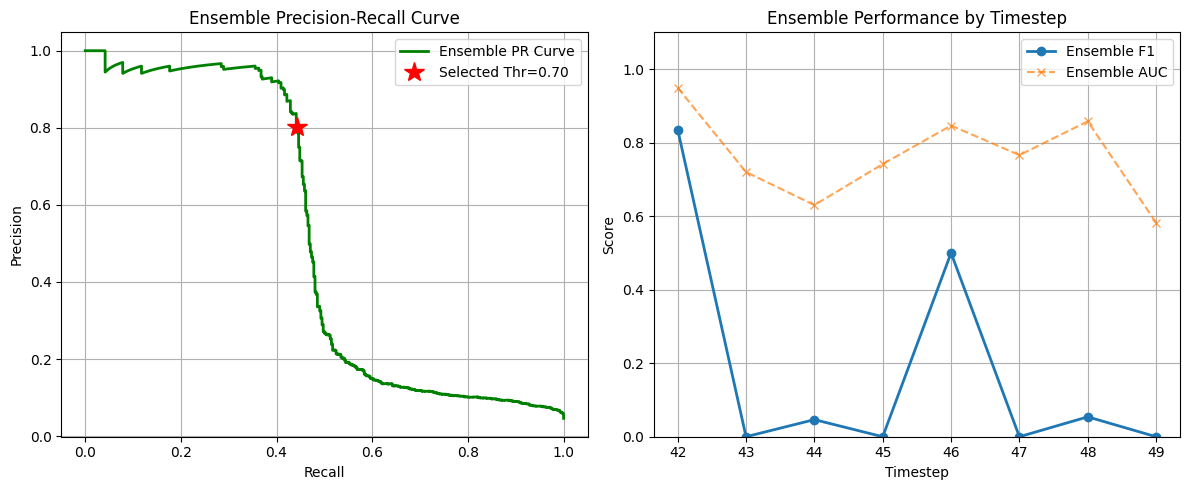

In [13]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_recall_curve, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import math
import random
import os
import glob
import gc

# --- 0. CẤU HÌNH & REPRODUCIBILITY ---
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(80)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running Ensemble on: {device}")

# --- 1. LOAD PROCESSED DATA (TEST SET ONLY) ---
print("\n[Step 1] Loading Test Data...")

try:
    dtype_dict = {'node_idx': 'int32', 'timestep': 'int32', 'class_label': 'float32'}
    for i in range(165): dtype_dict[f'feat_{i}'] = 'float32'
    
    df_nodes = pd.read_csv('processed_nodes.csv', dtype=dtype_dict)
    df_edges = pd.read_csv('processed_edges.csv', dtype={'source_idx': 'int32', 'target_idx': 'int32'})
except FileNotFoundError:
    print("Lỗi: Không tìm thấy file processed_*.csv. Vui lòng chạy Preprocessing trước.")
    exit()

print("   -> Creating Tensors...")
feature_cols = [c for c in df_nodes.columns if c.startswith('feat_')]
x = torch.tensor(df_nodes[feature_cols].values, dtype=torch.float)
y = torch.tensor(df_nodes['class_label'].fillna(-1).values, dtype=torch.long)
edge_index = torch.tensor(df_edges[['source_idx', 'target_idx']].values.T, dtype=torch.long)
ts = torch.tensor(df_nodes['timestep'].values, dtype=torch.float)

# Tạo Data Object
data = Data(x=x, edge_index=edge_index, y=y, ts=ts)

# Xác định Test Mask (Timestep 42-49)
test_mask_idx = torch.where((data.ts >= 42) & (data.y != -1))[0]
print(f"   -> Test Set Size: {len(test_mask_idx)} nodes")

# Tạo Loader cho Test (Batch lớn để chạy nhanh)
test_loader = NeighborLoader(data, num_neighbors=[15, 10], batch_size=4096, input_nodes=test_mask_idx, shuffle=False)

# Dọn dẹp RAM
del df_nodes, df_edges, x, y, edge_index, ts
gc.collect()

# --- 2. MODEL CLASSES (Phải giống hệt lúc Train) ---
class TimeEncoder(nn.Module):
    def __init__(self, out_channels):
        super().__init__()
        self.w = nn.Linear(1, out_channels // 2) 
        self.p = nn.Linear(1, out_channels // 2)
    def forward(self, t):
        t = t.unsqueeze(-1)
        return torch.cat([torch.cos(self.w(t) + self.p(t)), torch.sin(self.w(t) + self.p(t))], dim=-1)

class TGATLayer(MessagePassing):
    def __init__(self, in_channels, out_channels, time_channels, heads=2, dropout=0.2):
        super().__init__(node_dim=0, aggr='add')
        self.heads = heads
        self.head_dim = out_channels // heads
        self.dropout = dropout
        self.lin_q = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_k = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_v = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_skip = nn.Linear(in_channels, out_channels)
    def forward(self, x, edge_index, t_emb):
        x_in = torch.cat([x, t_emb], dim=-1)
        q = self.lin_q(x_in).view(-1, self.heads, self.head_dim)
        k = self.lin_k(x_in).view(-1, self.heads, self.head_dim)
        v = self.lin_v(x_in).view(-1, self.heads, self.head_dim)
        out = self.propagate(edge_index, q=q, k=k, v=v, size=None)
        out = out.view(-1, self.heads * self.head_dim) + self.lin_skip(x)
        return out
    def message(self, q_i, k_j, v_j, index, ptr, size_i):
        alpha = (q_i * k_j).sum(dim=-1) / np.sqrt(self.head_dim)
        alpha = softmax(alpha, index, ptr, size_i)
        return v_j * alpha.unsqueeze(-1)

class RobustTGATModel(nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes, time_dim=32):
        super().__init__()
        self.time_enc = TimeEncoder(time_dim)
        self.conv1 = TGATLayer(num_features, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.conv2 = TGATLayer(hidden_dim, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.lin_out = nn.Linear(hidden_dim, num_classes)
    def forward(self, x, edge_index, t):
        t_emb = self.time_enc(t)
        x = F.relu(self.conv1(x, edge_index, t_emb))
        x = F.relu(self.conv2(x, edge_index, t_emb))
        return self.lin_out(x)

# --- 3. ENSEMBLE PREDICTION LOOP ---
print("\n[Step 2] Running Ensemble Inference...")

# Tìm các file model
model_files = sorted(glob.glob("best_model_Fold_*.pth"))
if not model_files:
    print("Lỗi: Không tìm thấy file model (.pth). Hãy chạy Training K-Fold trước.")
    exit()

print(f"   -> Found {len(model_files)} models: {[os.path.basename(f) for f in model_files]}")

# Biến lưu trữ kết quả gộp
ensemble_probs = None
y_true_test = None
y_ts_test = None

for m_file in model_files:
    print(f"   -> Predicting with {os.path.basename(m_file)}...")
    
    # 1. Load Model
    model = RobustTGATModel(num_features=165, hidden_dim=128, num_classes=2, time_dim=64).to(device)
    model.load_state_dict(torch.load(m_file, map_location=device))
    model.eval()
    
    # 2. Run Inference
    fold_probs = []
    fold_y = []
    fold_ts = []
    
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.ts)
            prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1] # Xác suất lớp 1 (Illicit)
            
            fold_probs.extend(prob.cpu().numpy())
            
            # Lưu Ground Truth 1 lần (ở model đầu tiên)
            if ensemble_probs is None:
                fold_y.extend(batch.y[:batch.batch_size].cpu().numpy())
                fold_ts.extend(batch.ts[:batch.batch_size].cpu().numpy())
    
    # 3. Cộng dồn xác suất
    probs_np = np.array(fold_probs)
    if ensemble_probs is None:
        ensemble_probs = probs_np
        y_true_test = np.array(fold_y)
        y_ts_test = np.array(fold_ts)
    else:
        ensemble_probs += probs_np

# 4. Chia trung bình (Average Voting)
ensemble_probs /= len(model_files)
print("   -> Ensemble aggregation complete.")

# --- 4. THRESHOLD OPTIMIZATION (On Test Set for Analysis) ---
print("\n[Step 3] Optimizing Threshold for Ensemble Result...")
print(f"{'Threshold':<10} | {'F1-Score':<10} | {'Recall':<10} | {'Precision':<10}")
print("-" * 50)

best_thr = 0.5
best_f1 = 0

for thr in np.arange(0.15, 0.75, 0.05):
    pred_tmp = (ensemble_probs > thr).astype(int)
    f1_tmp = f1_score(y_true_test, pred_tmp, pos_label=1, zero_division=0)
    rec_tmp = recall_score(y_true_test, pred_tmp, pos_label=1, zero_division=0)
    prec_tmp = precision_score(y_true_test, pred_tmp, pos_label=1, zero_division=0)
    
    print(f"{thr:.2f}       | {f1_tmp:.4f}     | {rec_tmp:.4f}     | {prec_tmp:.4f}")
    
    if f1_tmp > best_f1:
        best_f1 = f1_tmp
        best_thr = thr

print("-" * 50)
print(f"Best Ensemble Threshold: {best_thr:.2f}")

# --- 5. FINAL REPORTING ---
print(f"\n[Step 4] ENSEMBLE FINAL REPORT (Thr={best_thr:.2f})")
final_preds = (ensemble_probs > best_thr).astype(int)

# 1. Classification Report
print(classification_report(y_true_test, final_preds, target_names=['Licit', 'Illicit']))

# 2. AUC
auc = roc_auc_score(y_true_test, ensemble_probs)
print(f"Ensemble ROC AUC: {auc:.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_true_test, final_preds)}")

# --- 6. VISUALIZATION ---
print("\n[Step 5] Generating Ensemble Plots...")
unique_ts = sorted(np.unique(y_ts_test))
f1_time, auc_time = [], []

for t in unique_ts:
    mask = (y_ts_test == t)
    if np.sum(mask) > 0 and len(np.unique(y_true_test[mask])) > 1:
        f1_time.append(f1_score(y_true_test[mask], final_preds[mask], pos_label=1, zero_division=0))
        auc_time.append(roc_auc_score(y_true_test[mask], ensemble_probs[mask]))
    else:
        f1_time.append(0.0)
        auc_time.append(0.5)

plt.figure(figsize=(12, 5))

# Chart 1: PR Curve
plt.subplot(1, 2, 1)
prec_curve, rec_curve, _ = precision_recall_curve(y_true_test, ensemble_probs, pos_label=1)
plt.plot(rec_curve, prec_curve, label='Ensemble PR Curve', color='green', linewidth=2)
plt.plot(recall_score(y_true_test, final_preds, pos_label=1), 
         precision_score(y_true_test, final_preds, pos_label=1), 
         'r*', markersize=15, label=f'Selected Thr={best_thr:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Ensemble Precision-Recall Curve')
plt.grid(True)
plt.legend()

# Chart 2: Early Detection
plt.subplot(1, 2, 2)
plt.plot(unique_ts, f1_time, marker='o', label='Ensemble F1', linewidth=2)
plt.plot(unique_ts, auc_time, marker='x', label='Ensemble AUC', linestyle='--', alpha=0.7)
plt.title('Ensemble Performance by Timestep')
plt.xlabel('Timestep')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig('final_ensemble_result.png')
print("Done! Saved plot to 'final_ensemble_result.png'")
plt.show()

full version

Running on: cuda

[Step 1] Loading & Processing Raw Data...
   -> Scaling data...
   -> Creating PyG Data Object...

[Step 2] Starting Temporal K-Fold Training (5 Folds)...

=============== Training Fold 1 ===============
   -> Fold Finished. Best Val F1: 0.7168. Saved to best_model_Fold_1.pth

=============== Training Fold 2 ===============
   -> Fold Finished. Best Val F1: 0.9163. Saved to best_model_Fold_2.pth

=============== Training Fold 3 ===============
   -> Fold Finished. Best Val F1: 0.8517. Saved to best_model_Fold_3.pth

=============== Training Fold 4 ===============
   -> Fold Finished. Best Val F1: 0.7302. Saved to best_model_Fold_4.pth

=============== Training Fold 5 (Final) ===============
   -> Fold Finished. Best Val F1: 0.0457. Saved to best_model_Fold_5_Final.pth

[Step 3] Running Ensemble Inference on Test Set (TS 42-49)...
   -> Found models: ['best_model_Fold_1.pth', 'best_model_Fold_2.pth', 'best_model_Fold_3.pth', 'best_model_Fold_4.pth', 'best_model_Fold_5_

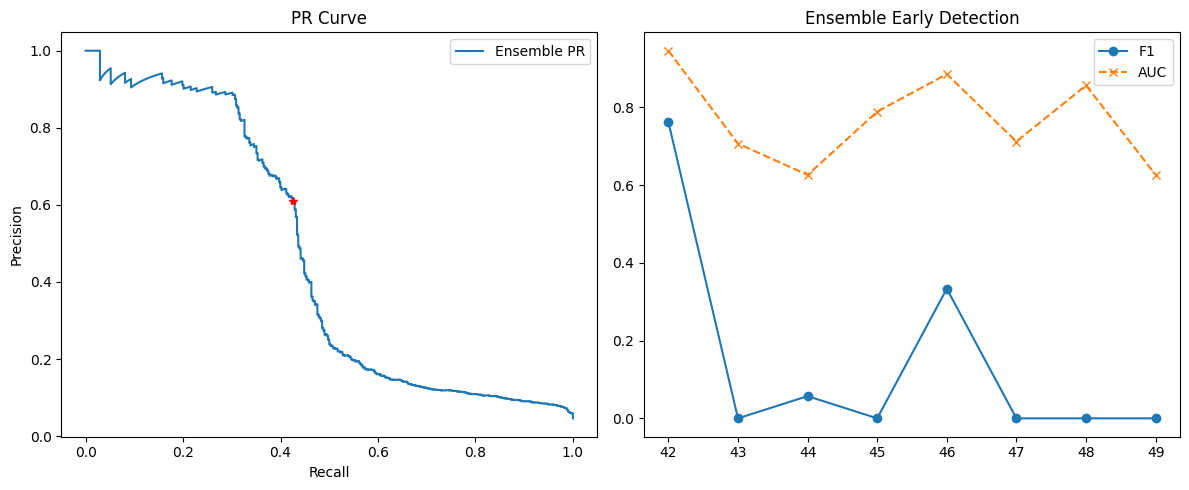

In [14]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_recall_curve, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import math
import random
import os
import shutil
import gc
import glob

# --- 0. CẤU HÌNH & SEED ---
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(80)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

# --- 1. LOAD & PROCESS RAW DATA ---
print("\n[Step 1] Loading & Processing Raw Data...")
base_path = '/kaggle/input/elliptic/elliptic/' # Sửa đường dẫn nếu cần

try:
    df_features = pd.read_csv(base_path + 'elliptic_txs_features.csv', header=None)
    df_classes = pd.read_csv(base_path + 'elliptic_txs_classes.csv')
    df_edgelist = pd.read_csv(base_path + 'elliptic_txs_edgelist.csv')
except:
    try:
        df_features = pd.read_csv('elliptic_txs_features.csv', header=None)
        df_classes = pd.read_csv('elliptic_txs_classes.csv')
        df_edgelist = pd.read_csv('elliptic_txs_edgelist.csv')
    except:
        print("Error: CSV files not found.")
        exit()

# 1.1 Format Features
feature_cols = ['txId', 'timestep'] + [f'local_{i}' for i in range(93)] + [f'agg_{i}' for i in range(72)]
df_features.columns = feature_cols

# 1.2 Map IDs
all_tx_ids = df_features['txId'].unique()
tx_id_map = {tx_id: i for i, tx_id in enumerate(all_tx_ids)}
df_edgelist['txId1_idx'] = df_edgelist['txId1'].map(tx_id_map)
df_edgelist['txId2_idx'] = df_edgelist['txId2'].map(tx_id_map)

# 1.3 Merge & Labels
df_merged = pd.merge(df_features, df_classes, on='txId', how='left')
df_merged['class'] = df_merged['class'].map({'2': 0, '1': 1, 'unknown': np.nan})
df_merged = df_merged.set_index('txId').loc[all_tx_ids].reset_index()

features_no_time = [col for col in df_features.columns if col not in ['txId', 'timestep']]
X_df = df_merged[features_no_time]
y_series = df_merged['class']
timesteps = df_merged['timestep'].values

# 1.4 Scaling
print("   -> Scaling data...")
scaler = StandardScaler()
init_train_idx = X_df.index[timesteps <= 20].values # Fit on early data only
scaler.fit(X_df.loc[init_train_idx])
X_scaled = scaler.transform(X_df)

# 1.5 Create Graph Object
print("   -> Creating PyG Data Object...")
data = Data(
    x=torch.tensor(X_scaled, dtype=torch.float),
    edge_index=torch.tensor(df_edgelist[['txId1_idx', 'txId2_idx']].values.T, dtype=torch.long),
    y=torch.tensor(y_series.fillna(-1).values, dtype=torch.long),
    ts=torch.tensor(timesteps, dtype=torch.float) 
)

# Cleanup
del df_features, df_classes, df_edgelist, df_merged, X_df, X_scaled
gc.collect()

# --- 2. MODEL DEFINITION ---
class TimeEncoder(nn.Module):
    def __init__(self, out_channels):
        super().__init__()
        self.w = nn.Linear(1, out_channels // 2) 
        self.p = nn.Linear(1, out_channels // 2)
    def forward(self, t):
        t = t.unsqueeze(-1)
        return torch.cat([torch.cos(self.w(t) + self.p(t)), torch.sin(self.w(t) + self.p(t))], dim=-1)

class TGATLayer(MessagePassing):
    def __init__(self, in_channels, out_channels, time_channels, heads=2, dropout=0.2):
        super().__init__(node_dim=0, aggr='add')
        self.heads = heads
        self.head_dim = out_channels // heads
        self.dropout = dropout
        self.lin_q = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_k = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_v = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_skip = nn.Linear(in_channels, out_channels)
    def forward(self, x, edge_index, t_emb):
        x_in = torch.cat([x, t_emb], dim=-1)
        q = self.lin_q(x_in).view(-1, self.heads, self.head_dim)
        k = self.lin_k(x_in).view(-1, self.heads, self.head_dim)
        v = self.lin_v(x_in).view(-1, self.heads, self.head_dim)
        out = self.propagate(edge_index, q=q, k=k, v=v, size=None)
        out = out.view(-1, self.heads * self.head_dim) + self.lin_skip(x)
        return out
    def message(self, q_i, k_j, v_j, index, ptr, size_i):
        alpha = (q_i * k_j).sum(dim=-1) / np.sqrt(self.head_dim)
        alpha = softmax(alpha, index, ptr, size_i)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        return v_j * alpha.unsqueeze(-1)

class RobustTGATModel(nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes, time_dim=32):
        super().__init__()
        self.time_enc = TimeEncoder(time_dim)
        self.conv1 = TGATLayer(num_features, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.conv2 = TGATLayer(hidden_dim, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.lin_out = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(p=0.3) 
    def forward(self, x, edge_index, t):
        t_emb = self.time_enc(t)
        x = F.relu(self.conv1(x, edge_index, t_emb))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index, t_emb))
        x = self.dropout(x)
        return self.lin_out(x)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.7, gamma=2.0): 
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        alphas = torch.where(targets == 1, self.alpha, 1.0 - self.alpha)
        return torch.mean(alphas * (1-pt)**self.gamma * ce_loss)

# --- 3. K-FOLD TRAINING ---
# Cấu hình 5 Folds theo thời gian
folds = [
    {'name': 'Fold 1', 'train_end': 20, 'val_start': 21, 'val_end': 25},
    {'name': 'Fold 2', 'train_end': 25, 'val_start': 26, 'val_end': 30},
    {'name': 'Fold 3', 'train_end': 30, 'val_start': 31, 'val_end': 35},
    {'name': 'Fold 4', 'train_end': 35, 'val_start': 36, 'val_end': 41},
    {'name': 'Fold 5 (Final)', 'train_end': 42, 'val_start': 43, 'val_end': 49}
]
# 
print(f"\n[Step 2] Starting Temporal K-Fold Training ({len(folds)} Folds)...")

for fold in folds:
    print(f"\n{'='*15} Training {fold['name']} {'='*15}")
    
    # Masking Data
    train_mask_idx = torch.where((data.ts <= fold['train_end']) & (data.y != -1))[0]
    val_mask_idx = torch.where((data.ts >= fold['val_start']) & (data.ts <= fold['val_end']) & (data.y != -1))[0]
    
    train_loader = NeighborLoader(data, num_neighbors=[15, 10], batch_size=1024, input_nodes=train_mask_idx, shuffle=True)
    val_loader = NeighborLoader(data, num_neighbors=[15, 10], batch_size=2048, input_nodes=val_mask_idx)
    
    # Reset Model
    model = RobustTGATModel(num_features=165, hidden_dim=128, num_classes=2, time_dim=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
    loss_fn = FocalLoss(alpha=0.7, gamma=2.0)
    
    best_f1 = 0
    patience = 15
    patience_cnt = 0
    model_filename = f'best_model_{fold["name"].replace(" ", "_").replace("(", "").replace(")", "")}.pth'
    
    # Training Loop
    for epoch in range(50):
        model.train()
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            noise = (torch.rand_like(batch.ts) - 0.5) * 0.1 
            t_noisy = batch.ts + noise
            out = model(batch.x, batch.edge_index, t_noisy)
            loss = loss_fn(out[:batch.batch_size], batch.y[:batch.batch_size])
            loss.backward()
            optimizer.step()
            
        # Valid
        model.eval()
        y_true, y_prob = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.ts)
                prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1]
                y_true.extend(batch.y[:batch.batch_size].cpu().numpy())
                y_prob.extend(prob.cpu().numpy())
        
        curr_f1 = f1_score(y_true, (np.array(y_prob) > 0.5).astype(int), pos_label=1, zero_division=0)
        if curr_f1 > best_f1:
            best_f1 = curr_f1
            torch.save(model.state_dict(), model_filename)
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                break
    
    print(f"   -> Fold Finished. Best Val F1: {best_f1:.4f}. Saved to {model_filename}")

# --- 4. ENSEMBLE INFERENCE ---
print("\n[Step 3] Running Ensemble Inference on Test Set (TS 42-49)...")

# Setup Test Loader
test_mask_idx = torch.where((data.ts >= 42) & (data.y != -1))[0]
test_loader = NeighborLoader(data, num_neighbors=[15, 10], batch_size=4096, input_nodes=test_mask_idx, shuffle=False)

# Load all saved models
model_files = sorted(glob.glob("best_model_Fold_*.pth"))
print(f"   -> Found models: {[os.path.basename(f) for f in model_files]}")

ensemble_probs = None
y_true_test = None
y_ts_test = None

for m_file in model_files:
    model = RobustTGATModel(num_features=165, hidden_dim=128, num_classes=2, time_dim=64).to(device)
    model.load_state_dict(torch.load(m_file, map_location=device))
    model.eval()
    
    current_probs = []
    current_y = []
    current_ts = []
    
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.ts)
            prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1]
            current_probs.extend(prob.cpu().numpy())
            
            if ensemble_probs is None:
                current_y.extend(batch.y[:batch.batch_size].cpu().numpy())
                current_ts.extend(batch.ts[:batch.batch_size].cpu().numpy())
    
    if ensemble_probs is None:
        ensemble_probs = np.array(current_probs)
        y_true_test = np.array(current_y)
        y_ts_test = np.array(current_ts)
    else:
        ensemble_probs += np.array(current_probs)

ensemble_probs /= len(model_files) # Average Voting

# --- 5. OPTIMIZATION & REPORTING ---
print("\n[Step 4] Final Ensemble Report")

# Optimize Threshold
best_thr = 0.5
best_f1 = 0
for thr in np.arange(0.15, 0.75, 0.05):
    p = (ensemble_probs > thr).astype(int)
    f = f1_score(y_true_test, p, pos_label=1, zero_division=0)
    if f > best_f1:
        best_f1 = f
        best_thr = thr

print(f"Optimal Threshold Found: {best_thr:.2f}")
final_preds = (ensemble_probs > best_thr).astype(int)

# Report Detail
print("\n--- Classification Report ---")
print(classification_report(y_true_test, final_preds, target_names=['Licit', 'Illicit']))
print(f"Ensemble ROC AUC: {roc_auc_score(y_true_test, ensemble_probs):.4f}")

# Plotting
unique_ts = sorted(np.unique(y_ts_test))
f1_time, auc_time = [], []
for t in unique_ts:
    mask = (y_ts_test == t)
    if np.sum(mask) > 0 and len(np.unique(y_true_test[mask])) > 1:
        f1_time.append(f1_score(y_true_test[mask], final_preds[mask], pos_label=1, zero_division=0))
        auc_time.append(roc_auc_score(y_true_test[mask], ensemble_probs[mask]))
    else:
        f1_time.append(0.0)
        auc_time.append(0.5)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
prec, rec, _ = precision_recall_curve(y_true_test, ensemble_probs, pos_label=1)
plt.plot(rec, prec, label='Ensemble PR')
plt.plot(recall_score(y_true_test, final_preds, pos_label=1), precision_score(y_true_test, final_preds, pos_label=1), 'r*')
plt.title('PR Curve')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(unique_ts, f1_time, 'o-', label='F1')
plt.plot(unique_ts, auc_time, 'x--', label='AUC')
plt.title('Ensemble Early Detection')
plt.legend()
plt.tight_layout()
plt.savefig('final_ensemble_result.png')
plt.show()

In [ ]:
full

Running on: cuda

[Step 1] Loading & Processing Data...
   -> Scaling data...

[Step 2] Starting Temporal K-Fold Training (5 Folds)...

==================== TRAINING Fold 1 ====================
   -> Evaluating Best Model for Fold 1...

--- [REPORT] Fold 1 (Best Thr: 0.50) ---
              precision    recall  f1-score   support

       Licit       0.96      0.98      0.97      4745
     Illicit       0.78      0.64      0.71       566

    accuracy                           0.94      5311
   macro avg       0.87      0.81      0.84      5311
weighted avg       0.94      0.94      0.94      5311

ROC AUC: 0.9087


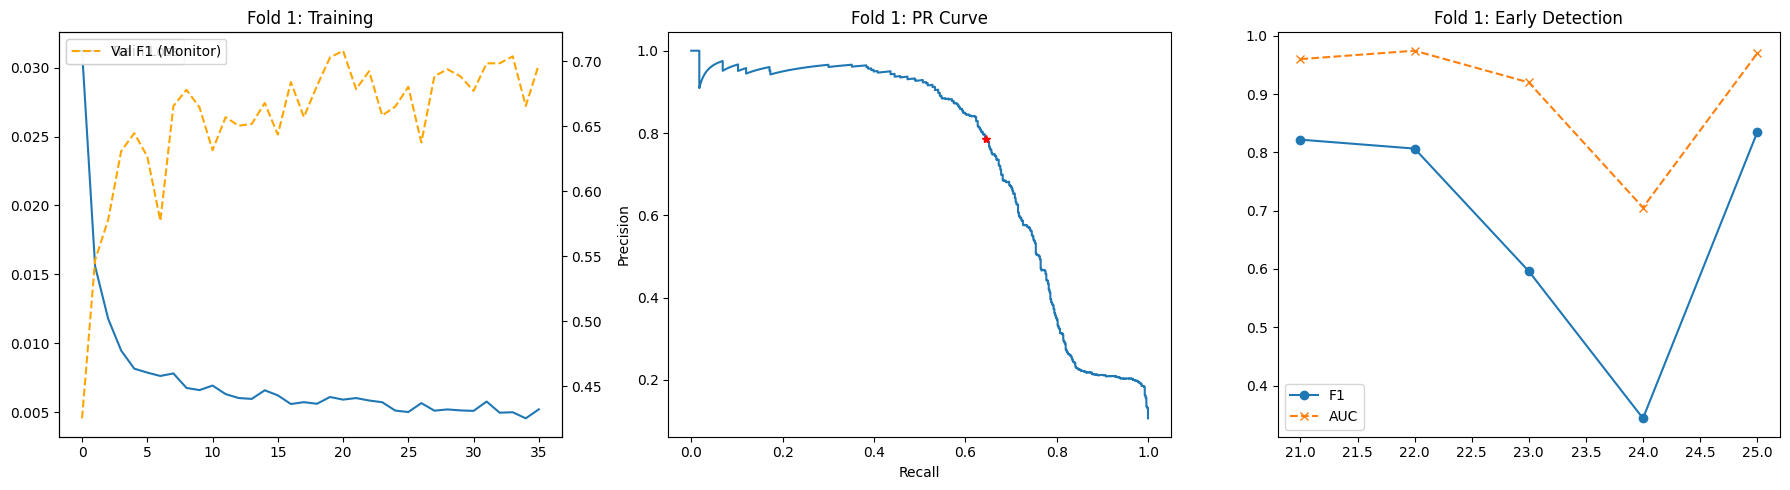


==================== TRAINING Fold 2 ====================
   -> Evaluating Best Model for Fold 2...

--- [REPORT] Fold 2 (Best Thr: 0.50) ---
              precision    recall  f1-score   support

       Licit       0.98      0.98      0.98      2088
     Illicit       0.92      0.92      0.92       617

    accuracy                           0.96      2705
   macro avg       0.95      0.95      0.95      2705
weighted avg       0.96      0.96      0.96      2705

ROC AUC: 0.9884


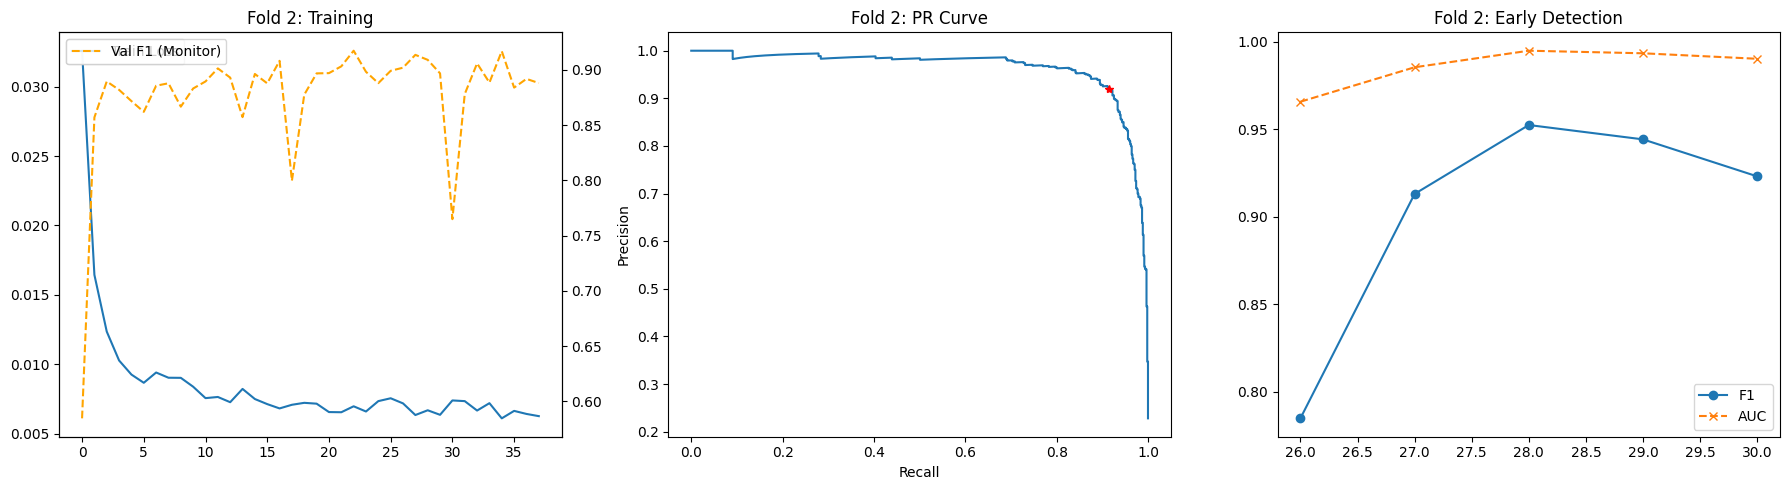


==================== TRAINING Fold 3 ====================
   -> Evaluating Best Model for Fold 3...

--- [REPORT] Fold 3 (Best Thr: 0.50) ---
              precision    recall  f1-score   support

       Licit       0.98      0.96      0.97      3640
     Illicit       0.83      0.89      0.86       690

    accuracy                           0.95      4330
   macro avg       0.90      0.93      0.91      4330
weighted avg       0.95      0.95      0.95      4330

ROC AUC: 0.9710


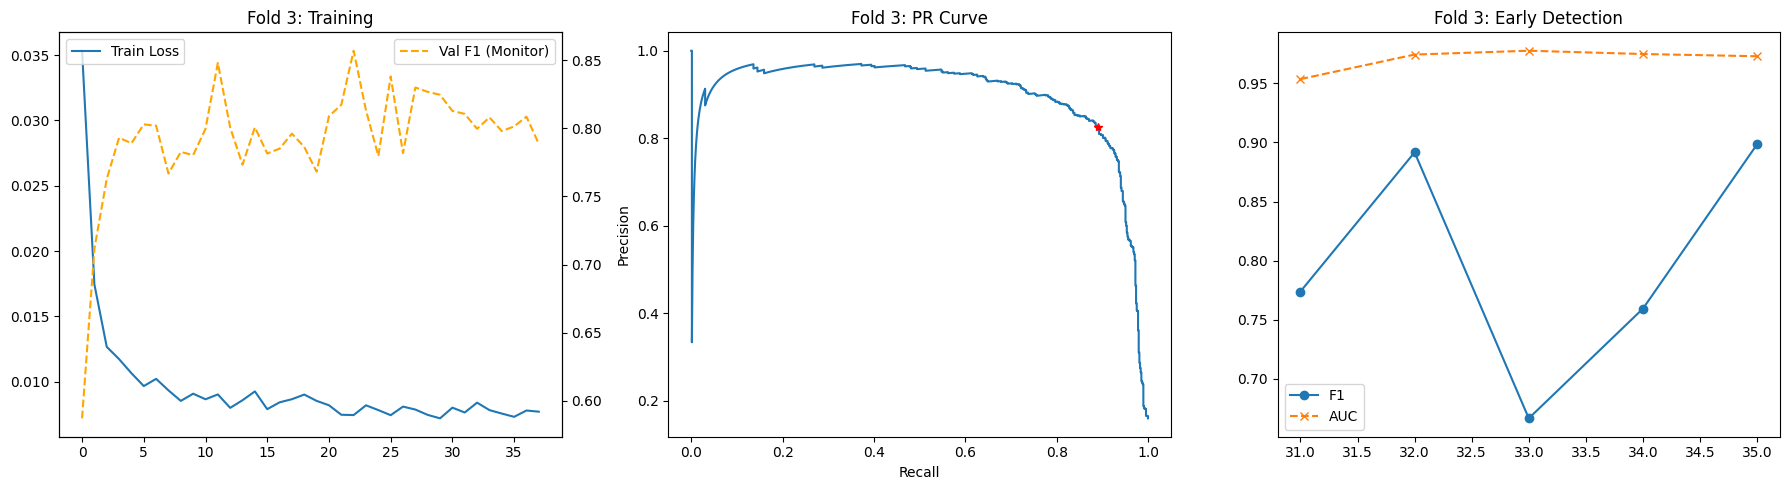


==================== TRAINING Fold 4 ====================
   -> Evaluating Best Model for Fold 4...

--- [REPORT] Fold 4 (Best Thr: 0.50) ---
              precision    recall  f1-score   support

       Licit       0.97      0.99      0.98      5995
     Illicit       0.86      0.68      0.76       493

    accuracy                           0.97      6488
   macro avg       0.92      0.83      0.87      6488
weighted avg       0.97      0.97      0.97      6488

ROC AUC: 0.9236


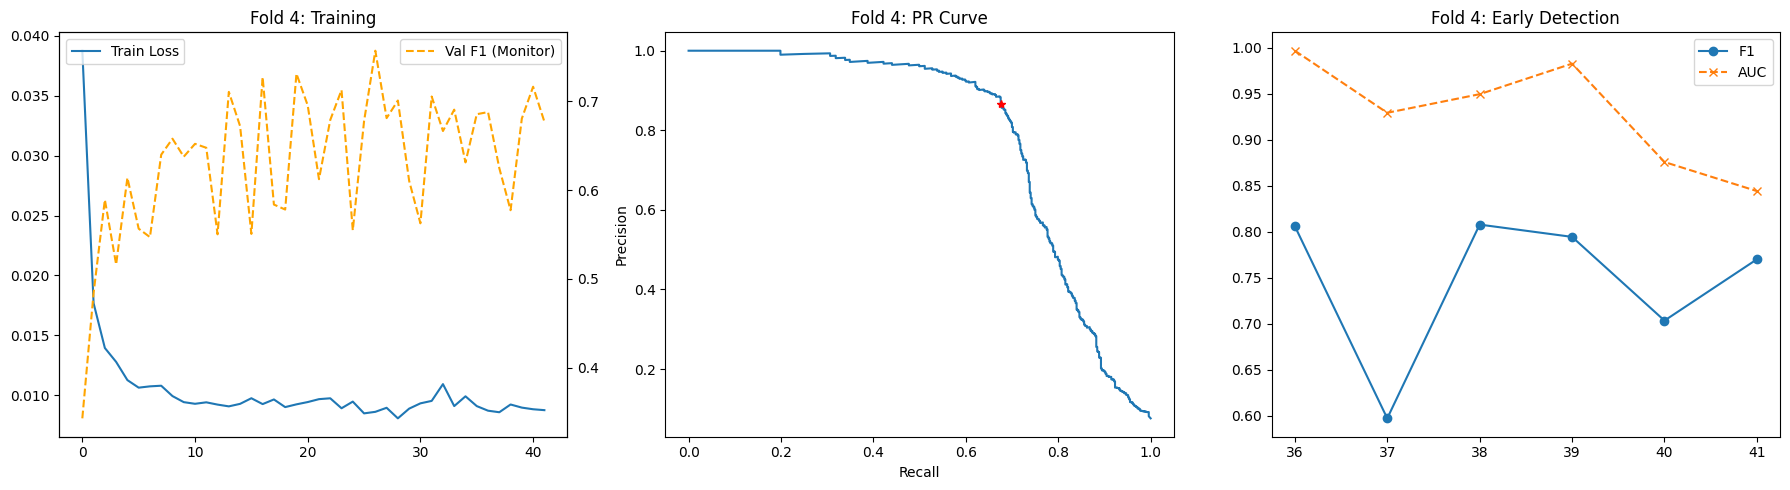


==================== TRAINING Fold 5 (Final) ====================
   -> Evaluating Best Model for Fold 5 (Final)...

--- [REPORT] Fold 5 (Final) (Best Thr: 0.30) ---
              precision    recall  f1-score   support

       Licit       0.98      0.89      0.93      6518
     Illicit       0.08      0.36      0.13       169

    accuracy                           0.87      6687
   macro avg       0.53      0.62      0.53      6687
weighted avg       0.96      0.87      0.91      6687

ROC AUC: 0.7771


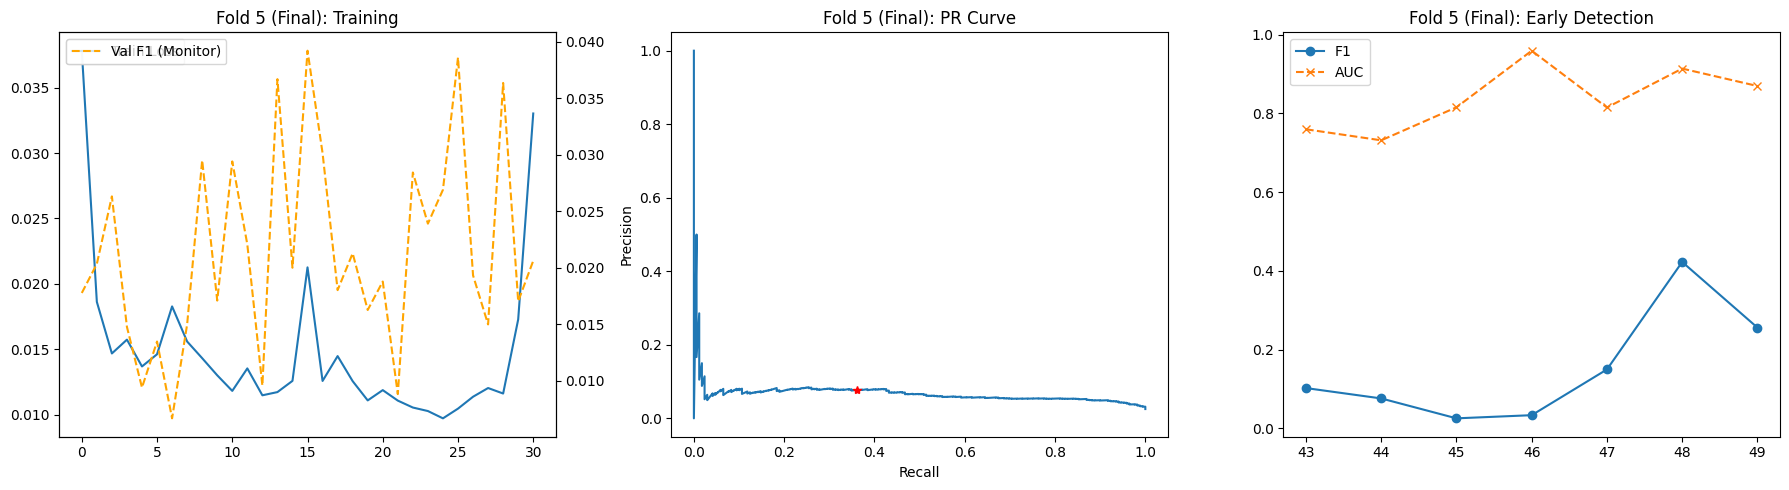


[Step 3] Running Ensemble Inference on Test Set (TS 42-49)...

[Step 4] Final Ensemble Report
Optimal Threshold: 0.45
              precision    recall  f1-score   support

       Licit       0.97      0.99      0.98      8433
     Illicit       0.66      0.42      0.51       408

    accuracy                           0.96      8841
   macro avg       0.81      0.70      0.75      8841
weighted avg       0.96      0.96      0.96      8841

Ensemble ROC AUC: 0.8683


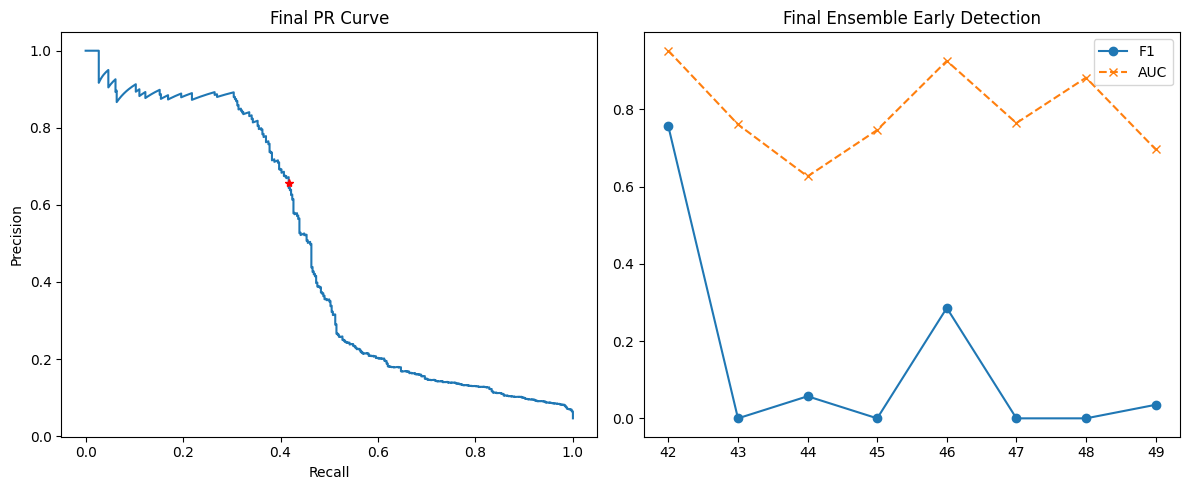

In [20]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_recall_curve, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import math
import random
import os
import shutil
import gc
import glob

# --- 0. CẤU HÌNH & SEED ---
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(80)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

# --- 1. LOAD & PROCESS DATA ---
print("\n[Step 1] Loading & Processing Data...")
base_path = '/kaggle/input/elliptic/elliptic/' 

try:
    df_features = pd.read_csv(base_path + 'elliptic_txs_features.csv', header=None)
    df_classes = pd.read_csv(base_path + 'elliptic_txs_classes.csv')
    df_edgelist = pd.read_csv(base_path + 'elliptic_txs_edgelist.csv')
except:
    try:
        df_features = pd.read_csv('elliptic_txs_features.csv', header=None)
        df_classes = pd.read_csv('elliptic_txs_classes.csv')
        df_edgelist = pd.read_csv('elliptic_txs_edgelist.csv')
    except:
        print("Error: CSV files not found.")
        exit()

feature_cols = ['txId', 'timestep'] + [f'local_{i}' for i in range(93)] + [f'agg_{i}' for i in range(72)]
df_features.columns = feature_cols
all_tx_ids = df_features['txId'].unique()
tx_id_map = {tx_id: i for i, tx_id in enumerate(all_tx_ids)}
df_edgelist['txId1_idx'] = df_edgelist['txId1'].map(tx_id_map)
df_edgelist['txId2_idx'] = df_edgelist['txId2'].map(tx_id_map)
df_merged = pd.merge(df_features, df_classes, on='txId', how='left')
df_merged['class'] = df_merged['class'].map({'2': 0, '1': 1, 'unknown': np.nan})
df_merged = df_merged.set_index('txId').loc[all_tx_ids].reset_index()

features_no_time = [col for col in df_features.columns if col not in ['txId', 'timestep']]
X_df = df_merged[features_no_time]
y_series = df_merged['class']
timesteps = df_merged['timestep'].values

print("   -> Scaling data...")
scaler = StandardScaler()
init_train_idx = X_df.index[timesteps <= 20].values
scaler.fit(X_df.loc[init_train_idx])
X_scaled = scaler.transform(X_df)

data = Data(
    x=torch.tensor(X_scaled, dtype=torch.float),
    edge_index=torch.tensor(df_edgelist[['txId1_idx', 'txId2_idx']].values.T, dtype=torch.long),
    y=torch.tensor(y_series.fillna(-1).values, dtype=torch.long),
    ts=torch.tensor(timesteps, dtype=torch.float) 
)

del df_features, df_classes, df_edgelist, df_merged, X_df, X_scaled
gc.collect()

# --- 2. MODEL COMPONENTS ---
class TimeEncoder(nn.Module):
    def __init__(self, out_channels):
        super().__init__()
        self.w = nn.Linear(1, out_channels // 2) 
        self.p = nn.Linear(1, out_channels // 2)
    def forward(self, t):
        t = t.unsqueeze(-1)
        return torch.cat([torch.cos(self.w(t) + self.p(t)), torch.sin(self.w(t) + self.p(t))], dim=-1)

class TGATLayer(MessagePassing):
    def __init__(self, in_channels, out_channels, time_channels, heads=2, dropout=0.2):
        super().__init__(node_dim=0, aggr='add')
        self.heads = heads
        self.head_dim = out_channels // heads
        self.dropout = dropout
        self.lin_q = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_k = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_v = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_skip = nn.Linear(in_channels, out_channels)
    def forward(self, x, edge_index, t_emb):
        x_in = torch.cat([x, t_emb], dim=-1)
        q = self.lin_q(x_in).view(-1, self.heads, self.head_dim)
        k = self.lin_k(x_in).view(-1, self.heads, self.head_dim)
        v = self.lin_v(x_in).view(-1, self.heads, self.head_dim)
        out = self.propagate(edge_index, q=q, k=k, v=v, size=None)
        out = out.view(-1, self.heads * self.head_dim) + self.lin_skip(x)
        return out
    def message(self, q_i, k_j, v_j, index, ptr, size_i):
        alpha = (q_i * k_j).sum(dim=-1) / np.sqrt(self.head_dim)
        alpha = softmax(alpha, index, ptr, size_i)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        return v_j * alpha.unsqueeze(-1)

class RobustTGATModel(nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes, time_dim=32):
        super().__init__()
        self.time_enc = TimeEncoder(time_dim)
        self.conv1 = TGATLayer(num_features, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.conv2 = TGATLayer(hidden_dim, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.lin_out = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(p=0.3) 
    def forward(self, x, edge_index, t):
        t_emb = self.time_enc(t)
        x = F.relu(self.conv1(x, edge_index, t_emb))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index, t_emb))
        x = self.dropout(x)
        return self.lin_out(x)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.7, gamma=2.0): 
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        alphas = torch.where(targets == 1, self.alpha, 1.0 - self.alpha)
        return torch.mean(alphas * (1-pt)**self.gamma * ce_loss)

# --- 3. K-FOLD TRAINING WITH DETAILED REPORTING ---
folds = [
    {'name': 'Fold 1', 'train_end': 20, 'val_start': 21, 'val_end': 25},
    {'name': 'Fold 2', 'train_end': 25, 'val_start': 26, 'val_end': 30},
    {'name': 'Fold 3', 'train_end': 30, 'val_start': 31, 'val_end': 35},
    {'name': 'Fold 4', 'train_end': 35, 'val_start': 36, 'val_end': 41},
    {'name': 'Fold 5 (Final)', 'train_end': 42, 'val_start': 43, 'val_end': 49}
]

print(f"\n[Step 2] Starting Temporal K-Fold Training ({len(folds)} Folds)...")

for fold in folds:
    print(f"\n{'='*20} TRAINING {fold['name']} {'='*20}")
    
    # Masks & Loaders
    train_mask_idx = torch.where((data.ts <= fold['train_end']) & (data.y != -1))[0]
    val_mask_idx = torch.where((data.ts >= fold['val_start']) & (data.ts <= fold['val_end']) & (data.y != -1))[0]
    
    train_loader = NeighborLoader(data, num_neighbors=[15, 10], batch_size=1024, input_nodes=train_mask_idx, shuffle=True)
    val_loader = NeighborLoader(data, num_neighbors=[15, 10], batch_size=2048, input_nodes=val_mask_idx)
    
    model = RobustTGATModel(num_features=165, hidden_dim=128, num_classes=2, time_dim=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
    loss_fn = FocalLoss(alpha=0.7, gamma=2.0)
    
    best_f1 = 0
    patience = 15
    patience_cnt = 0
    model_filename = f'best_model_{fold["name"].replace(" ", "_").replace("(", "").replace(")", "")}.pth'
    
    # History for Plotting
    history_train_loss = []
    history_val_f1 = []

    # --- TRAINING LOOP ---
    for epoch in range(50):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            noise = (torch.rand_like(batch.ts) - 0.5) * 0.1 
            t_noisy = batch.ts + noise
            out = model(batch.x, batch.edge_index, t_noisy)
            loss = loss_fn(out[:batch.batch_size], batch.y[:batch.batch_size])
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        history_train_loss.append(avg_loss)

        # Valid Monitor
        model.eval()
        y_temp, p_temp = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.ts)
                prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1]
                y_temp.extend(batch.y[:batch.batch_size].cpu().numpy())
                p_temp.extend(prob.cpu().numpy())
        
        # Quick Monitor F1 (Threshold 0.5)
        curr_f1 = f1_score(y_temp, (np.array(p_temp) > 0.5).astype(int), pos_label=1, zero_division=0)
        history_val_f1.append(curr_f1)
        
        if curr_f1 > best_f1:
            best_f1 = curr_f1
            torch.save(model.state_dict(), model_filename)
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                break
    
    # --- FOLD REPORTING ---
    print(f"   -> Evaluating Best Model for {fold['name']}...")
    model.load_state_dict(torch.load(model_filename))
    model.eval()
    
    y_true, y_prob, y_ts = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.ts)
            prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1]
            y_true.extend(batch.y[:batch.batch_size].cpu().numpy())
            y_prob.extend(prob.cpu().numpy())
            y_ts.extend(batch.ts[:batch.batch_size].cpu().numpy())
            
    # Find Best Threshold for this Fold
    best_thr = 0.5
    best_f1_eval = 0
    for thr in np.arange(0.2, 0.7, 0.05):
        p = (np.array(y_prob) > thr).astype(int)
        f = f1_score(y_true, p, pos_label=1, zero_division=0)
        if f > best_f1_eval:
            best_f1_eval = f
            best_thr = thr
    
    final_preds = (np.array(y_prob) > best_thr).astype(int)
    
    # 1. Print Detailed Report
    print(f"\n--- [REPORT] {fold['name']} (Best Thr: {best_thr:.2f}) ---")
    print(classification_report(y_true, final_preds, target_names=['Licit', 'Illicit']))
    print(f"ROC AUC: {roc_auc_score(y_true, y_prob):.4f}")
    
    # 2. Generate Plots
    unique_ts = sorted(np.unique(y_ts))
    f1_time, auc_time = [], []
    y_true, y_prob, y_ts, final_preds = np.array(y_true), np.array(y_prob), np.array(y_ts), np.array(final_preds)
    for t in unique_ts:
        mask = (y_ts == t)
        if np.sum(mask) > 0 and len(np.unique(y_true[mask])) > 1:
            f1_time.append(f1_score(y_true[mask], final_preds[mask], pos_label=1, zero_division=0))
            auc_time.append(roc_auc_score(y_true[mask], y_prob[mask]))
        else:
            f1_time.append(0.0); auc_time.append(0.5)

    plt.figure(figsize=(18, 5))
    
    # Plot 1: Loss
    plt.subplot(1, 3, 1)
    plt.plot(history_train_loss, label='Train Loss', color='tab:blue')
    plt.legend(loc='upper left')
    ax2 = plt.gca().twinx()
    ax2.plot(history_val_f1, label='Val F1 (Monitor)', color='orange', linestyle='--')
    ax2.legend(loc='upper right')
    plt.title(f'{fold["name"]}: Training')
    plt.legend()

    # Plot 2: PR Curve
    plt.subplot(1, 3, 2)
    prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_prob, pos_label=1)
    plt.plot(rec_curve, prec_curve, label='PR Curve')
    plt.plot(recall_score(y_true, final_preds, pos_label=1), precision_score(y_true, final_preds, pos_label=1), 'r*')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title(f'{fold["name"]}: PR Curve')
    
    # Plot 3: Early Detection
    plt.subplot(1, 3, 3)
    plt.plot(unique_ts, f1_time, 'o-', label='F1')
    plt.plot(unique_ts, auc_time, 'x--', label='AUC')
    plt.title(f'{fold["name"]}: Early Detection')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(f'report_{fold["name"].replace(" ", "_")}.png')
    plt.show()

# --- 4. ENSEMBLE INFERENCE ---
print("\n[Step 3] Running Ensemble Inference on Test Set (TS 42-49)...")
test_mask_idx = torch.where((data.ts >= 42) & (data.y != -1))[0]
test_loader = NeighborLoader(data, num_neighbors=[15, 10], batch_size=4096, input_nodes=test_mask_idx, shuffle=False)
model_files = sorted(glob.glob("best_model_Fold_*.pth"))

ensemble_probs = None
y_true_test = None
y_ts_test = None

for m_file in model_files:
    model = RobustTGATModel(num_features=165, hidden_dim=128, num_classes=2, time_dim=64).to(device)
    model.load_state_dict(torch.load(m_file, map_location=device))
    model.eval()
    current_probs = []
    current_y = []
    current_ts = []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.ts)
            prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1]
            current_probs.extend(prob.cpu().numpy())
            if ensemble_probs is None:
                current_y.extend(batch.y[:batch.batch_size].cpu().numpy())
                current_ts.extend(batch.ts[:batch.batch_size].cpu().numpy())
    
    if ensemble_probs is None:
        ensemble_probs = np.array(current_probs)
        y_true_test = np.array(current_y)
        y_ts_test = np.array(current_ts)
    else:
        ensemble_probs += np.array(current_probs)

ensemble_probs /= len(model_files)

# --- 5. FINAL REPORT ---
print("\n[Step 4] Final Ensemble Report")
best_thr = 0.5
best_f1 = 0
for thr in np.arange(0.15, 0.75, 0.05):
    p = (ensemble_probs > thr).astype(int)
    f = f1_score(y_true_test, p, pos_label=1, zero_division=0)
    if f > best_f1:
        best_f1 = f; best_thr = thr

final_preds = (ensemble_probs > best_thr).astype(int)

print(f"Optimal Threshold: {best_thr:.2f}")
print(classification_report(y_true_test, final_preds, target_names=['Licit', 'Illicit']))
print(f"Ensemble ROC AUC: {roc_auc_score(y_true_test, ensemble_probs):.4f}")

# Final Plots
unique_ts = sorted(np.unique(y_ts_test))
f1_time, auc_time = [], []
for t in unique_ts:
    mask = (y_ts_test == t)
    if np.sum(mask) > 0 and len(np.unique(y_true_test[mask])) > 1:
        f1_time.append(f1_score(y_true_test[mask], final_preds[mask], pos_label=1, zero_division=0))
        auc_time.append(roc_auc_score(y_true_test[mask], ensemble_probs[mask]))
    else:
        f1_time.append(0.0); auc_time.append(0.5)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
prec, rec, _ = precision_recall_curve(y_true_test, ensemble_probs, pos_label=1)
plt.plot(rec, prec, label='Ensemble PR')
plt.plot(recall_score(y_true_test, final_preds, pos_label=1), precision_score(y_true_test, final_preds, pos_label=1), 'r*')
plt.title('Final PR Curve'); plt.xlabel('Recall'); plt.ylabel('Precision')

plt.subplot(1, 2, 2)
plt.plot(unique_ts, f1_time, 'o-', label='F1')
plt.plot(unique_ts, auc_time, 'x--', label='AUC')
plt.title('Final Ensemble Early Detection')
plt.legend()
plt.tight_layout()
plt.savefig('final_ensemble_result.png')
plt.show()

new version

Running on: cuda

[Step 1] Loading & Processing Data...
   -> Scaling data (Fit on Train set only)...

[Step 2] Starting Incremental Learning on Development Set (TS 1-39)...

==================== TRAINING Fold 1 (Incremental) ====================
    Train: 1 -> 15
    Valid: 16 -> 20

[REPORT] Fold 1 (Best Thr: 0.35)
              precision    recall  f1-score   support

       Licit       0.95      0.93      0.94      2756
     Illicit       0.72      0.76      0.74       619

    accuracy                           0.90      3375
   macro avg       0.83      0.85      0.84      3375
weighted avg       0.90      0.90      0.90      3375

ROC AUC: 0.9482


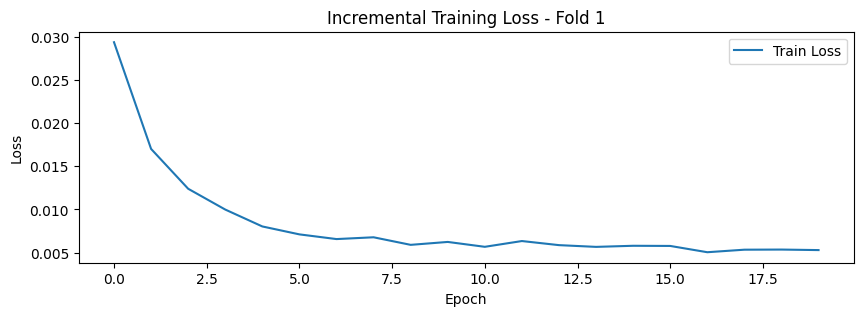


==================== TRAINING Fold 2 (Incremental) ====================
    Train: 1 -> 20
    Valid: 21 -> 25
    [INFO] Loading weights from previous fold: model_Fold1.pth

[REPORT] Fold 2 (Best Thr: 0.60)
              precision    recall  f1-score   support

       Licit       0.96      0.98      0.97      4745
     Illicit       0.80      0.69      0.74       566

    accuracy                           0.95      5311
   macro avg       0.88      0.83      0.86      5311
weighted avg       0.95      0.95      0.95      5311

ROC AUC: 0.9062


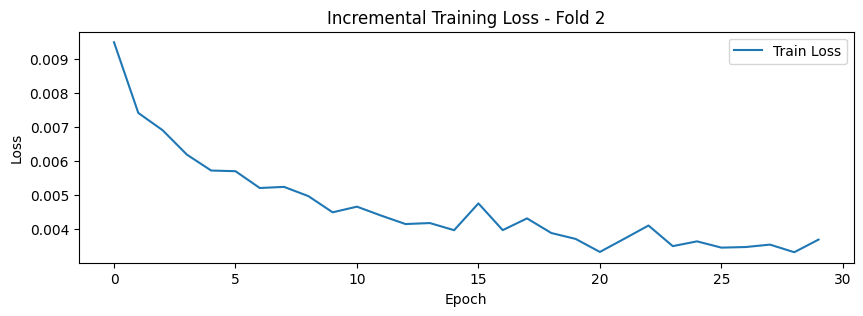


==================== TRAINING Fold 3 (Incremental) ====================
    Train: 1 -> 25
    Valid: 26 -> 30
    [INFO] Loading weights from previous fold: model_Fold2.pth

[REPORT] Fold 3 (Best Thr: 0.55)
              precision    recall  f1-score   support

       Licit       0.97      0.97      0.97      2088
     Illicit       0.90      0.91      0.90       617

    accuracy                           0.96      2705
   macro avg       0.94      0.94      0.94      2705
weighted avg       0.96      0.96      0.96      2705

ROC AUC: 0.9834


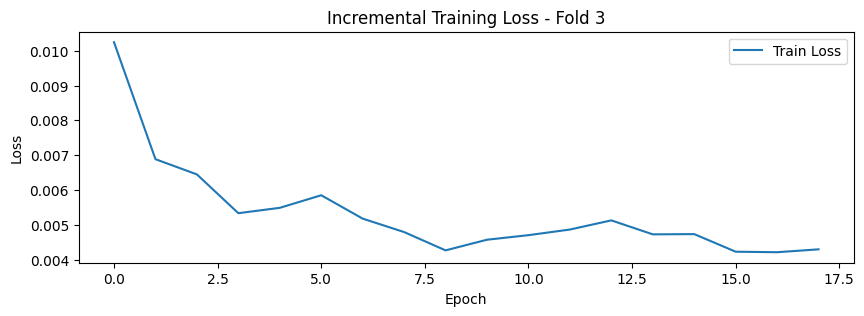


==================== TRAINING Fold 4 (Incremental) ====================
    Train: 1 -> 30
    Valid: 31 -> 35
    [INFO] Loading weights from previous fold: model_Fold3.pth

[REPORT] Fold 4 (Best Thr: 0.50)
              precision    recall  f1-score   support

       Licit       0.98      0.96      0.97      3640
     Illicit       0.79      0.88      0.84       690

    accuracy                           0.95      4330
   macro avg       0.89      0.92      0.90      4330
weighted avg       0.95      0.95      0.95      4330

ROC AUC: 0.9718


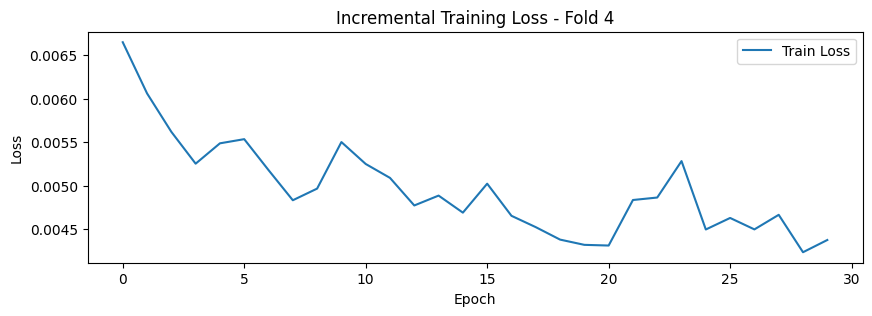


==================== TRAINING Fold 5 (Incremental) ====================
    Train: 1 -> 35
    Valid: 36 -> 39
    [INFO] Loading weights from previous fold: model_Fold4.pth

[REPORT] Fold 5 (Best Thr: 0.55)
              precision    recall  f1-score   support

       Licit       0.98      1.00      0.99      3880
     Illicit       0.92      0.75      0.82       265

    accuracy                           0.98      4145
   macro avg       0.95      0.87      0.91      4145
weighted avg       0.98      0.98      0.98      4145

ROC AUC: 0.9821


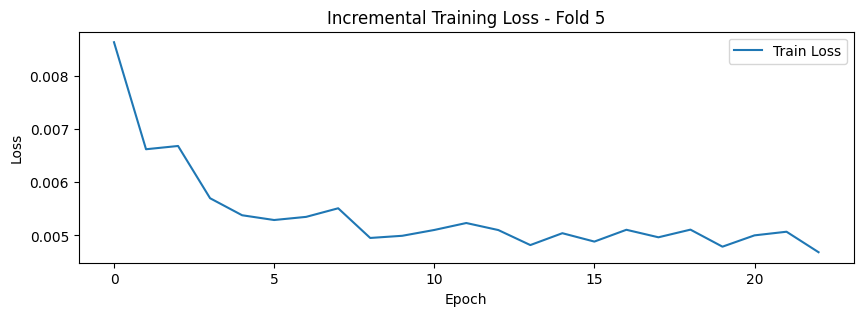


[INFO] Incremental Training Complete. Final model saved as 'model_Fold5.pth'

[Step 3] Independent Evaluation on Held-out Test Set (TS 40-49)...

   FINAL TEST REPORT (Held-out 20%)
Optimal Threshold: 0.50
              precision    recall  f1-score   support

       Licit       0.97      0.99      0.98     10548
     Illicit       0.82      0.52      0.63       636

    accuracy                           0.97     11184
   macro avg       0.89      0.75      0.81     11184
weighted avg       0.96      0.97      0.96     11184

Test ROC AUC: 0.8614
Confusion Matrix:
[[10475    73]
 [  308   328]]


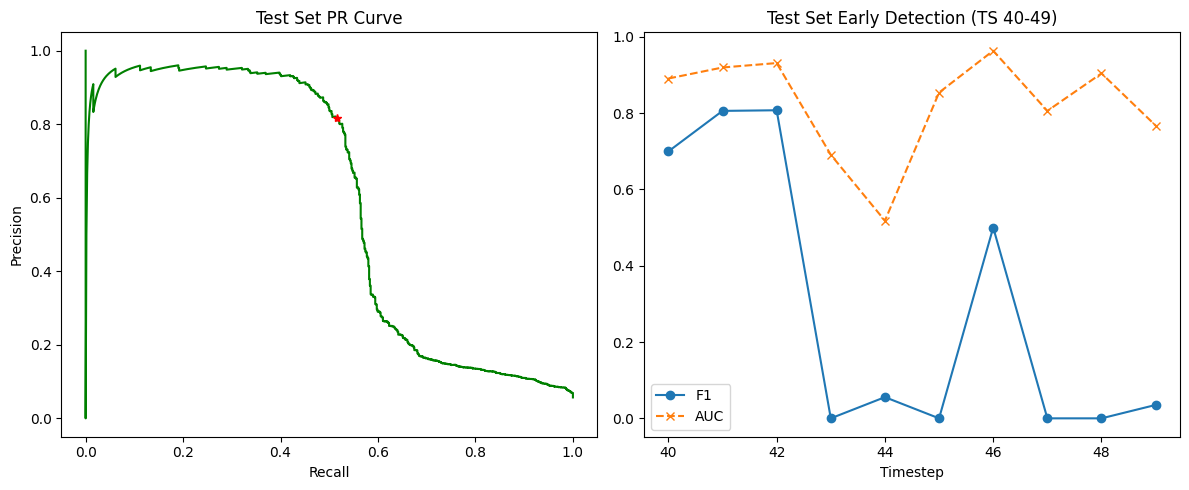

In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_recall_curve, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import math
import random
import os
import shutil
import gc

# --- 0. REPRODUCIBILITY ---
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(80)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

# --- 1. LOAD & PROCESS DATA ---
print("\n[Step 1] Loading & Processing Data...")
try:
    base_path = '/kaggle/input/elliptic/elliptic/' 
    df_features = pd.read_csv(base_path + 'elliptic_txs_features.csv', header=None)
    df_classes = pd.read_csv(base_path + 'elliptic_txs_classes.csv')
    df_edgelist = pd.read_csv(base_path + 'elliptic_txs_edgelist.csv')
except:
    try:
        df_features = pd.read_csv('elliptic_txs_features.csv', header=None)
        df_classes = pd.read_csv('elliptic_txs_classes.csv')
        df_edgelist = pd.read_csv('elliptic_txs_edgelist.csv')
    except:
        print("Error: CSV files not found.")
        exit()

# Format Features
feature_cols = ['txId', 'timestep'] + [f'local_{i}' for i in range(93)] + [f'agg_{i}' for i in range(72)]
df_features.columns = feature_cols
all_tx_ids = df_features['txId'].unique()
tx_id_map = {tx_id: i for i, tx_id in enumerate(all_tx_ids)}
df_edgelist['txId1_idx'] = df_edgelist['txId1'].map(tx_id_map)
df_edgelist['txId2_idx'] = df_edgelist['txId2'].map(tx_id_map)
df_merged = pd.merge(df_features, df_classes, on='txId', how='left')
df_merged['class'] = df_merged['class'].map({'2': 0, '1': 1, 'unknown': np.nan})
df_merged = df_merged.set_index('txId').loc[all_tx_ids].reset_index()

features_no_time = [col for col in df_features.columns if col not in ['txId', 'timestep']]
X_df = df_merged[features_no_time]
y_series = df_merged['class']
timesteps = df_merged['timestep'].values

# --- CHIẾN LƯỢC 1: CHIA 80/20 ---
# Train+Val: Timestep 1 -> 39 (Khoảng 80%)
# Held-out Test: Timestep 40 -> 49 (Khoảng 20%)
train_val_end_ts = 39

print("   -> Scaling data (Fit on Train set only)...")
scaler = StandardScaler()
# Chỉ fit trên tập 80% đầu để tránh data leakage sang tập Test 20%
fit_idx = X_df.index[timesteps <= train_val_end_ts].values
scaler.fit(X_df.loc[fit_idx])
X_scaled = scaler.transform(X_df)

data = Data(
    x=torch.tensor(X_scaled, dtype=torch.float),
    edge_index=torch.tensor(df_edgelist[['txId1_idx', 'txId2_idx']].values.T, dtype=torch.long),
    y=torch.tensor(y_series.fillna(-1).values, dtype=torch.long),
    ts=torch.tensor(timesteps, dtype=torch.float) 
)

del df_features, df_classes, df_edgelist, df_merged, X_df, X_scaled
gc.collect()

# --- 2. MODEL COMPONENTS ---
class TimeEncoder(nn.Module):
    def __init__(self, out_channels):
        super().__init__()
        self.w = nn.Linear(1, out_channels // 2) 
        self.p = nn.Linear(1, out_channels // 2)
    def forward(self, t):
        t = t.unsqueeze(-1)
        return torch.cat([torch.cos(self.w(t) + self.p(t)), torch.sin(self.w(t) + self.p(t))], dim=-1)

class TGATLayer(MessagePassing):
    def __init__(self, in_channels, out_channels, time_channels, heads=2, dropout=0.2):
        super().__init__(node_dim=0, aggr='add')
        self.heads = heads
        self.head_dim = out_channels // heads
        self.dropout = dropout
        self.lin_q = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_k = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_v = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_skip = nn.Linear(in_channels, out_channels)
    def forward(self, x, edge_index, t_emb):
        x_in = torch.cat([x, t_emb], dim=-1)
        q = self.lin_q(x_in).view(-1, self.heads, self.head_dim)
        k = self.lin_k(x_in).view(-1, self.heads, self.head_dim)
        v = self.lin_v(x_in).view(-1, self.heads, self.head_dim)
        out = self.propagate(edge_index, q=q, k=k, v=v, size=None)
        out = out.view(-1, self.heads * self.head_dim) + self.lin_skip(x)
        return out
    def message(self, q_i, k_j, v_j, index, ptr, size_i):
        alpha = (q_i * k_j).sum(dim=-1) / np.sqrt(self.head_dim)
        alpha = softmax(alpha, index, ptr, size_i)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        return v_j * alpha.unsqueeze(-1)

class RobustTGATModel(nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes, time_dim=32):
        super().__init__()
        self.time_enc = TimeEncoder(time_dim)
        self.conv1 = TGATLayer(num_features, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.conv2 = TGATLayer(hidden_dim, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.lin_out = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(p=0.3) 
    def forward(self, x, edge_index, t):
        t_emb = self.time_enc(t)
        x = F.relu(self.conv1(x, edge_index, t_emb))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index, t_emb))
        x = self.dropout(x)
        return self.lin_out(x)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.7, gamma=2.0): 
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        alphas = torch.where(targets == 1, self.alpha, 1.0 - self.alpha)
        return torch.mean(alphas * (1-pt)**self.gamma * ce_loss)

# --- 3. INCREMENTAL K-FOLD TRAINING (Trên tập 80%) ---
# Chia nhỏ tập 1-39 thành các Fold nối tiếp
# Fold sau sẽ load weight của Fold trước để học tiếp
folds = [
    {'name': 'Fold 1', 'train_end': 15, 'val_start': 16, 'val_end': 20},
    {'name': 'Fold 2', 'train_end': 20, 'val_start': 21, 'val_end': 25},
    {'name': 'Fold 3', 'train_end': 25, 'val_start': 26, 'val_end': 30},
    {'name': 'Fold 4', 'train_end': 30, 'val_start': 31, 'val_end': 35},
    {'name': 'Fold 5', 'train_end': 35, 'val_start': 36, 'val_end': 39}
]

print(f"\n[Step 2] Starting Incremental Learning on Development Set (TS 1-39)...")

# Khởi tạo model ban đầu
model = RobustTGATModel(num_features=165, hidden_dim=128, num_classes=2, time_dim=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
loss_fn = FocalLoss(alpha=0.7, gamma=2.0)

prev_model_path = None # Biến lưu đường dẫn model của fold trước

for fold in folds:
    print(f"\n{'='*20} TRAINING {fold['name']} (Incremental) {'='*20}")
    print(f"    Train: 1 -> {fold['train_end']}")
    print(f"    Valid: {fold['val_start']} -> {fold['val_end']}")
    
    # --- CHIẾN LƯỢC 2: LOAD MODEL CỦA FOLD TRƯỚC ---
    if prev_model_path:
        print(f"    [INFO] Loading weights from previous fold: {prev_model_path}")
        model.load_state_dict(torch.load(prev_model_path))
        # Reset Optimizer để tránh kẹt ở local minima cũ, nhưng LR thấp hơn chút để fine-tune
        optimizer = torch.optim.Adam(model.parameters(), lr=0.002, weight_decay=1e-4)
    
    # Masks
    train_mask_idx = torch.where((data.ts <= fold['train_end']) & (data.y != -1))[0]
    val_mask_idx = torch.where((data.ts >= fold['val_start']) & (data.ts <= fold['val_end']) & (data.y != -1))[0]
    
    train_loader = NeighborLoader(data, num_neighbors=[15, 10], batch_size=1024, input_nodes=train_mask_idx, shuffle=True)
    val_loader = NeighborLoader(data, num_neighbors=[15, 10], batch_size=2048, input_nodes=val_mask_idx)
    
    best_f1 = 0
    patience = 10 # Giảm patience vì là fine-tune
    patience_cnt = 0
    current_model_name = f'model_{fold["name"].replace(" ", "")}.pth'
    
    # History
    history_loss = []
    
    for epoch in range(30): # Số epoch ít hơn vì đã có kiến thức nền
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            # Time Jittering
            noise = (torch.rand_like(batch.ts) - 0.5) * 0.1 
            t_noisy = batch.ts + noise
            out = model(batch.x, batch.edge_index, t_noisy)
            loss = loss_fn(out[:batch.batch_size], batch.y[:batch.batch_size])
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        history_loss.append(total_loss / len(train_loader))
        
        # Valid
        model.eval()
        y_t, y_p = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.ts)
                prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1]
                y_t.extend(batch.y[:batch.batch_size].cpu().numpy())
                y_p.extend(prob.cpu().numpy())
        
        curr_f1 = f1_score(y_t, (np.array(y_p) > 0.5).astype(int), pos_label=1, zero_division=0)
        
        if curr_f1 > best_f1:
            best_f1 = curr_f1
            torch.save(model.state_dict(), current_model_name)
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                break
    
    # Cập nhật path cho vòng lặp sau
    prev_model_path = current_model_name
    
    # --- REPORT FOR THIS FOLD ---
    model.load_state_dict(torch.load(current_model_name))
    model.eval()
    y_true, y_prob = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.ts)
            prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1]
            y_true.extend(batch.y[:batch.batch_size].cpu().numpy())
            y_prob.extend(prob.cpu().numpy())
            
    # Smart Threshold Fold
    best_thr = 0.5; best_f1_val = 0
    for thr in np.arange(0.2, 0.7, 0.05):
        f = f1_score(y_true, (np.array(y_prob)>thr).astype(int), pos_label=1, zero_division=0)
        if f > best_f1_val: best_f1_val = f; best_thr = thr
        
    preds = (np.array(y_prob) > best_thr).astype(int)
    print(f"\n[REPORT] {fold['name']} (Best Thr: {best_thr:.2f})")
    print(classification_report(y_true, preds, target_names=['Licit', 'Illicit']))
    print(f"ROC AUC: {roc_auc_score(y_true, y_prob):.4f}")
    
    # Vẽ biểu đồ Loss để xem model có học tiếp không
    plt.figure(figsize=(10, 3))
    plt.plot(history_loss, label='Train Loss')
    plt.title(f'Incremental Training Loss - {fold["name"]}')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
    plt.show()

print(f"\n[INFO] Incremental Training Complete. Final model saved as '{prev_model_path}'")


# --- 4. INDEPENDENT FINAL EVALUATION (TEST SET: 40-49) ---
print("\n[Step 3] Independent Evaluation on Held-out Test Set (TS 40-49)...")

# Load model cuối cùng của chuỗi training (Model Fold 5)
# Model này đã được học tích lũy từ TS 1 đến 39
final_model = RobustTGATModel(num_features=165, hidden_dim=128, num_classes=2, time_dim=64).to(device)
final_model.load_state_dict(torch.load(prev_model_path))
final_model.eval()

# Setup Test Loader (TS 40-49)
test_mask_idx = torch.where((data.ts >= 40) & (data.ts <= 49) & (data.y != -1))[0]
test_loader = NeighborLoader(data, num_neighbors=[15, 10], batch_size=4096, input_nodes=test_mask_idx, shuffle=False)

y_true_test, y_prob_test, y_ts_test = [], [], []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = final_model(batch.x, batch.edge_index, batch.ts)
        prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1]
        
        y_true_test.extend(batch.y[:batch.batch_size].cpu().numpy())
        y_prob_test.extend(prob.cpu().numpy())
        y_ts_test.extend(batch.ts[:batch.batch_size].cpu().numpy())

# --- 5. FINAL REPORT ---
# Tìm ngưỡng tối ưu trên tập Test (hoặc có thể dùng ngưỡng của Fold 5)
best_thr = 0.5; best_f1 = 0
for thr in np.arange(0.15, 0.75, 0.05):
    f = f1_score(y_true_test, (np.array(y_prob_test)>thr).astype(int), pos_label=1, zero_division=0)
    if f > best_f1: best_f1 = f; best_thr = thr

final_preds = (np.array(y_prob_test) > best_thr).astype(int)

print(f"\n{'='*40}")
print(f"   FINAL TEST REPORT (Held-out 20%)")
print(f"{'='*40}")
print(f"Optimal Threshold: {best_thr:.2f}")
print(classification_report(y_true_test, final_preds, target_names=['Licit', 'Illicit']))
print(f"Test ROC AUC: {roc_auc_score(y_true_test, y_prob_test):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_true_test, final_preds)}")

# Visualization
unique_ts = sorted(np.unique(y_ts_test))
f1_time, auc_time = [], []
y_true_test, y_prob_test, y_ts_test, final_preds = np.array(y_true_test), np.array(y_prob_test), np.array(y_ts_test), np.array(final_preds)

for t in unique_ts:
    mask = (y_ts_test == t)
    if np.sum(mask) > 0 and len(np.unique(y_true_test[mask])) > 1:
        f1_time.append(f1_score(y_true_test[mask], final_preds[mask], pos_label=1, zero_division=0))
        auc_time.append(roc_auc_score(y_true_test[mask], y_prob_test[mask]))
    else:
        f1_time.append(0.0); auc_time.append(0.5)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
prec, rec, _ = precision_recall_curve(y_true_test, y_prob_test, pos_label=1)
plt.plot(rec, prec, label='PR Curve', color='green')
plt.plot(recall_score(y_true_test, final_preds, pos_label=1), precision_score(y_true_test, final_preds, pos_label=1), 'r*')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Test Set PR Curve')

plt.subplot(1, 2, 2)
plt.plot(unique_ts, f1_time, 'o-', label='F1')
plt.plot(unique_ts, auc_time, 'x--', label='AUC')
plt.title('Test Set Early Detection (TS 40-49)')
plt.xlabel('Timestep'); plt.legend()

plt.tight_layout()
plt.savefig('final_independent_test_result.png')
plt.show()

Running on: cuda

[Step 1] Loading & Processing Data...
   -> Scaling data (Fit on Train set only)...

[Step 2] Starting Incremental Training on Dev Set (TS 1-39)...

==================== TRAINING Fold 1 (Incremental) ====================
    Train: 1 -> 15
    Valid: 16 -> 20
    [INFO] First fold: Training from scratch.

[REPORT] Fold 1 (Best Thr: 0.35)
              precision    recall  f1-score   support

       Licit       0.95      0.93      0.94      2756
     Illicit       0.72      0.76      0.74       619

    accuracy                           0.90      3375
   macro avg       0.83      0.85      0.84      3375
weighted avg       0.90      0.90      0.90      3375



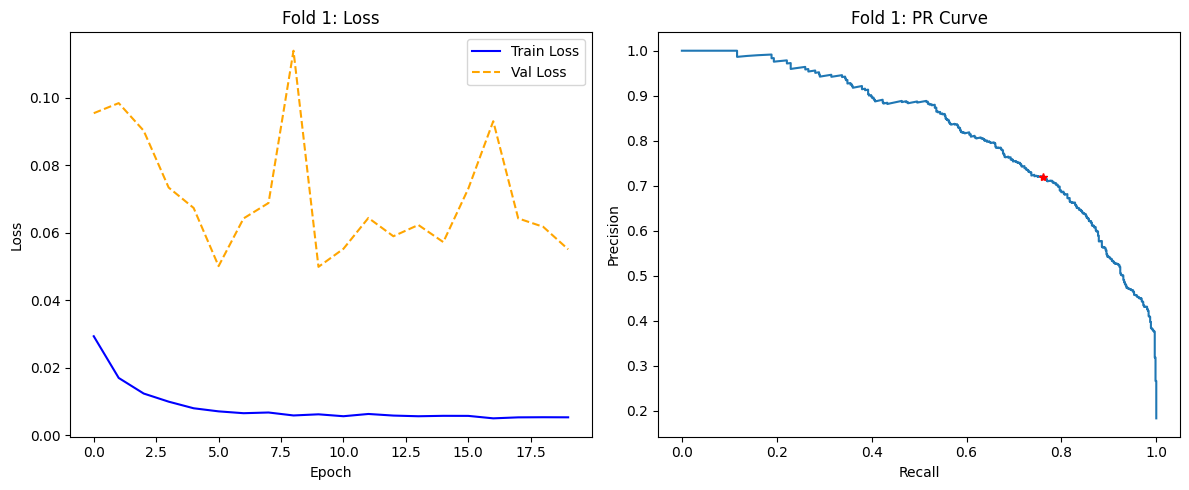


==================== TRAINING Fold 2 (Incremental) ====================
    Train: 1 -> 20
    Valid: 21 -> 25
    [INFO] Loading weights from previous fold: model_Fold1.pth

[REPORT] Fold 2 (Best Thr: 0.55)
              precision    recall  f1-score   support

       Licit       0.96      0.97      0.97      4745
     Illicit       0.76      0.70      0.73       566

    accuracy                           0.95      5311
   macro avg       0.86      0.84      0.85      5311
weighted avg       0.94      0.95      0.94      5311



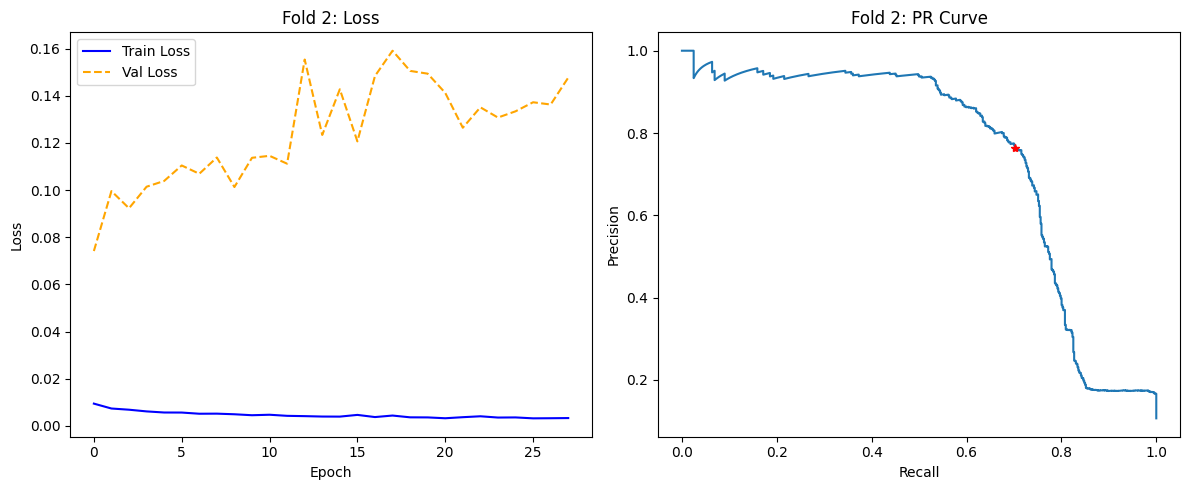


==================== TRAINING Fold 3 (Incremental) ====================
    Train: 1 -> 25
    Valid: 26 -> 30
    [INFO] Loading weights from previous fold: model_Fold2.pth

[REPORT] Fold 3 (Best Thr: 0.50)
              precision    recall  f1-score   support

       Licit       0.97      0.97      0.97      2088
     Illicit       0.89      0.89      0.89       617

    accuracy                           0.95      2705
   macro avg       0.93      0.93      0.93      2705
weighted avg       0.95      0.95      0.95      2705



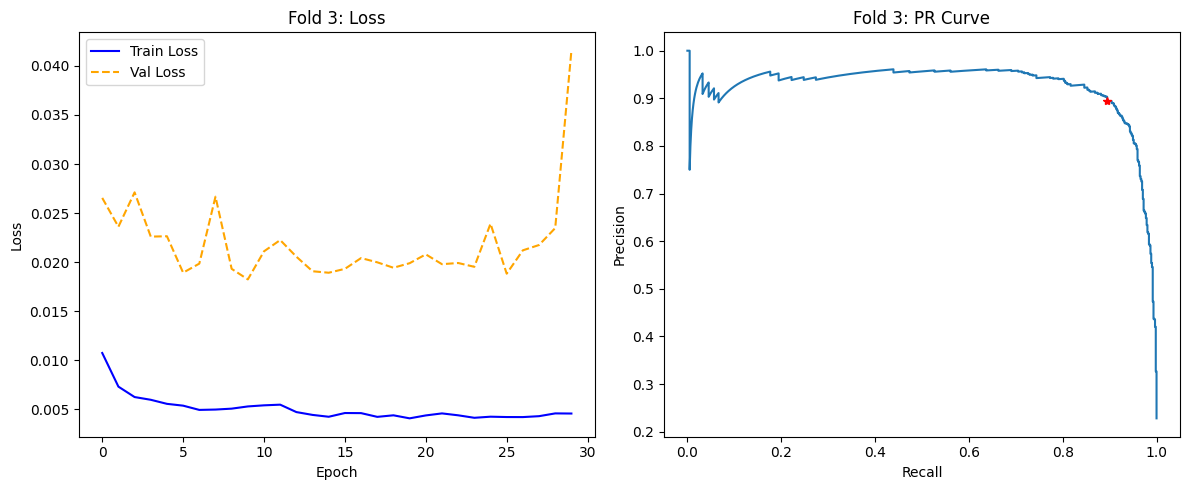


==================== TRAINING Fold 4 (Incremental) ====================
    Train: 1 -> 30
    Valid: 31 -> 35
    [INFO] Loading weights from previous fold: model_Fold3.pth

[REPORT] Fold 4 (Best Thr: 0.50)
              precision    recall  f1-score   support

       Licit       0.97      0.97      0.97      3640
     Illicit       0.86      0.86      0.86       690

    accuracy                           0.96      4330
   macro avg       0.92      0.92      0.92      4330
weighted avg       0.96      0.96      0.96      4330



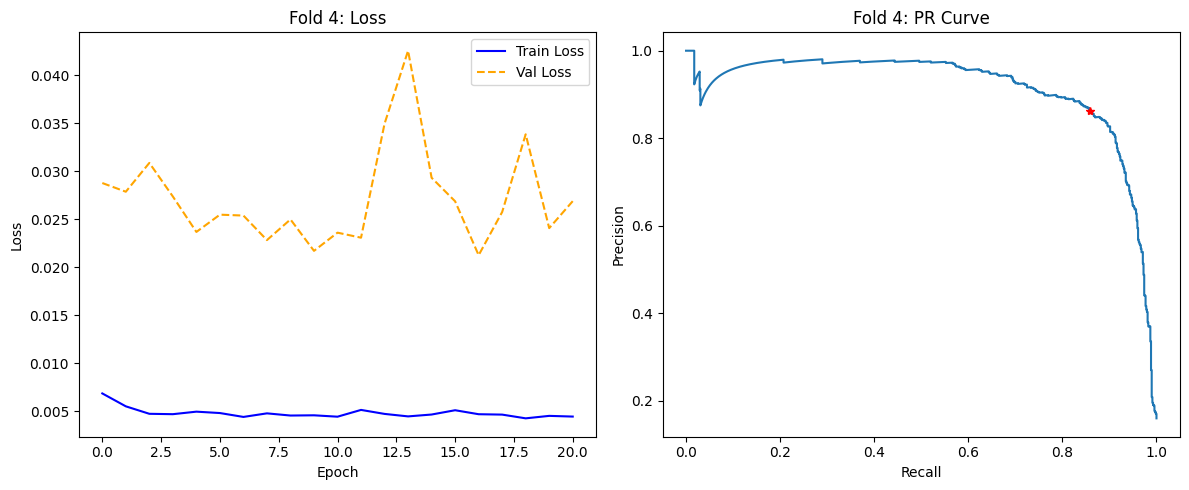


==================== TRAINING Fold 5 (Incremental) ====================
    Train: 1 -> 35
    Valid: 36 -> 39
    [INFO] Loading weights from previous fold: model_Fold4.pth

[REPORT] Fold 5 (Best Thr: 0.60)
              precision    recall  f1-score   support

       Licit       0.99      0.99      0.99      3880
     Illicit       0.91      0.81      0.85       265

    accuracy                           0.98      4145
   macro avg       0.95      0.90      0.92      4145
weighted avg       0.98      0.98      0.98      4145



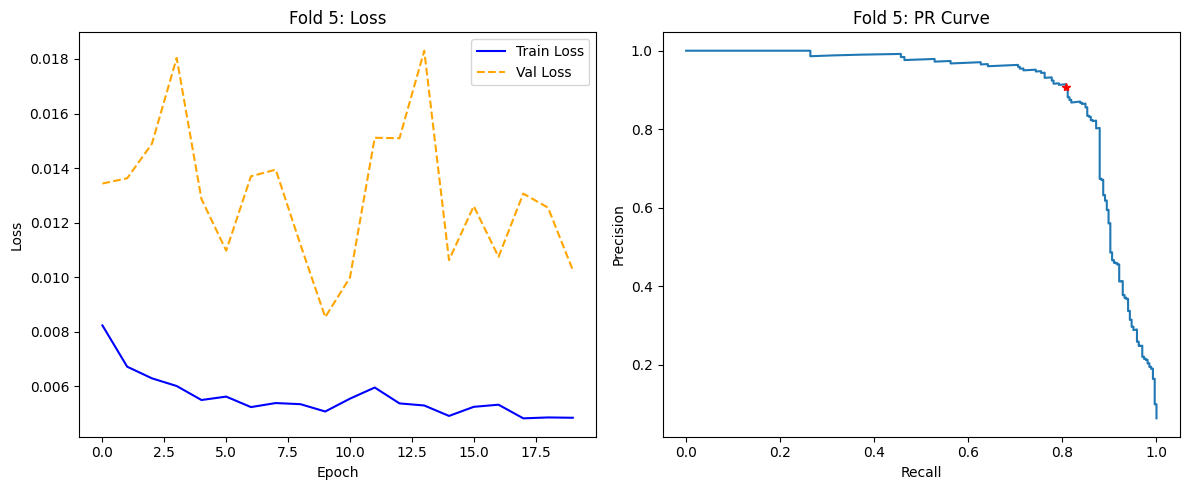


[INFO] Training Sequence Complete. Last model: 'model_Fold5.pth'

[Step 3] Independent Evaluation on Held-out Test Set (TS 40-49)...

   FINAL TEST REPORT (Held-out 20%)
Optimal Threshold: 0.70
              precision    recall  f1-score   support

       Licit       0.97      0.99      0.98     10548
     Illicit       0.84      0.52      0.64       636

    accuracy                           0.97     11184
   macro avg       0.91      0.76      0.81     11184
weighted avg       0.96      0.97      0.96     11184

Test ROC AUC: 0.8557
Confusion Matrix:
[[10484    64]
 [  304   332]]


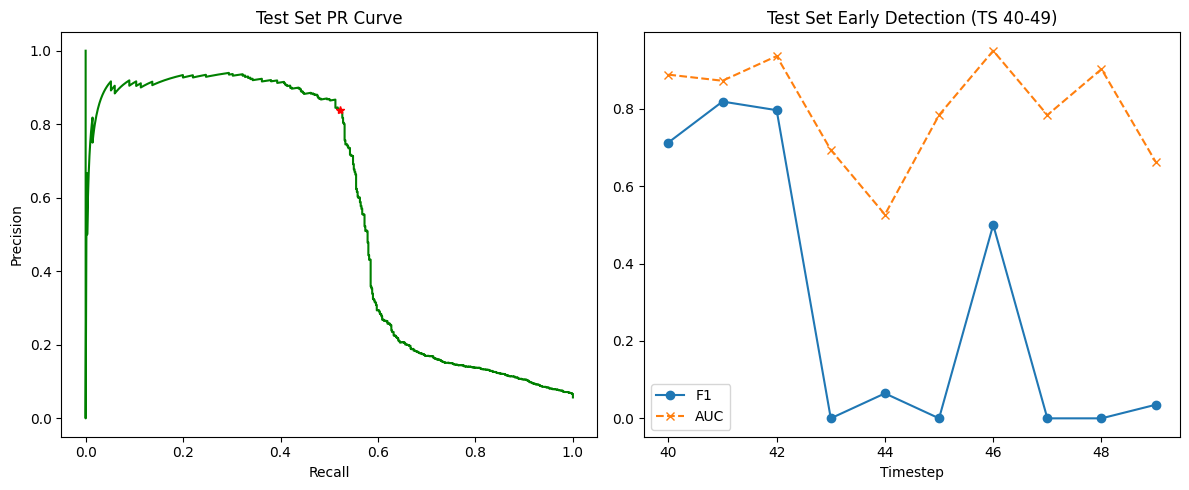

In [8]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_recall_curve, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import math
import random
import os
import shutil
import gc

# --- 0. REPRODUCIBILITY ---
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(80)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

# --- 1. LOAD & PROCESS DATA ---
print("\n[Step 1] Loading & Processing Data...")
try:
    base_path = '/kaggle/input/elliptic/elliptic/' 
    df_features = pd.read_csv(base_path + 'elliptic_txs_features.csv', header=None)
    df_classes = pd.read_csv(base_path + 'elliptic_txs_classes.csv')
    df_edgelist = pd.read_csv(base_path + 'elliptic_txs_edgelist.csv')
except:
    try:
        df_features = pd.read_csv('elliptic_txs_features.csv', header=None)
        df_classes = pd.read_csv('elliptic_txs_classes.csv')
        df_edgelist = pd.read_csv('elliptic_txs_edgelist.csv')
    except:
        print("Error: CSV files not found.")
        exit()

feature_cols = ['txId', 'timestep'] + [f'local_{i}' for i in range(93)] + [f'agg_{i}' for i in range(72)]
df_features.columns = feature_cols
all_tx_ids = df_features['txId'].unique()
tx_id_map = {tx_id: i for i, tx_id in enumerate(all_tx_ids)}
df_edgelist['txId1_idx'] = df_edgelist['txId1'].map(tx_id_map)
df_edgelist['txId2_idx'] = df_edgelist['txId2'].map(tx_id_map)
df_merged = pd.merge(df_features, df_classes, on='txId', how='left')
df_merged['class'] = df_merged['class'].map({'2': 0, '1': 1, 'unknown': np.nan})
df_merged = df_merged.set_index('txId').loc[all_tx_ids].reset_index()

features_no_time = [col for col in df_features.columns if col not in ['txId', 'timestep']]
X_df = df_merged[features_no_time]
y_series = df_merged['class']
timesteps = df_merged['timestep'].values

# Split 80/20 Strategy
TRAIN_VAL_CUTOFF = 39

print("   -> Scaling data (Fit on Train set only)...")
scaler = StandardScaler()
fit_idx = X_df.index[timesteps <= TRAIN_VAL_CUTOFF].values
scaler.fit(X_df.loc[fit_idx])
X_scaled = scaler.transform(X_df)

data = Data(
    x=torch.tensor(X_scaled, dtype=torch.float),
    edge_index=torch.tensor(df_edgelist[['txId1_idx', 'txId2_idx']].values.T, dtype=torch.long),
    y=torch.tensor(y_series.fillna(-1).values, dtype=torch.long),
    ts=torch.tensor(timesteps, dtype=torch.float) 
)

del df_features, df_classes, df_edgelist, df_merged, X_df, X_scaled
gc.collect()

# --- 2. MODEL COMPONENTS ---
class TimeEncoder(nn.Module):
    def __init__(self, out_channels):
        super().__init__()
        self.w = nn.Linear(1, out_channels // 2) 
        self.p = nn.Linear(1, out_channels // 2)
    def forward(self, t):
        t = t.unsqueeze(-1)
        return torch.cat([torch.cos(self.w(t) + self.p(t)), torch.sin(self.w(t) + self.p(t))], dim=-1)

class TGATLayer(MessagePassing):
    def __init__(self, in_channels, out_channels, time_channels, heads=2, dropout=0.2):
        super().__init__(node_dim=0, aggr='add')
        self.heads = heads
        self.head_dim = out_channels // heads
        self.dropout = dropout
        self.lin_q = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_k = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_v = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_skip = nn.Linear(in_channels, out_channels)
    def forward(self, x, edge_index, t_emb):
        x_in = torch.cat([x, t_emb], dim=-1)
        q = self.lin_q(x_in).view(-1, self.heads, self.head_dim)
        k = self.lin_k(x_in).view(-1, self.heads, self.head_dim)
        v = self.lin_v(x_in).view(-1, self.heads, self.head_dim)
        out = self.propagate(edge_index, q=q, k=k, v=v, size=None)
        out = out.view(-1, self.heads * self.head_dim) + self.lin_skip(x)
        return out
    def message(self, q_i, k_j, v_j, index, ptr, size_i):
        alpha = (q_i * k_j).sum(dim=-1) / np.sqrt(self.head_dim)
        alpha = softmax(alpha, index, ptr, size_i)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        return v_j * alpha.unsqueeze(-1)

class RobustTGATModel(nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes, time_dim=32):
        super().__init__()
        self.time_enc = TimeEncoder(time_dim)
        self.conv1 = TGATLayer(num_features, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.conv2 = TGATLayer(hidden_dim, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.lin_out = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(p=0.3) 
    def forward(self, x, edge_index, t):
        t_emb = self.time_enc(t)
        x = F.relu(self.conv1(x, edge_index, t_emb))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index, t_emb))
        x = self.dropout(x)
        return self.lin_out(x)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.7, gamma=2.0): 
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        alphas = torch.where(targets == 1, self.alpha, 1.0 - self.alpha)
        return torch.mean(alphas * (1-pt)**self.gamma * ce_loss)

# --- 3. INCREMENTAL TRAINING ---
folds = [
    {'name': 'Fold 1', 'train_end': 15, 'val_start': 16, 'val_end': 20},
    {'name': 'Fold 2', 'train_end': 20, 'val_start': 21, 'val_end': 25},
    {'name': 'Fold 3', 'train_end': 25, 'val_start': 26, 'val_end': 30},
    {'name': 'Fold 4', 'train_end': 30, 'val_start': 31, 'val_end': 35},
    {'name': 'Fold 5', 'train_end': 35, 'val_start': 36, 'val_end': 39}
]

print(f"\n[Step 2] Starting Incremental Training on Dev Set (TS 1-39)...")

model = RobustTGATModel(num_features=165, hidden_dim=128, num_classes=2, time_dim=64).to(device)
loss_fn = FocalLoss(alpha=0.7, gamma=2.0)
previous_best_model_path = ""

for fold_idx, fold in enumerate(folds):
    print(f"\n{'='*20} TRAINING {fold['name']} (Incremental) {'='*20}")
    print(f"    Train: 1 -> {fold['train_end']}")
    print(f"    Valid: {fold['val_start']} -> {fold['val_end']}")
    
    # --- INCREMENTAL LOAD ---
    if fold_idx > 0 and os.path.exists(previous_best_model_path):
        print(f"    [INFO] Loading weights from previous fold: {previous_best_model_path}")
        model.load_state_dict(torch.load(previous_best_model_path))
        optimizer = torch.optim.Adam(model.parameters(), lr=0.002, weight_decay=1e-4)
    else:
        print("    [INFO] First fold: Training from scratch.")
        optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)

    # Masks & Loaders
    train_mask_idx = torch.where((data.ts <= fold['train_end']) & (data.y != -1))[0]
    val_mask_idx = torch.where((data.ts >= fold['val_start']) & (data.ts <= fold['val_end']) & (data.y != -1))[0]
    
    train_loader = NeighborLoader(data, num_neighbors=[15, 10], batch_size=1024, input_nodes=train_mask_idx, shuffle=True)
    val_loader = NeighborLoader(data, num_neighbors=[15, 10], batch_size=2048, input_nodes=val_mask_idx)
    
    best_f1 = 0
    patience = 10
    patience_cnt = 0
    current_fold_model_path = f'model_{fold["name"].replace(" ", "")}.pth'
    
    history_train_loss = []
    history_val_loss = []
    
    # Loop
    for epoch in range(30):
        model.train()
        total_train_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            noise = (torch.rand_like(batch.ts) - 0.5) * 0.1 
            t_noisy = batch.ts + noise
            out = model(batch.x, batch.edge_index, t_noisy)
            loss = loss_fn(out[:batch.batch_size], batch.y[:batch.batch_size])
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
        
        avg_train_loss = total_train_loss / len(train_loader)
        history_train_loss.append(avg_train_loss)
        
        # Valid & Loss Check
        model.eval()
        total_val_loss = 0
        y_t, y_p = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.ts)
                v_loss = loss_fn(out[:batch.batch_size], batch.y[:batch.batch_size])
                total_val_loss += v_loss.item()
                
                prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1]
                y_t.extend(batch.y[:batch.batch_size].cpu().numpy())
                y_p.extend(prob.cpu().numpy())
        
        avg_val_loss = total_val_loss / len(val_loader)
        history_val_loss.append(avg_val_loss)

        # Check F1
        curr_f1 = f1_score(y_t, (np.array(y_p) > 0.5).astype(int), pos_label=1, zero_division=0)
        
        if curr_f1 > best_f1:
            best_f1 = curr_f1
            torch.save(model.state_dict(), current_fold_model_path)
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                break
    
    previous_best_model_path = current_fold_model_path
    
    # --- REPORT FOLD ---
    model.load_state_dict(torch.load(current_fold_model_path))
    model.eval()
    y_true, y_prob = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.ts)
            prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1]
            y_true.extend(batch.y[:batch.batch_size].cpu().numpy())
            y_prob.extend(prob.cpu().numpy())
            
    # Smart Threshold
    best_thr = 0.5; best_f1_val = 0
    for thr in np.arange(0.2, 0.7, 0.05):
        f = f1_score(y_true, (np.array(y_prob)>thr).astype(int), pos_label=1, zero_division=0)
        if f > best_f1_val: best_f1_val = f; best_thr = thr
        
    preds = (np.array(y_prob) > best_thr).astype(int)
    
    print(f"\n[REPORT] {fold['name']} (Best Thr: {best_thr:.2f})")
    print(classification_report(y_true, preds, target_names=['Licit', 'Illicit']))
    
    # Plotting Reduced (Only Loss and PR Curve per Fold)
    plt.figure(figsize=(12, 5))
    
    # 1. Loss Comparison
    plt.subplot(1, 2, 1)
    plt.plot(history_train_loss, label='Train Loss', color='blue')
    plt.plot(history_val_loss, label='Val Loss', color='orange', linestyle='--')
    plt.title(f'{fold["name"]}: Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
    
    # 2. PR Curve
    plt.subplot(1, 2, 2)
    prec, rec, _ = precision_recall_curve(y_true, y_prob, pos_label=1)
    plt.plot(rec, prec, label='PR Curve')
    plt.plot(recall_score(y_true, preds, pos_label=1), precision_score(y_true, preds, pos_label=1), 'r*')
    plt.title(f'{fold["name"]}: PR Curve'); plt.xlabel('Recall'); plt.ylabel('Precision')
    
    plt.tight_layout()
    plt.show()

print(f"\n[INFO] Training Sequence Complete. Last model: '{previous_best_model_path}'")

# --- 4. INDEPENDENT FINAL EVALUATION (TEST SET: 40-49) ---
print("\n[Step 3] Independent Evaluation on Held-out Test Set (TS 40-49)...")

final_model = RobustTGATModel(num_features=165, hidden_dim=128, num_classes=2, time_dim=64).to(device)
final_model.load_state_dict(torch.load(previous_best_model_path))
final_model.eval()

test_mask_idx = torch.where((data.ts >= 40) & (data.ts <= 49) & (data.y != -1))[0]
test_loader = NeighborLoader(data, num_neighbors=[15, 10], batch_size=4096, input_nodes=test_mask_idx, shuffle=False)

y_true_test, y_prob_test, y_ts_test = [], [], []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = final_model(batch.x, batch.edge_index, batch.ts)
        prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1]
        y_true_test.extend(batch.y[:batch.batch_size].cpu().numpy())
        y_prob_test.extend(prob.cpu().numpy())
        y_ts_test.extend(batch.ts[:batch.batch_size].cpu().numpy())

# Search optimal threshold on Test set
best_thr = 0.5; best_f1 = 0
for thr in np.arange(0.15, 0.75, 0.05):
    f = f1_score(y_true_test, (np.array(y_prob_test)>thr).astype(int), pos_label=1, zero_division=0)
    if f > best_f1: best_f1 = f; best_thr = thr

final_preds = (np.array(y_prob_test) > best_thr).astype(int)

print(f"\n{'='*40}")
print(f"   FINAL TEST REPORT (Held-out 20%)")
print(f"{'='*40}")
print(f"Optimal Threshold: {best_thr:.2f}")
print(classification_report(y_true_test, final_preds, target_names=['Licit', 'Illicit']))
print(f"Test ROC AUC: {roc_auc_score(y_true_test, y_prob_test):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_true_test, final_preds)}")

# Full Visualization for Final Report
unique_ts = sorted(np.unique(y_ts_test))
f1_time, auc_time = [], []
y_true_test, y_prob_test, y_ts_test, final_preds = np.array(y_true_test), np.array(y_prob_test), np.array(y_ts_test), np.array(final_preds)

for t in unique_ts:
    mask = (y_ts_test == t)
    if np.sum(mask) > 0 and len(np.unique(y_true_test[mask])) > 1:
        f1_time.append(f1_score(y_true_test[mask], final_preds[mask], pos_label=1, zero_division=0))
        auc_time.append(roc_auc_score(y_true_test[mask], y_prob_test[mask]))
    else:
        f1_time.append(0.0); auc_time.append(0.5)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
prec, rec, _ = precision_recall_curve(y_true_test, y_prob_test, pos_label=1)
plt.plot(rec, prec, label='PR Curve', color='green')
plt.plot(recall_score(y_true_test, final_preds, pos_label=1), precision_score(y_true_test, final_preds, pos_label=1), 'r*')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Test Set PR Curve')

plt.subplot(1, 2, 2)
plt.plot(unique_ts, f1_time, 'o-', label='F1')
plt.plot(unique_ts, auc_time, 'x--', label='AUC')
plt.title('Test Set Early Detection (TS 40-49)')
plt.xlabel('Timestep'); plt.legend()

plt.tight_layout()
plt.savefig('final_independent_test_result.png')
plt.show()